# 기본 라이브러리

In [1]:
import importlib
from urllib.request import urlretrieve

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import helper_utils as hu
from helper_utils import *

urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

helper = importlib.reload(helper)
from helper_c0z0c_dev import *

hu = importlib.reload(hu)
from helper_utils import *

helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\sprint_mission\DACON\운수종사자
🌐 https://c0z0c.github.io/jupyter_hangul
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\homepage\sprint_mission\DACON\운수종사자
helper_utils.py loaded


In [2]:
# !pip install lightgbm xgboost --upgrade --quiet

In [3]:
# --- 기본 라이브러리 ---
import importlib
import json
import logging
import math
import os
import random
import re
import shutil
import sys
import time
import warnings
import xml.etree.ElementTree as ET
import yaml
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# --- 데이터 분석 ---
import joblib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 머신러닝: Scikit-learn ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve

)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 머신러닝: Gradient Boosting ---
import lightgbm as lgb
import xgboost as xgb

# --- 경고 무시 ---
warnings.filterwarnings('ignore')

# --- 로깅 설정 ---
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
# logger.setLevel(logging.INFO)
logger.info(f"라이브러리 로드 완료")

2025-11-11 22:04:00 [I] 라이브러리 로드 완료


In [4]:
PROCESS={}
PROCESS['train_A_기본정보'] = True
PROCESS['train_B_기본정보'] = True

In [5]:
drive_temp_path = get_path_temp()
os.makedirs(drive_temp_path, exist_ok=True)
temp_open_v2_clean_path = os.path.join(drive_temp_path, r'open_v2_clean.zip')
unzip_open_v2_clean_path = temp_open_v2_clean_path + '.unzip'

logger.info(f"temp path: {drive_temp_path}")
logger.info(f"temp download path: {temp_open_v2_clean_path}")

if not Path(temp_open_v2_clean_path).exists():
    url_clean_zip = r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5ODEwNDQyMTU1MDQzMnxGfDA&svcType=MYBOX-WEB&time=1762682287910'
    download_http(url_clean_zip, temp_open_v2_clean_path, ignore=False)

if not Path(unzip_open_v2_clean_path).exists():
    unzip([temp_open_v2_clean_path])

logger.info(f"unzip path: {unzip_open_v2_clean_path}")

train_A_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'train_A_.jsonl')
train_B_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'train_B_.jsonl')
test_A_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'test_A_.jsonl')
test_B_jsonl_path = str(Path(unzip_open_v2_clean_path) / f'test_B_.jsonl')

logger.info(f"train_A_jsonl_path: {Path(train_A_jsonl_path).exists()} {train_A_jsonl_path}")
logger.info(f"train_B_jsonl_path: {Path(train_B_jsonl_path).exists()} {train_B_jsonl_path}")
logger.info(f"test_A_jsonl_path: {Path(test_A_jsonl_path).exists()} {test_A_jsonl_path}")
logger.info(f"test_B_jsonl_path: {Path(test_B_jsonl_path).exists()} {test_B_jsonl_path}")

2025-11-11 22:04:00 [I] temp path: d:\temp
2025-11-11 22:04:00 [I] temp download path: d:\temp\open_v2_clean.zip
2025-11-11 22:04:00 [I] unzip path: d:\temp\open_v2_clean.zip.unzip
2025-11-11 22:04:00 [I] train_A_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-11 22:04:00 [I] train_B_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\train_B_.jsonl
2025-11-11 22:04:00 [I] test_A_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-11 22:04:00 [I] test_B_jsonl_path: True d:\temp\open_v2_clean.zip.unzip\test_B_.jsonl


In [6]:
if PROCESS['train_A_기본정보']:
    df_train_A = pd.read_json(train_A_jsonl_path, orient='records', lines=True)

if PROCESS['train_B_기본정보']:
    df_train_B = pd.read_json(train_B_jsonl_path, orient='records', lines=True)

In [7]:
df_train_A.head_att(3)

                                                                   Test_id_idx                                                         PrimaryKey Test TestDate Label A1L_fail_rate A1L_mean_error A1L_fast_fail A1L_std A1R_fail_rate A1R_mean_error A1R_fast_fail A1R_std A1_direction_diff A2_constant_fail A2_constant_error A2_accel_fail A2_accel_error A2_decel_fail A2_decel_error A2_total_fail A2_mean_error A2_std A3S_correct_rate A3S_fail_rate A3S_mean_rt A3B_correct_rate A3B_fail_rate A3B_mean_rt A3_valid_correct A3_valid_fail_rate A3_invalid_correct A3_invalid_fail_rate A3_size_diff A3_valid_invalid_diff A3_total_fail A3_mean_rt A4C_correct_rate A4C_fail_rate A4C_mean_rt A4I_correct_rate A4I_fail_rate A4I_mean_rt A4_stroop_effect A4_total_correct A4_total_fail A4_mean_rt A5_no_change_correct A5_change_correct A5_sensitivity A5_total_fail A6_correct_count A6_accuracy A6_incorrect_count A6_acc_level A7_correct_count A7_accuracy A7_incorrect_count A7_acc_level A7_performance A8_distortion_

In [8]:
df_train_B.head_att(3)

                                                                   Test_id_idx                                                         PrimaryKey Test TestDate Label B1_rt_mean B1_rt_std B1_rt_cv B1_rt_min B1_rt_max B1_rt_q25 B1_rt_q75 B1_accuracy B1_stim1_rt B1_stim2_rt B1_stim3_rt B1_stim1_acc B1_stim2_acc B1_stim3_acc B1_early_rt B1_middle_rt B1_late_rt B1_fatigue_index B1_response_rate B1_no_response_cnt B1_response_mean B1_response_consistency B1_too_fast_cnt B1_too_slow_cnt B2_rt_mean B2_rt_std B2_rt_cv B2_rt_min B2_rt_max B2_rt_q25 B2_rt_q75 B2_accuracy B2_stim1_rt B2_stim2_rt B2_stim3_rt B2_stim1_acc B2_stim2_acc B2_stim3_acc B2_early_rt B2_middle_rt B2_late_rt B2_fatigue_index B2_response_rate B2_no_response_cnt B2_response_mean B2_response_consistency B2_type1_error_rate B2_type3_error_rate B2_correct_response_rate B2_too_fast_cnt B2_too_slow_cnt B3_rt_mean B3_rt_std B3_rt_cv B3_rt_min B3_rt_max B3_rt_q25 B3_rt_q75 B3_accuracy B3_stim1_rt B3_stim2_rt B3_stim3_rt B3_stim1_acc 

In [9]:
df_train_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297513 entries, 0 to 297512
Columns: 156 entries, Test_id_idx to B9_value_range
dtypes: float64(94), int64(59), object(3)
memory usage: 354.1+ MB


In [10]:
# 컬럼 한글 약자 매핑
col_kr_dict_A = {
    # 기본 정보
    'TestDate': '검사일',
    'Label': '레이블',

    # A1: 좌우 방향 판단 (Left/Right)
    'A1L_fail_rate': 'A1좌_실패율',
    'A1L_mean_error': 'A1좌_평균오차',
    'A1L_fast_fail': 'A1좌_조급실패',
    'A1L_std': 'A1좌_표준편차',
    'A1R_fail_rate': 'A1우_실패율',
    'A1R_mean_error': 'A1우_평균오차',
    'A1R_fast_fail': 'A1우_조급실패',
    'A1R_std': 'A1우_표준편차',
    'A1_direction_diff': 'A1_방향차이',

    # A2: 속도 조절 (Constant/Accel/Decel)
    'A2_constant_fail': 'A2_일정실패',
    'A2_constant_error': 'A2_일정오차',
    'A2_accel_fail': 'A2_가속실패',
    'A2_accel_error': 'A2_가속오차',
    'A2_decel_fail': 'A2_감속실패',
    'A2_decel_error': 'A2_감속오차',
    'A2_total_fail': 'A2_전체실패',
    'A2_mean_error': 'A2_평균오차',
    'A2_std': 'A2_표준편차',

    # A3: 시야 범위 (Small/Big, Valid/Invalid)
    'A3S_correct_rate': 'A3소_정답률',
    'A3S_fail_rate': 'A3소_실패율',
    'A3S_mean_rt': 'A3소_평균반응시간',
    'A3B_correct_rate': 'A3대_정답률',
    'A3B_fail_rate': 'A3대_실패율',
    'A3B_mean_rt': 'A3대_평균반응시간',
    'A3_valid_correct': 'A3_유효정답',
    'A3_valid_fail_rate': 'A3_유효실패율',
    'A3_invalid_correct': 'A3_무효정답',
    'A3_invalid_fail_rate': 'A3_무효실패율',
    'A3_size_diff': 'A3_크기차이',
    'A3_valid_invalid_diff': 'A3_유무효차이',
    'A3_total_fail': 'A3_전체실패',
    'A3_mean_rt': 'A3_평균반응시간',

    # A4: Stroop 효과 (Congruent/Incongruent)
    'A4C_correct_rate': 'A4일치_정답률',
    'A4C_fail_rate': 'A4일치_실패율',
    'A4C_mean_rt': 'A4일치_평균반응시간',
    'A4I_correct_rate': 'A4불일치_정답률',
    'A4I_fail_rate': 'A4불일치_실패율',
    'A4I_mean_rt': 'A4불일치_평균반응시간',
    'A4_stroop_effect': 'A4_스트룹효과',
    'A4_total_correct': 'A4_전체정답',
    'A4_total_fail': 'A4_전체실패',
    'A4_mean_rt': 'A4_평균반응시간',

    # A5: 변화 탐지
    'A5_no_change_correct': 'A5_무변화정답',
    'A5_change_correct': 'A5_변화정답',
    'A5_sensitivity': 'A5_민감도',
    'A5_total_fail': 'A5_전체실패',

    # A6: 정확도 평가
    'A6_correct_count': 'A6_정답수',
    'A6_accuracy': 'A6_정확도',
    'A6_incorrect_count': 'A6_오답수',
    'A6_acc_level': 'A6_정확도레벨',

    # A7: 정확도 평가2
    'A7_correct_count': 'A7_정답수',
    'A7_accuracy': 'A7_정확도',
    'A7_incorrect_count': 'A7_오답수',
    'A7_acc_level': 'A7_정확도레벨',
    'A7_performance': 'A7_수행수준',

    # A8: 왜곡도/일관성
    'A8_distortion_score': 'A8_왜곡점수',
    'A8_consistency_score': 'A8_일관성점수',
    'A8_distortion_norm': 'A8_왜곡표준',
    'A8_consistency_norm': 'A8_일관성표준',
    'A8_distortion_high': 'A8_고왜곡여부',
    'A8_consistency_good': 'A8_양호일관성',
    'A8_validity_score': 'A8_타당도점수',
    'A8_test_reliable': 'A8_검사신뢰여부',

    # A9: 반응시간 상세 (Go/NoGo)
    'A9_rt_mean': 'A9_반응평균',
    'A9_rt_std': 'A9_반응표준편차',
    'A9_rt_cv': 'A9_반응변이계수',
    'A9_rt_min': 'A9_반응최소',
    'A9_rt_max': 'A9_반응최대',
    'A9_rt_q25': 'A9_반응1사분위',
    'A9_rt_q75': 'A9_반응3사분위',
    'A9_accuracy': 'A9_정확도',
    'A9_go_rt': 'A9_고반응시간',
    'A9_go_acc': 'A9_고정확도',
    'A9_go_miss': 'A9_고누락',
    'A9_nogo_acc': 'A9_노고정확도',
    'A9_nogo_commission': 'A9_노고오반응',
    'A9_nogo_rt': 'A9_노고반응시간',
    'A9_cond1_rt': 'A9_조건1반응시간',
    'A9_cond1_acc': 'A9_조건1정확도',
    'A9_cond2_rt': 'A9_조건2반응시간',
    'A9_cond2_acc': 'A9_조건2정확도',
    'A9_cond3_rt': 'A9_조건3반응시간',
    'A9_cond3_acc': 'A9_조건3정확도',
    'A9_error_rt': 'A9_오류반응시간',
    'A9_correct_rt': 'A9_정답반응시간',
    'A9_too_fast_cnt': 'A9_과속횟수',
    'A9_too_slow_cnt': 'A9_지체횟수',
    'A9_response_rate': 'A9_반응률',
    'A9_no_response_cnt': 'A9_무반응횟수',
    'A9_false_alarm_rate': 'A9_거짓경보율',
    'A9_impulsivity_index': 'A9_충동성지수'
}

# 역방향 매핑 (한글 -> 영문)
col_en_dict_A = {v: k for k, v in col_kr_dict_A.items()}

if PROCESS['train_A_기본정보']:
    df_train_A.set_head_att(col_kr_dict_A)
    df_train_A.describe().head_att(10)
    df_train_A.head_att(10)

            검사일 레이블   A1좌_실패율  A1좌_평균오차 A1좌_조급실패 A1좌_표준편차   A1우_실패율  A1우_평균오차 A1우_조급실패 A1우_표준편차       A1_방향차이      A2_일정실패       A2_일정오차   A2_가속실패    A2_가속오차   A2_감속실패    A2_감속오차   A2_전체실패   A2_평균오차 A2_표준편차      A3소_정답률   A3소_실패율 A3소_평균반응시간      A3대_정답률   A3대_실패율 A3대_평균반응시간      A3_유효정답      A3_유효실패율        A3_무효정답        A3_무효실패율  A3_크기차이         A3_유무효차이   A3_전체실패 A3_평균반응시간    A4일치_정답률 A4일치_실패율 A4일치_평균반응시간  A4불일치_정답률 A4불일치_실패율 A4불일치_평균반응시간    A4_스트룹효과      A4_전체정답   A4_전체실패 A4_평균반응시간        A5_무변화정답       A5_변화정답      A5_민감도   A5_전체실패        A6_정답수   A6_정확도          A6_오답수 A6_정확도레벨        A7_정답수   A7_정확도          A7_오답수 A7_정확도레벨         A8_왜곡점수        A8_일관성점수        A8_왜곡표준       A8_일관성표준      A8_고왜곡여부       A8_양호일관성     A8_타당도점수  A8_검사신뢰여부 A9_반응평균 A9_반응표준편차 A9_반응변이계수 A9_반응최소 A9_반응최대 A9_반응1사분위 A9_반응3사분위   A9_정확도 A9_고반응시간 A9_고정확도  A9_고누락 A9_노고정확도      A9_노고오반응 A9_노고반응시간 A9_조건1반응시간 A9_조건1정확도 A9_조건2반응시간 A9_조건2정확도 A9_조건3반응시간 A9_조건3정확도 A9_오류반응시간 A9_정답반응시간     A9_과속횟수     A9_지체횟수        A

In [11]:
# B검사 컬럼 한글 약자 매핑
col_kr_dict_B = {
    # 기본 정보
    'TestDate': '검사일',
    'Label': '레이블',

    # B1: 반응시간 통계
    'B1_rt_mean': 'B1_반응평균',
    'B1_rt_std': 'B1_반응표준편차',
    'B1_rt_cv': 'B1_반응변이계수',
    'B1_rt_min': 'B1_반응최소',
    'B1_rt_max': 'B1_반응최대',
    'B1_rt_q25': 'B1_반응1사분위',
    'B1_rt_q75': 'B1_반응3사분위',
    'B1_accuracy': 'B1_정확도',
    'B1_stim1_rt': 'B1_자극1반응시간',
    'B1_stim2_rt': 'B1_자극2반응시간',
    'B1_stim3_rt': 'B1_자극3반응시간',
    'B1_stim1_acc': 'B1_자극1정확도',
    'B1_stim2_acc': 'B1_자극2정확도',
    'B1_stim3_acc': 'B1_자극3정확도',
    'B1_early_rt': 'B1_초기반응시간',
    'B1_middle_rt': 'B1_중기반응시간',
    'B1_late_rt': 'B1_후기반응시간',
    'B1_fatigue_index': 'B1_피로지수',
    'B1_response_rate': 'B1_반응률',
    'B1_no_response_cnt': 'B1_무반응횟수',
    'B1_response_mean': 'B1_반응평균값',
    'B1_response_consistency': 'B1_반응일관성',
    'B1_too_fast_cnt': 'B1_과속횟수',
    'B1_too_slow_cnt': 'B1_지체횟수',

    # B2: 반응시간 통계2
    'B2_rt_mean': 'B2_반응평균',
    'B2_rt_std': 'B2_반응표준편차',
    'B2_rt_cv': 'B2_반응변이계수',
    'B2_rt_min': 'B2_반응최소',
    'B2_rt_max': 'B2_반응최대',
    'B2_rt_q25': 'B2_반응1사분위',
    'B2_rt_q75': 'B2_반응3사분위',
    'B2_accuracy': 'B2_정확도',
    'B2_stim1_rt': 'B2_자극1반응시간',
    'B2_stim2_rt': 'B2_자극2반응시간',
    'B2_stim3_rt': 'B2_자극3반응시간',
    'B2_stim1_acc': 'B2_자극1정확도',
    'B2_stim2_acc': 'B2_자극2정확도',
    'B2_stim3_acc': 'B2_자극3정확도',
    'B2_early_rt': 'B2_초기반응시간',
    'B2_middle_rt': 'B2_중기반응시간',
    'B2_late_rt': 'B2_후기반응시간',
    'B2_fatigue_index': 'B2_피로지수',
    'B2_response_rate': 'B2_반응률',
    'B2_no_response_cnt': 'B2_무반응횟수',
    'B2_response_mean': 'B2_반응평균값',
    'B2_response_consistency': 'B2_반응일관성',
    'B2_type1_error_rate': 'B2_유형1오류율',
    'B2_type3_error_rate': 'B2_유형3오류율',
    'B2_correct_response_rate': 'B2_정반응률',
    'B2_too_fast_cnt': 'B2_과속횟수',
    'B2_too_slow_cnt': 'B2_지체횟수',

    # B3: 반응시간 통계3
    'B3_rt_mean': 'B3_반응평균',
    'B3_rt_std': 'B3_반응표준편차',
    'B3_rt_cv': 'B3_반응변이계수',
    'B3_rt_min': 'B3_반응최소',
    'B3_rt_max': 'B3_반응최대',
    'B3_rt_q25': 'B3_반응1사분위',
    'B3_rt_q75': 'B3_반응3사분위',
    'B3_accuracy': 'B3_정확도',
    'B3_stim1_rt': 'B3_자극1반응시간',
    'B3_stim2_rt': 'B3_자극2반응시간',
    'B3_stim3_rt': 'B3_자극3반응시간',
    'B3_stim1_acc': 'B3_자극1정확도',
    'B3_stim2_acc': 'B3_자극2정확도',
    'B3_stim3_acc': 'B3_자극3정확도',
    'B3_early_rt': 'B3_초기반응시간',
    'B3_middle_rt': 'B3_중기반응시간',
    'B3_late_rt': 'B3_후기반응시간',
    'B3_fatigue_index': 'B3_피로지수',
    'B3_response_rate': 'B3_반응률',
    'B3_no_response_cnt': 'B3_무반응횟수',
    'B3_response_mean': 'B3_반응평균값',
    'B3_response_consistency': 'B3_반응일관성',
    'B3_too_fast_cnt': 'B3_과속횟수',
    'B3_too_slow_cnt': 'B3_지체횟수',

    # B4: 일치/불일치 반응
    'B4_rt_mean': 'B4_반응평균',
    'B4_rt_std': 'B4_반응표준편차',
    'B4_rt_cv': 'B4_반응변이계수',
    'B4_rt_min': 'B4_반응최소',
    'B4_rt_max': 'B4_반응최대',
    'B4_rt_q25': 'B4_반응1사분위',
    'B4_rt_q75': 'B4_반응3사분위',
    'B4_accuracy': 'B4_정확도',
    'B4_match_rt': 'B4_일치반응시간',
    'B4_nonmatch_rt': 'B4_불일치반응시간',
    'B4_match_acc': 'B4_일치정확도',
    'B4_nonmatch_acc': 'B4_불일치정확도',
    'B4_pos1_rt': 'B4_위치1반응시간',
    'B4_pos2_rt': 'B4_위치2반응시간',
    'B4_pos3_rt': 'B4_위치3반응시간',
    'B4_pos4_rt': 'B4_위치4반응시간',
    'B4_pos5_rt': 'B4_위치5반응시간',
    'B4_pos1_acc': 'B4_위치1정확도',
    'B4_pos2_acc': 'B4_위치2정확도',
    'B4_pos3_acc': 'B4_위치3정확도',
    'B4_pos4_acc': 'B4_위치4정확도',
    'B4_pos5_acc': 'B4_위치5정확도',
    'B4_early_rt': 'B4_초기반응시간',
    'B4_middle_rt': 'B4_중기반응시간',
    'B4_late_rt': 'B4_후기반응시간',
    'B4_fatigue_index': 'B4_피로지수',
    'B4_response_rate': 'B4_반응률',
    'B4_no_response_cnt': 'B4_무반응횟수',
    'B4_response_consistency': 'B4_반응일관성',
    'B4_too_fast_cnt': 'B4_과속횟수',
    'B4_too_slow_cnt': 'B4_지체횟수',

    # B5: 변화 탐지
    'B5_rt_mean': 'B5_반응평균',
    'B5_rt_std': 'B5_반응표준편차',
    'B5_rt_cv': 'B5_반응변이계수',
    'B5_rt_min': 'B5_반응최소',
    'B5_rt_max': 'B5_반응최대',
    'B5_rt_q25': 'B5_반응1사분위',
    'B5_rt_q75': 'B5_반응3사분위',
    'B5_accuracy': 'B5_정확도',
    'B5_no_change_correct': 'B5_무변화정답',
    'B5_change_correct': 'B5_변화정답',
    'B5_sensitivity': 'B5_민감도',
    'B5_total_fail': 'B5_전체실패',
    'B5_no_change_rt': 'B5_무변화반응시간',
    'B5_change_rt': 'B5_변화반응시간',
    'B5_cond1_rt': 'B5_조건1반응시간',
    'B5_cond2_rt': 'B5_조건2반응시간',
    'B5_cond3_rt': 'B5_조건3반응시간',
    'B5_cond4_rt': 'B5_조건4반응시간',
    'B5_too_fast_cnt': 'B5_과속횟수',
    'B5_too_slow_cnt': 'B5_지체횟수',

    # B6: 샘플 분석
    'B6_sample_size': 'B6_샘플크기',
    'B6_value1_count': 'B6_값1개수',
    'B6_value2_count': 'B6_값2개수',
    'B6_value1_ratio': 'B6_값1비율',

    # B7: 유형 분석
    'B7_type1_count': 'B7_유형1개수',
    'B7_type2_count': 'B7_유형2개수',
    'B7_type1_ratio': 'B7_유형1비율',
    'B7_type2_ratio': 'B7_유형2비율',
    'B7_switch_count': 'B7_전환횟수',
    'B7_switch_rate': 'B7_전환율',
    'B7_sample_size': 'B7_샘플크기',
    'B7_data_completeness': 'B7_데이터완성도',

    # B8: 정확도 평가
    'B8_accuracy': 'B8_정확도',
    'B8_error_count': 'B8_오류횟수',
    'B8_total_trials': 'B8_전체시행수',
    'B8_data_completeness': 'B8_데이터완성도',
    'B8_response_uniformity': 'B8_반응균일성',
    'B8_unique_values': 'B8_고유값수',
    'B8_mean_value': 'B8_평균값',

    # B9: 값 분석
    'B9_value_sum': 'B9_값합계',
    'B9_value_mean': 'B9_값평균',
    'B9_nonzero_count': 'B9_비영값개수',
    'B9_max_value': 'B9_최대값',
    'B9_min_value': 'B9_최소값',
    'B9_value_range': 'B9_값범위'
}

# 역방향 매핑
col_en_dict_B = {v: k for k, v in col_kr_dict_B.items()}

if PROCESS['train_B_기본정보']:
    df_train_B.set_head_att(col_kr_dict_B)
    df_train_B.describe().head_att(10)
    df_train_B.head_att(10)

            검사일 레이블 B1_반응평균 B1_반응표준편차 B1_반응변이계수 B1_반응최소 B1_반응최대 B1_반응1사분위 B1_반응3사분위   B1_정확도 B1_자극1반응시간 B1_자극2반응시간 B1_자극3반응시간 B1_자극1정확도 B1_자극2정확도 B1_자극3정확도 B1_초기반응시간 B1_중기반응시간 B1_후기반응시간      B1_피로지수        B1_반응률      B1_무반응횟수    B1_반응평균값           B1_반응일관성     B1_과속횟수     B1_지체횟수 B2_반응평균 B2_반응표준편차 B2_반응변이계수 B2_반응최소 B2_반응최대 B2_반응1사분위 B2_반응3사분위   B2_정확도 B2_자극1반응시간 B2_자극2반응시간 B2_자극3반응시간 B2_자극1정확도 B2_자극2정확도 B2_자극3정확도 B2_초기반응시간 B2_중기반응시간 B2_후기반응시간      B2_피로지수        B2_반응률      B2_무반응횟수    B2_반응평균값           B2_반응일관성      B2_유형1오류율      B2_유형3오류율              B2_정반응률     B2_과속횟수     B2_지체횟수 B3_반응평균 B3_반응표준편차 B3_반응변이계수 B3_반응최소 B3_반응최대 B3_반응1사분위 B3_반응3사분위   B3_정확도 B3_자극1반응시간 B3_자극2반응시간 B3_자극3반응시간 B3_자극1정확도 B3_자극2정확도 B3_자극3정확도 B3_초기반응시간 B3_중기반응시간 B3_후기반응시간      B3_피로지수        B3_반응률      B3_무반응횟수    B3_반응평균값           B3_반응일관성     B3_과속횟수     B3_지체횟수 B4_반응평균 B4_반응표준편차 B4_반응변이계수 B4_반응최소 B4_반응최대 B4_반응1사분위 B4_반응3사분위   B4_정확도 B4_일치반응시간 B4_불일치반응시간 B4_일치정확도 B4_불일치정확도 B4_위치1반응시간 B4_위치2반응시간 B4_위치3반응

In [12]:
"""
운수종사자 적성검사 분석 프로젝트 설정
Config for Transport Worker Aptitude Test Analysis Project
"""

# from dataclasses import dataclass, field
# from typing import List, Dict, Optional
# from pathlib import Path

@dataclass
class DataConfig:
    """데이터 관련 설정"""

    sample_test_size: Optional[int] = None  # 샘플 테스트용 데이터 크기 제한 (None이면 전체 사용)
    #sample_test_size: Optional[int] = 100

    # 파일 경로
    data_path: str = train_A_jsonl_path
    data_path_B: str = train_B_jsonl_path  # B검사 경로 추가
    test_type: str = "A"  # "A" 또는 "B"
    output_dir: str = str(Path(get_path_modeling()) / 'driver_aptitude')

    # 데이터 분할 비율
    train_ratio: float = 0.8
    val_ratio: float = 0.1
    test_ratio: float = 0.1

    # 시드
    random_seed: int = 42

    # 타겟 컬럼
    target_col: str = "Label"

    # 제외할 컬럼 (ID, 날짜 등)
    exclude_cols: List[str] = field(default_factory=lambda: [
        "Test_id_idx", "PrimaryKey", "Test", "TestDate"
    ])

    # A검사별 피처 그룹
    feature_groups: Dict[str, List[str]] = field(default_factory=lambda: {
        "A1": ["A1L_fail_rate", "A1L_mean_error", "A1L_fast_fail", "A1L_std",
               "A1R_fail_rate", "A1R_mean_error", "A1R_fast_fail", "A1R_std",
               "A1_direction_diff"],
        "A2": ["A2_constant_fail", "A2_constant_error", "A2_accel_fail",
               "A2_accel_error", "A2_decel_fail", "A2_decel_error",
               "A2_total_fail", "A2_mean_error", "A2_std"],
        "A3": ["A3S_correct_rate", "A3S_fail_rate", "A3S_mean_rt",
               "A3B_correct_rate", "A3B_fail_rate", "A3B_mean_rt",
               "A3_valid_correct", "A3_valid_fail_rate", "A3_invalid_correct",
               "A3_invalid_fail_rate", "A3_size_diff", "A3_valid_invalid_diff",
               "A3_total_fail", "A3_mean_rt"],
        "A4": ["A4C_correct_rate", "A4C_fail_rate", "A4C_mean_rt",
               "A4I_correct_rate", "A4I_fail_rate", "A4I_mean_rt",
               "A4_stroop_effect", "A4_total_correct", "A4_total_fail", "A4_mean_rt"],
        "A5": ["A5_no_change_correct", "A5_change_correct",
               "A5_sensitivity", "A5_total_fail"],
        "A6": ["A6_correct_count", "A6_accuracy", "A6_incorrect_count", "A6_acc_level"],
        "A7": ["A7_correct_count", "A7_accuracy", "A7_incorrect_count",
               "A7_acc_level", "A7_performance"],
        "A8": ["A8_distortion_score", "A8_consistency_score", "A8_distortion_norm",
               "A8_consistency_norm", "A8_distortion_high", "A8_consistency_good",
               "A8_validity_score", "A8_test_reliable"],
        "A9": ["A9_rt_mean", "A9_rt_std", "A9_rt_cv", "A9_rt_min", "A9_rt_max",
               "A9_rt_q25", "A9_rt_q75", "A9_accuracy", "A9_go_rt", "A9_go_acc",
               "A9_go_miss", "A9_nogo_acc", "A9_nogo_commission", "A9_nogo_rt",
               "A9_cond1_rt", "A9_cond1_acc", "A9_cond2_rt", "A9_cond2_acc",
               "A9_cond3_rt", "A9_cond3_acc", "A9_error_rt", "A9_correct_rt",
               "A9_too_fast_cnt", "A9_too_slow_cnt", "A9_response_rate",
               "A9_no_response_cnt", "A9_false_alarm_rate", "A9_impulsivity_index"]
    })

    # B검사별 피처 그룹
    feature_groups_B: Dict[str, List[str]] = field(default_factory=lambda: {
        "B1": ["B1_rt_mean", "B1_rt_std", "B1_rt_cv", "B1_rt_min", "B1_rt_max",
               "B1_rt_q25", "B1_rt_q75", "B1_accuracy", "B1_stim1_rt", "B1_stim2_rt",
               "B1_stim3_rt", "B1_stim1_acc", "B1_stim2_acc", "B1_stim3_acc",
               "B1_early_rt", "B1_middle_rt", "B1_late_rt", "B1_fatigue_index",
               "B1_response_rate", "B1_no_response_cnt", "B1_response_mean",
               "B1_response_consistency", "B1_too_fast_cnt", "B1_too_slow_cnt"],
        "B2": ["B2_rt_mean", "B2_rt_std", "B2_rt_cv", "B2_rt_min", "B2_rt_max",
               "B2_rt_q25", "B2_rt_q75", "B2_accuracy", "B2_stim1_rt", "B2_stim2_rt",
               "B2_stim3_rt", "B2_stim1_acc", "B2_stim2_acc", "B2_stim3_acc",
               "B2_early_rt", "B2_middle_rt", "B2_late_rt", "B2_fatigue_index",
               "B2_response_rate", "B2_no_response_cnt", "B2_response_mean",
               "B2_response_consistency", "B2_type1_error_rate", "B2_type3_error_rate",
               "B2_correct_response_rate", "B2_too_fast_cnt", "B2_too_slow_cnt"],
        "B3": ["B3_rt_mean", "B3_rt_std", "B3_rt_cv", "B3_rt_min", "B3_rt_max",
               "B3_rt_q25", "B3_rt_q75", "B3_accuracy", "B3_stim1_rt", "B3_stim2_rt",
               "B3_stim3_rt", "B3_stim1_acc", "B3_stim2_acc", "B3_stim3_acc",
               "B3_early_rt", "B3_middle_rt", "B3_late_rt", "B3_fatigue_index",
               "B3_response_rate", "B3_no_response_cnt", "B3_response_mean",
               "B3_response_consistency", "B3_too_fast_cnt", "B3_too_slow_cnt"],
        "B4": ["B4_rt_mean", "B4_rt_std", "B4_rt_cv", "B4_rt_min", "B4_rt_max",
               "B4_rt_q25", "B4_rt_q75", "B4_accuracy", "B4_match_rt", "B4_nonmatch_rt",
               "B4_match_acc", "B4_nonmatch_acc", "B4_pos1_rt", "B4_pos2_rt",
               "B4_pos3_rt", "B4_pos4_rt", "B4_pos5_rt", "B4_pos1_acc", "B4_pos2_acc",
               "B4_pos3_acc", "B4_pos4_acc", "B4_pos5_acc", "B4_early_rt",
               "B4_middle_rt", "B4_late_rt", "B4_fatigue_index", "B4_response_rate",
               "B4_no_response_cnt", "B4_response_consistency", "B4_too_fast_cnt",
               "B4_too_slow_cnt"],
        "B5": ["B5_rt_mean", "B5_rt_std", "B5_rt_cv", "B5_rt_min", "B5_rt_max",
               "B5_rt_q25", "B5_rt_q75", "B5_accuracy", "B5_no_change_correct",
               "B5_change_correct", "B5_sensitivity", "B5_total_fail",
               "B5_no_change_rt", "B5_change_rt", "B5_cond1_rt", "B5_cond2_rt",
               "B5_cond3_rt", "B5_cond4_rt", "B5_too_fast_cnt", "B5_too_slow_cnt"],
        "B6": ["B6_sample_size", "B6_value1_count", "B6_value2_count", "B6_value1_ratio"],
        "B7": ["B7_type1_count", "B7_type2_count", "B7_type1_ratio", "B7_type2_ratio",
               "B7_switch_count", "B7_switch_rate", "B7_sample_size", "B7_data_completeness"],
        "B8": ["B8_accuracy", "B8_error_count", "B8_total_trials", "B8_data_completeness",
               "B8_response_uniformity", "B8_unique_values", "B8_mean_value"],
        "B9": ["B9_value_sum", "B9_value_mean", "B9_nonzero_count", "B9_max_value",
               "B9_min_value", "B9_value_range"]
    })

    def get_current_feature_groups(self) -> Dict[str, List[str]]:
        """현재 검사 타입에 맞는 피처 그룹 반환"""
        return self.feature_groups_B if self.test_type == "B" else self.feature_groups

    # 도메인 가중치 설정
    use_domain_weights: bool = False
    use_only_weighted_features: bool = False  # True면 가중치 피처만 사용

    # A검사 그룹별 도메인 가중치 (총합 1.0)
    domain_weights_A: Dict[str, float] = field(default_factory=lambda: {
        "A1": 0.15,  # 좌우 방향 판단 (핵심: 순간 판단력, 사고 직결)
        "A2": 0.15,  # 속도 조절 (핵심: 과속/급제동 사고 원인)
        "A3": 0.15,  # 시야 범위 (핵심: 주변 인지, 보행자 사고)
        "A4": 0.10,  # Stroop 효과 (중요: 돌발 상황 대응)
        "A5": 0.10,  # 변화 탐지 (중요: 신호/표지판 인지)
        "A6": 0.08,  # 정확도 평가 (보통: 일반 주의력)
        "A7": 0.08,  # 정확도 평가2 (보통: 일반 집중력)
        "A8": 0.05,  # 왜곡도/일관성 (낮음: 검사 신뢰도 지표)
        "A9": 0.14   # 반응시간 상세 (중요: 충동성/피로 지표)
    })

    # B검사 그룹별 도메인 가중치 (총합 1.0)
    domain_weights_B: Dict[str, float] = field(default_factory=lambda: {
        "B1": 0.15,  # 기본 반응시간
        "B2": 0.15,  # 복합 반응시간
        "B3": 0.10,  # 지속 반응시간
        "B4": 0.15,  # 일치/불일치 판단
        "B5": 0.15,  # 변화 탐지 능력
        "B6": 0.05,  # 샘플 통계
        "B7": 0.10,  # 유형 전환
        "B8": 0.08,  # 정확도 지표
        "B9": 0.07   # 반응 패턴
    })

    def get_domain_weights(self) -> Dict[str, float]:
        """현재 검사 타입의 도메인 가중치 반환"""
        return self.domain_weights_B if self.test_type == "B" else self.domain_weights_A

    def print_domain_weights(self):
        """도메인 가중치 출력"""
        weights = self.get_domain_weights()
        
        logger.info(f"\n{'='*70}")
        logger.info(f"{self.test_type}검사 그룹별 도메인 가중치")
        logger.info(f"{'='*70}")
        
        for group, weight in sorted(weights.items()):
            logger.info(f"  {group}: {weight:.2f} ({weight*100:.1f}%)")
        
        logger.info(f"\n총합: {sum(weights.values()):.2f}")
        logger.info(f"{'='*70}\n")


@dataclass
class ModelConfig:
    """모델 관련 설정"""
    # 모델 타입
    model_type: str = "lightgbm"  # lightgbm, xgboost, random_forest, logistic

    # LightGBM 하이퍼파라미터
    lgb_params: Dict = field(default_factory=lambda: {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "num_leaves": 31,
        "learning_rate": 0.05,
        "feature_fraction": 0.9,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "max_depth": -1,
        "min_child_samples": 20,
        "verbose": -1,
        "random_state": 42
    })

    # XGBoost 하이퍼파라미터
    xgb_params: Dict = field(default_factory=lambda: {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "min_child_weight": 1,
        "random_state": 42
    })

    # RandomForest 하이퍼파라미터
    rf_params: Dict = field(default_factory=lambda: {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_split": 10,
        "min_samples_leaf": 4,
        "random_state": 42,
        "n_jobs": -1
    })


@dataclass
class TrainingConfig:
    """학습 관련 설정"""
    # 학습 파라미터
    num_boost_round: int = 1000
    early_stopping_rounds: int = 50
    verbose_eval: int = 50

    # 교차 검증
    use_cross_validation: bool = False
    n_folds: int = 5

    # 클래스 불균형 처리
    handle_imbalance: bool = True
    scale_pos_weight: Optional[float] = None  # None이면 자동 계산


@dataclass
class VisualizationConfig:
    """시각화 관련 설정"""
    # 그래프 저장 설정
    save_plots: bool = True
    plot_format: str = "png"
    dpi: int = 300

    # 그래프 스타일
    style: str = "seaborn-v0_8-darkgrid"
    figsize: tuple = (12, 8)

    # 한글 폰트 설정
    use_korean_font: bool = True
    font_family: str = "DejaVu Sans"


@dataclass
class ProjectConfig:
    """전체 프로젝트 설정"""
    # 프로젝트 정보
    project_name: str = "운수종사자_적성검사_분석"
    version: str = "1.0.0"

    # 하위 설정
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    training: TrainingConfig = field(default_factory=TrainingConfig)
    visualization: VisualizationConfig = field(default_factory=VisualizationConfig)

    def __post_init__(self):
        """설정 초기화 후 디렉토리 생성"""
        Path(self.data.output_dir).mkdir(parents=True, exist_ok=True)
        Path(f"{self.data.output_dir}/plots").mkdir(exist_ok=True)
        Path(f"{self.data.output_dir}/models").mkdir(exist_ok=True)
        Path(f"{self.data.output_dir}/reports").mkdir(exist_ok=True)

    def get_feature_list(self) -> List[str]:
        """모든 피처 리스트 반환"""
        all_features = []
        feature_groups = self.data.get_current_feature_groups()
        for features in feature_groups.values():
            all_features.extend(features)
        return all_features

    def print_config(self):
        """설정 출력"""
        logger.debug(f"{'='*60}")
        logger.debug(f"Project: {self.project_name} v{self.version}")
        logger.debug(f"{'='*60}")
        logger.debug(f"\n[Data Config]")
        logger.debug(f"  - Data path: {self.data.data_path}")
        logger.debug(f"  - Train/Val/Test: {self.data.train_ratio}/{self.data.val_ratio}/{self.data.test_ratio}")
        logger.debug(f"  - Random seed: {self.data.random_seed}")
        logger.debug(f"\n[Model Config]")
        logger.debug(f"  - Model type: {self.model.model_type}")
        logger.debug(f"\n[Training Config]")
        logger.debug(f"  - Num boost round: {self.training.num_boost_round}")
        logger.debug(f"  - Early stopping: {self.training.early_stopping_rounds}")
        logger.debug(f"  - Cross validation: {self.training.use_cross_validation}")
        logger.debug(f"{'='*60}\n")

def test_config(test_type: str = "A"):
    config = ProjectConfig()
    config.data.test_type = test_type
    config.print_config()

    logger.debug(f"Total A features: {len(config.get_feature_list())}")
    logger.debug(f"\nA Feature groups:")
    for group_name, features in config.data.feature_groups.items():
        logger.debug(f"  {group_name}: {len(features)} features")

    logger.debug(f"\nTotal B features: {sum(len(f) for f in config.data.feature_groups_B.values())}")
    logger.debug(f"\nB Feature groups:")
    for group_name, features in config.data.feature_groups_B.items():
        logger.debug(f"  {group_name}: {len(features)} features")

    return config
configA = test_config('A')
configB = test_config('B')

2025-11-11 22:05:56 [D] ============================================================
2025-11-11 22:05:56 [D] Project: 운수종사자_적성검사_분석 v1.0.0
2025-11-11 22:05:56 [D] ============================================================
2025-11-11 22:05:56 [D] 
[Data Config]
2025-11-11 22:05:56 [D]   - Data path: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-11 22:05:56 [D]   - Train/Val/Test: 0.8/0.1/0.1
2025-11-11 22:05:56 [D]   - Random seed: 42
2025-11-11 22:05:56 [D] 
[Model Config]
2025-11-11 22:05:56 [D]   - Model type: lightgbm
2025-11-11 22:05:56 [D] 
[Training Config]
2025-11-11 22:05:56 [D]   - Num boost round: 1000
2025-11-11 22:05:56 [D]   - Early stopping: 50
2025-11-11 22:05:56 [D]   - Cross validation: False
2025-11-11 22:05:56 [D] ============================================================

2025-11-11 22:05:56 [D] Total A features: 91
2025-11-11 22:05:56 [D] 
A Feature groups:
2025-11-11 22:05:56 [D]   A1: 9 features
2025-11-11 22:05:56 [D]   A2: 9 features
2025-11-11 22:

In [13]:
"""
데이터 로드 및 전처리 파이프라인
Data Loading and Preprocessing Pipeline
"""

# import json
# import pandas as pd
# import numpy as np
# from pathlib import Path
# from typing import Tuple, Optional, Dict, List
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import warnings
# warnings.filterwarnings('ignore')


class DataLoader:
    """운수종사자 적성검사 데이터 로더"""

    def __init__(self, config):
        """
        Args:
            config: ProjectConfig 인스턴스
            test_type: "A" 또는 "B"
        """
        self.config = config
        self.data = None
        self.train_data = None
        self.val_data = None
        self.test_data = None
        self.scaler = StandardScaler()

    def load_json_data(self, file_path: Optional[str] = None) -> pd.DataFrame:
        """
        JSON 데이터 로드 (샘플 테스트 지원)

        Args:
            file_path: 데이터 파일 경로 (None이면 config에서 가져옴)

        Returns:
            pd.DataFrame: 로드된 데이터프레임
        """
        if file_path is None:
            file_path = (self.config.data.data_path_B
                        if self.config.data.test_type == "B"
                        else self.config.data.data_path)

        logger.debug(f"Loading {self.config.data.test_type} test data from: {file_path}")

        # 샘플 테스트 모드 확인
        sample_size = self.config.data.sample_test_size
        if sample_size is not None:
            logger.warning(f"⚠ SAMPLE TEST MODE: Loading only {sample_size} samples")

        # pandas가 자동으로 JSONL 형식 감지
        df = pd.read_json(file_path, lines=True)

        # 샘플 크기 제한 (Stratified Sampling)
        if sample_size is not None and len(df) > sample_size:
            target_col = self.config.data.target_col

            # Label 분포 확인
            label_counts = df[target_col].value_counts()
            logger.warning(f"  ⚠ Original label distribution: {label_counts.to_dict()}")

            # 균등 샘플링: 각 Label당 절반씩
            samples_per_label = sample_size // len(label_counts)

            df_balanced = []
            for label in sorted(label_counts.index):
                df_label = df[df[target_col] == label]

                # 해당 Label 샘플 수가 부족하면 전체 사용
                n_samples = min(samples_per_label, len(df_label))

                df_sampled = df_label.sample(
                    n=n_samples,
                    random_state=self.config.data.random_seed
                )
                df_balanced.append(df_sampled)

            df = pd.concat(df_balanced, ignore_index=True)

            # 샘플링 후 Label 분포 확인
            sampled_label_counts = df[target_col].value_counts()
            logger.warning(f"  ⚠ Balanced sampling: {len(df)} rows")
            logger.warning(f"  ⚠ Sampled label distribution: {sampled_label_counts.to_dict()}")
            logger.warning(f"  ⚠ Label 0: {sampled_label_counts.get(0, 0)}")
            logger.warning(f"  ⚠ Label 1: {sampled_label_counts.get(1, 0)}")

        logger.debug(f"✓ Data loaded successfully: {df.shape}")
        self.data = df
        return df


    def preprocess_data(self, df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
        """
        데이터 전처리

        Args:
            df: 전처리할 데이터프레임 (None이면 self.data 사용)

        Returns:
            pd.DataFrame: 전처리된 데이터프레임
        """
        if df is None:
            df = self.data.copy()
        else:
            df = df.copy()

        logger.debug("\nPreprocessing data...")

        # 1. 제외 컬럼 제거
        cols_to_drop = [col for col in self.config.data.exclude_cols if col in df.columns]
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop)
            logger.debug(f"  - Dropped columns: {cols_to_drop}")

        # 2. 결측치 확인
        missing_counts = df.isnull().sum()
        if missing_counts.sum() > 0:
            logger.debug(f"  - Missing values found:")
            for col, count in missing_counts[missing_counts > 0].items():
                logger.debug(f"    {col}: {count} ({count/len(df)*100:.2f}%)")

            # 수치형 컬럼은 평균으로, 범주형은 최빈값으로 대체
            for col in df.columns:
                if df[col].isnull().sum() > 0:
                    if df[col].dtype in ['float64', 'int64']:
                        df[col].fillna(df[col].mean(), inplace=True)
                    else:
                        df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            logger.debug("  - No missing values found")

        # 3. 무한대 값 처리
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if np.isinf(df[col]).any():
                logger.debug(f"  - Found inf values in {col}, replacing with max/min")
                df[col].replace([np.inf, -np.inf], [df[col][~np.isinf(df[col])].max(),
                                                     df[col][~np.isinf(df[col])].min()],
                               inplace=True)

        # 4. 범주형 변수 인코딩 (A7_performance 등)
        categorical_cols = df.select_dtypes(include=['object']).columns
        categorical_cols = [col for col in categorical_cols if col != self.config.data.target_col]

        if len(categorical_cols) > 0:
            logger.debug(f"  - Encoding categorical columns: {list(categorical_cols)}")
            for col in categorical_cols:
                df[col] = pd.Categorical(df[col]).codes

        logger.debug(f"✓ Preprocessing completed: {df.shape}")
        self.data = df
        return df

    def split_data(self,
                   df: Optional[pd.DataFrame] = None,
                   stratify: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        데이터를 train/val/test로 분할 (Label 기준 균등 분배)

        Args:
            df: 분할할 데이터프레임 (None이면 self.data 사용)
            stratify: 층화 추출 여부 (Label 비율 유지)

        Returns:
            Tuple[train_df, val_df, test_df]
        """
        if df is None:
            df = self.data.copy()
        else:
            df = df.copy()

        logger.debug("\nSplitting data...")

        target_col = self.config.data.target_col
        train_ratio = self.config.data.train_ratio
        val_ratio = self.config.data.val_ratio
        test_ratio = self.config.data.test_ratio
        seed = self.config.data.random_seed

        # 비율 검증
        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
            "Train/Val/Test ratios must sum to 1.0"

        # Stratify 설정
        stratify_col = df[target_col] if stratify else None

        # 1차 분할: train + (val + test)
        train_df, temp_df = train_test_split(
            df,
            test_size=(val_ratio + test_ratio),
            random_state=seed,
            stratify=stratify_col
        )

        # 2차 분할: val + test
        val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
        stratify_temp = temp_df[target_col] if stratify else None

        val_df, test_df = train_test_split(
            temp_df,
            test_size=(1 - val_ratio_adjusted),
            random_state=seed,
            stratify=stratify_temp
        )

        # 결과 저장
        self.train_data = train_df
        self.val_data = val_df
        self.test_data = test_df

        # 분할 결과 출력
        logger.debug(f"  - Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(train_df[target_col]==0).sum()}, Label 1: {(train_df[target_col]==1).sum()}")
        logger.debug(f"  - Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(val_df[target_col]==0).sum()}, Label 1: {(val_df[target_col]==1).sum()}")
        logger.debug(f"  - Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
        logger.debug(f"    Label 0: {(test_df[target_col]==0).sum()}, Label 1: {(test_df[target_col]==1).sum()}")

        return train_df, val_df, test_df

    def get_X_y(self,
                df: pd.DataFrame,
                scale_features: bool = False) -> Tuple[np.ndarray, np.ndarray]:
        """
        피처(X)와 타겟(y) 분리

        Args:
            df: 데이터프레임
            scale_features: 피처 스케일링 여부

        Returns:
            Tuple[X, y]
        """
        target_col = self.config.data.target_col

        # 타겟 분리
        if target_col not in df.columns:
            raise ValueError(f"Target column '{target_col}' not found in dataframe")

        y = df[target_col].values
        X = df.drop(columns=[target_col]).values

        # 스케일링
        if scale_features:
            X = self.scaler.fit_transform(X)

        return X, y

    def get_feature_names(self, df: Optional[pd.DataFrame] = None) -> List[str]:
        """
        피처 이름 리스트 반환

        Args:
            df: 데이터프레임 (None이면 self.train_data 사용)

        Returns:
            List[str]: 피처 이름 리스트
        """
        if df is None:
            df = self.train_data if self.train_data is not None else self.data

        target_col = self.config.data.target_col
        return [col for col in df.columns if col != target_col]

    def apply_domain_weights(self, df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
        """
        검사 그룹별 도메인 가중치 적용
        
        Args:
            df: 가중치 적용할 데이터프레임 (None이면 self.data)
        
        Returns:
            가중치 적용된 데이터프레임 (원본 + 가중치 피처)
        """
        if df is None:
            df = self.data.copy()
        else:
            df = df.copy()
        
        if not self.config.data.use_domain_weights:
            logger.debug("Domain weights disabled in config")
            return df
        
        weights = self.config.data.get_domain_weights()
        feature_groups = self.config.data.get_current_feature_groups()
        
        logger.info(f"\n{'='*60}")
        logger.info(f"Applying Domain Weights - {self.config.data.test_type} Test")
        logger.info(f"{'='*60}")
        
        weighted_features_added = 0
        
        for group_name, features in feature_groups.items():
            if group_name not in weights:
                logger.warning(f"  No weight for group {group_name}, skipping")
                continue
            
            weight = weights[group_name]
            group_features_count = 0
            
            for feature in features:
                if feature in df.columns:
                    weighted_col = f"{feature}_w"
                    df[weighted_col] = df[feature] * weight
                    group_features_count += 1
                    weighted_features_added += 1
            
            if group_features_count > 0:
                logger.info(f"  {group_name}: weight={weight:.2f}, features={group_features_count}")
        
        logger.info(f"\n✓ Domain weights applied")
        logger.info(f"  Original features: {len(self.get_feature_names(df))}")
        logger.info(f"  Weighted features added: {weighted_features_added}")
        
        # 가중치 피처만 사용 옵션
        if self.config.data.use_only_weighted_features:
            target_col = self.config.data.target_col
            weighted_cols = [col for col in df.columns if col.endswith('_w')]
            df = df[[target_col] + weighted_cols]
            logger.info(f"  Using only weighted features: {len(weighted_cols)}")
        
        return df

    def get_data_summary(self) -> Dict:
        """
        데이터 요약 정보 반환

        Returns:
            Dict: 데이터 요약 정보
        """
        if self.data is None:
            raise ValueError("No data loaded. Please load data first.")

        target_col = self.config.data.target_col

        summary = {
            "total_samples": len(self.data),
            "num_features": len(self.get_feature_names()),
            "label_distribution": self.data[target_col].value_counts().to_dict(),
            "label_ratio": f"{(self.data[target_col]==0).sum()}/{(self.data[target_col]==1).sum()}",
            "missing_values": self.data.isnull().sum().sum(),
            "data_types": self.data.dtypes.value_counts().to_dict()
        }

        if self.train_data is not None:
            summary["train_samples"] = len(self.train_data)
            summary["val_samples"] = len(self.val_data)
            summary["test_samples"] = len(self.test_data)

        return summary

    def save_processed_data(self, output_dir: Optional[str] = None):
        """
        전처리된 데이터 저장

        Args:
            output_dir: 저장 디렉토리 (None이면 config에서 가져옴)
        """
        if output_dir is None:
            output_dir = self.config.data.output_dir

        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)

        if self.train_data is not None:
            self.train_data.to_csv(output_path / "train_processed.csv", index=False)
            self.val_data.to_csv(output_path / "val_processed.csv", index=False)
            self.test_data.to_csv(output_path / "test_processed.csv", index=False)
            logger.debug(f"\n✓ Processed data saved to {output_dir}")
        else:
            logger.debug("\n✗ No split data to save. Please run split_data() first.")


def test_data_loader(config: ProjectConfig):

    # 데이터 로더 생성
    #config = ProjectConfig()
    loader = DataLoader(config)

    # 데이터 로드 테스트 (실제 파일이 있다고 가정)
    df = loader.load_json_data()
    df = loader.preprocess_data()
    train_df, val_df, test_df = loader.split_data()

    # 요약 정보 출력
    summary = loader.get_data_summary()
    logger.debug("\n" + "="*60)
    logger.debug(f"Data Summary ({config.data.test_type}):")
    logger.debug("="*60)
    for key, value in summary.items():
        logger.debug(f"{key}: {value}")

    # 데이터 저장
    loader.save_processed_data()
    return loader

loaderA = test_data_loader(configA)
loaderB = test_data_loader(configB)

2025-11-11 22:05:56 [D] Loading A test data from: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-11 22:07:00 [D] ✓ Data loaded successfully: (647237, 96)
2025-11-11 22:07:01 [D] 
Preprocessing data...
2025-11-11 22:07:01 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-11 22:07:01 [D]   - No missing values found
2025-11-11 22:07:01 [D]   - Encoding categorical columns: ['A7_performance']
2025-11-11 22:07:01 [D] ✓ Preprocessing completed: (647237, 92)
2025-11-11 22:07:02 [D] 
Splitting data...
2025-11-11 22:07:03 [D]   - Train: 517789 (80.0%)
2025-11-11 22:07:03 [D]     Label 0: 506035, Label 1: 11754
2025-11-11 22:07:03 [D]   - Val:   64724 (10.0%)
2025-11-11 22:07:03 [D]     Label 0: 63255, Label 1: 1469
2025-11-11 22:07:03 [D]   - Test:  64724 (10.0%)
2025-11-11 22:07:03 [D]     Label 0: 63255, Label 1: 1469
2025-11-11 22:07:03 [D] 
2025-11-11 22:07:03 [D] Data Summary (A):
2025-11-11 22:07:03 [D] =============================================

2025-11-11 22:08:57 [D] Loading A test data from: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-11 22:10:09 [D] ✓ Data loaded successfully: (647237, 96)
2025-11-11 22:10:10 [D] 
Preprocessing data...
2025-11-11 22:10:10 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-11 22:10:10 [D]   - No missing values found
2025-11-11 22:10:10 [D]   - Encoding categorical columns: ['A7_performance']
2025-11-11 22:10:10 [D] ✓ Preprocessing completed: (647237, 92)
2025-11-11 22:10:11 [D] 
Splitting data...
2025-11-11 22:10:11 [D]   - Train: 517789 (80.0%)
2025-11-11 22:10:11 [D]     Label 0: 506035, Label 1: 11754
2025-11-11 22:10:11 [D]   - Val:   64724 (10.0%)
2025-11-11 22:10:11 [D]     Label 0: 63255, Label 1: 1469
2025-11-11 22:10:11 [D]   - Test:  64724 (10.0%)
2025-11-11 22:10:11 [D]     Label 0: 63255, Label 1: 1469
2025-11-11 22:10:11 [I] 
2025-11-11 22:10:11 [I] Generating Full Analysis Report - A Test
2025-11-11 22:10:11 [I] ======================

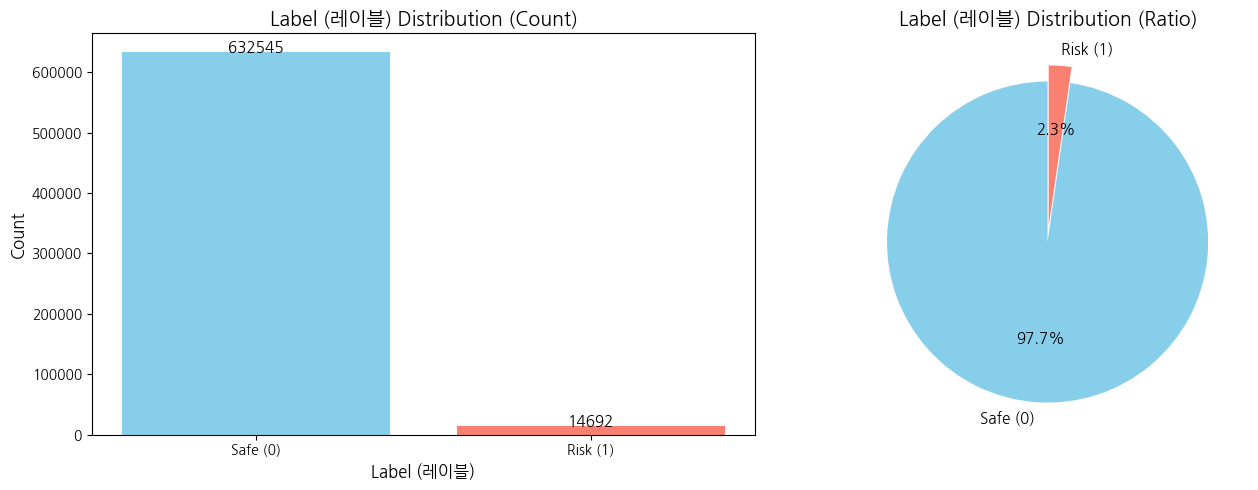

2025-11-11 22:10:13 [I] 
2. Feature Distributions...
2025-11-11 22:10:18 [I] 
2025-11-11 22:10:18 [I] Feature Distribution Statistics (Top 20)
2025-11-11 22:10:18 [I] ================================================================================
2025-11-11 22:10:18 [I] 
                        Feature Safe_Mean Risk_Mean    Diff  Safe_Std  Risk_Std
0       A1L_fail_rate (A1좌_실패율)    0.9860    0.9843  0.0017    0.0704    0.0740
1     A1L_mean_error (A1좌_평균오차)   40.7758   45.2507  4.4749  157.1842  163.9762
2      A1L_fast_fail (A1좌_조급실패)    0.9836    0.9809  0.0027    0.0915    0.0962
3            A1L_std (A1좌_표준편차)    1.3033    1.6195  0.3162   10.5550   12.4509
4       A1R_fail_rate (A1우_실패율)    0.9852    0.9832  0.0020    0.0726    0.0801
5     A1R_mean_error (A1우_평균오차)   43.2978   45.9178  2.6200  161.6535  164.4827
6      A1R_fast_fail (A1우_조급실패)    0.9825    0.9796  0.0029    0.0943    0.1033
7            A1R_std (A1우_표준편차)    1.3570    1.6410  0.2840   10.8072   12.8686
8   A1_

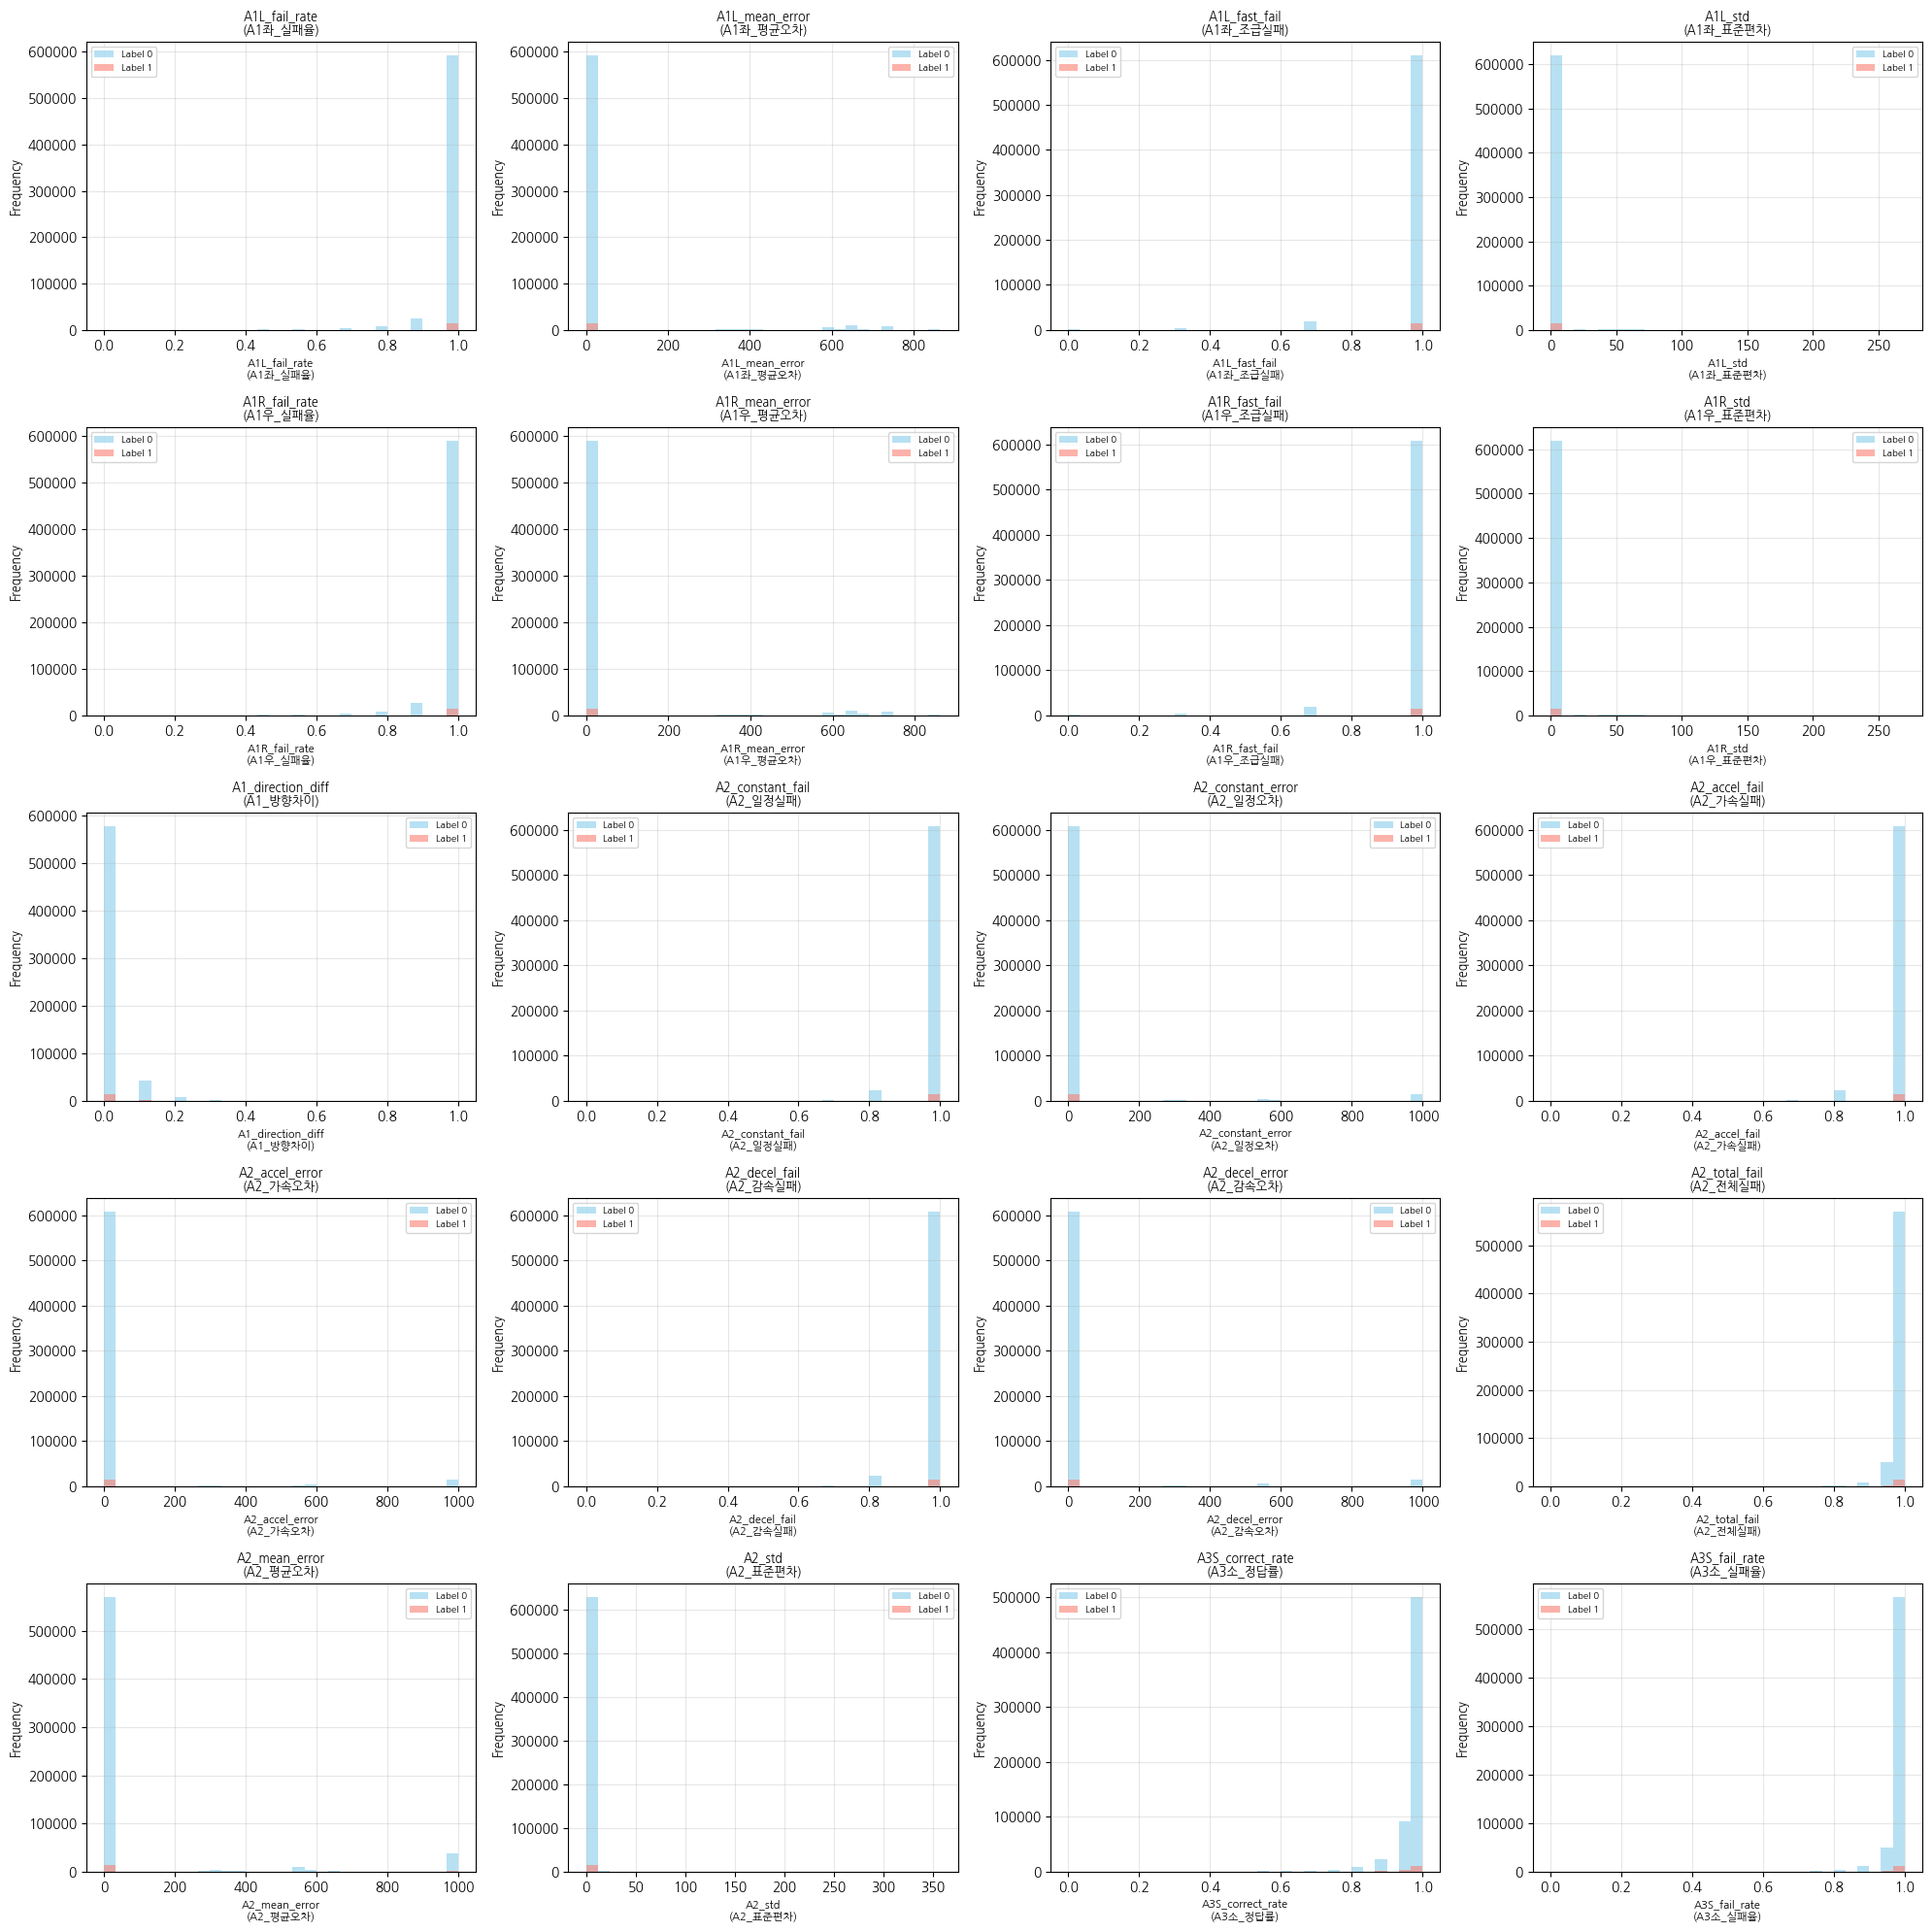

2025-11-11 22:10:37 [I] 
3. Correlation Analysis...
2025-11-11 22:10:41 [I] 
2025-11-11 22:10:41 [I] Correlation with Label - Correlation Matrix - Top 30 Features
2025-11-11 22:10:41 [I] ================================================================================
2025-11-11 22:10:41 [I] 
                            Feature Correlation Abs_Correlation
0       A6_incorrect_count (A6_오답수)      0.0528          0.0528
1       A7_incorrect_count (A7_오답수)      0.0465          0.0465
2            A3_mean_rt (A3_평균반응시간)      0.0291          0.0291
3    A8_consistency_norm (A8_일관성표준)      0.0279          0.0279
4   A8_consistency_score (A8_일관성점수)      0.0279          0.0279
5          A3B_mean_rt (A3대_평균반응시간)      0.0237          0.0237
6          A3S_mean_rt (A3소_평균반응시간)      0.0233          0.0233
7          A7_performance (A7_수행수준)      0.0215          0.0215
8     A8_distortion_score (A8_왜곡점수)      0.0162          0.0162
9      A8_distortion_norm (A8_왜곡표준)      0.0162          0.0162
10 

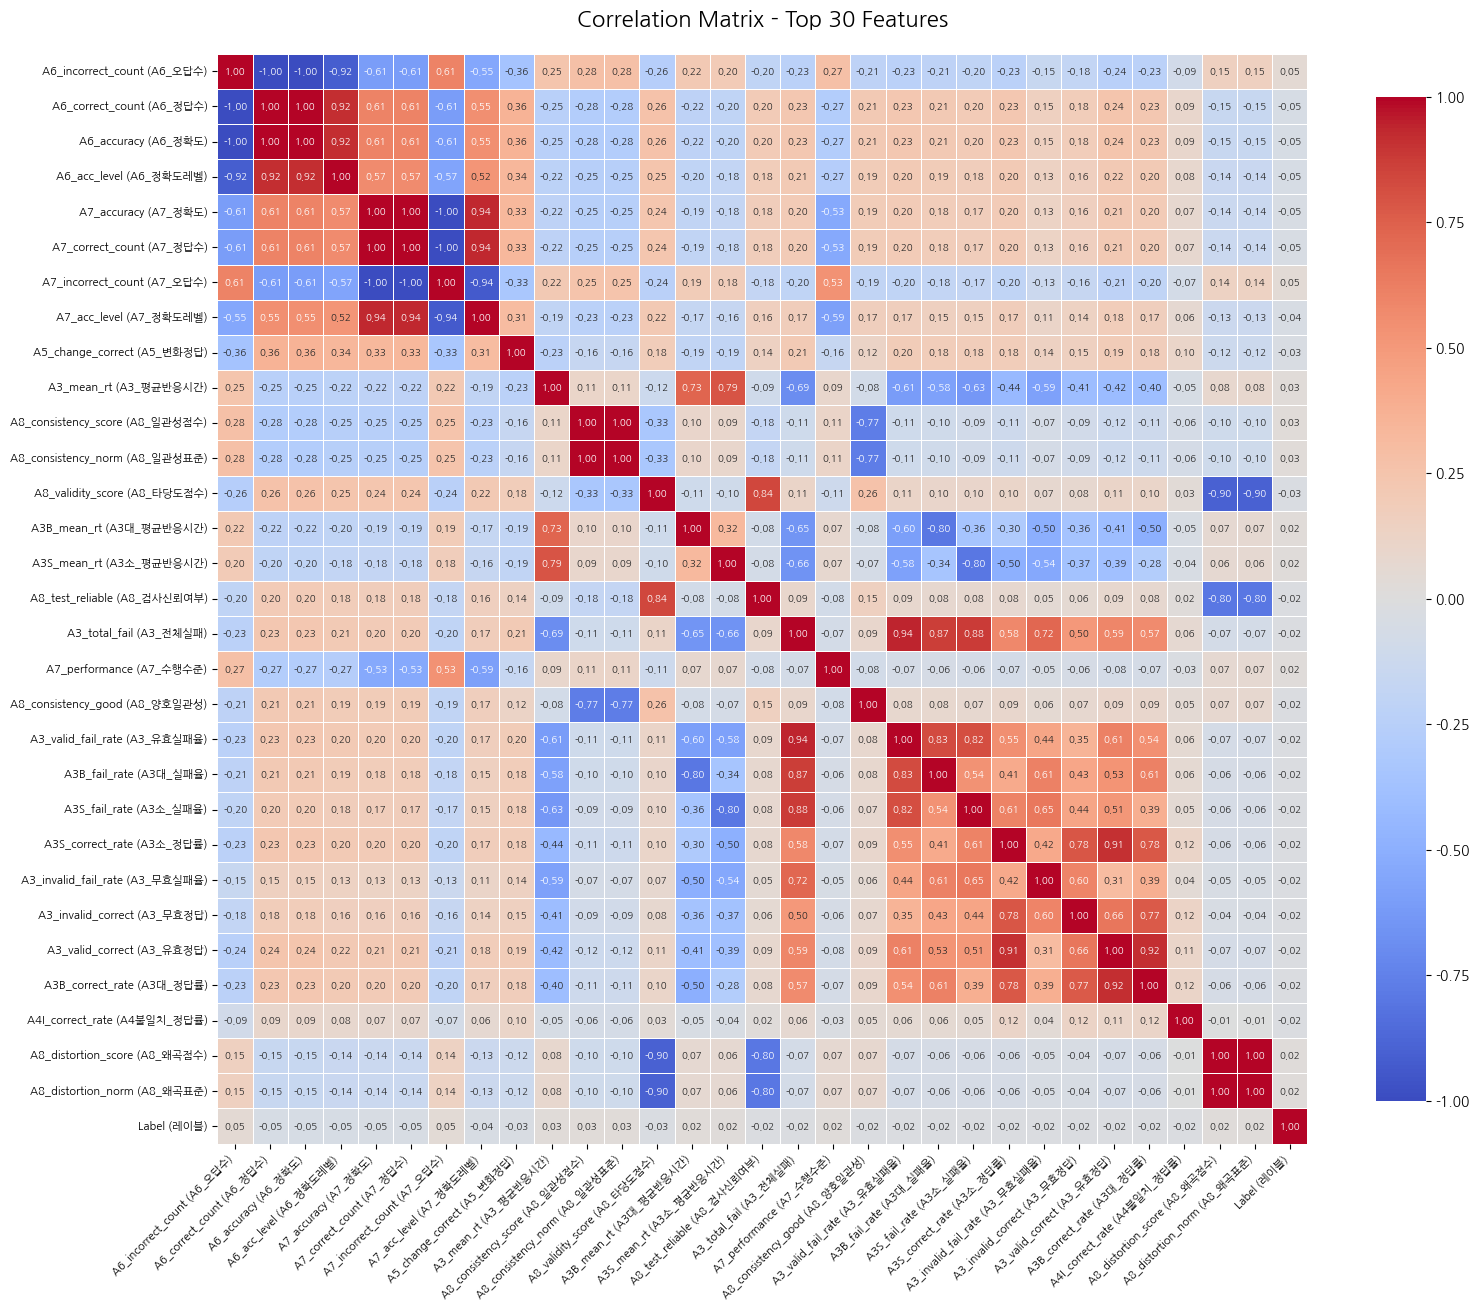

2025-11-11 22:10:46 [I] 
4. Preliminary Feature Importance...
2025-11-11 22:10:48 [I] 
2025-11-11 22:10:48 [I] Top 20 Feature Importance (Preliminary)
2025-11-11 22:10:48 [I] ================================================================================
2025-11-11 22:10:48 [I] 
    Rank                          Feature Abs_Correlation Importance_Score
0      1      A6_incorrect_count (A6_오답수)          0.0528          100.00%
1      2        A6_correct_count (A6_정답수)          0.0528          100.00%
2      3             A6_accuracy (A6_정확도)          0.0528          100.00%
3      4          A6_acc_level (A6_정확도레벨)          0.0478           90.58%
4      5             A7_accuracy (A7_정확도)          0.0465           88.08%
5      6        A7_correct_count (A7_정답수)          0.0465           88.08%
6      7      A7_incorrect_count (A7_오답수)          0.0465           88.08%
7      8          A7_acc_level (A7_정확도레벨)          0.0421           79.72%
8      9      A5_change_correct (A5_변화정답)   

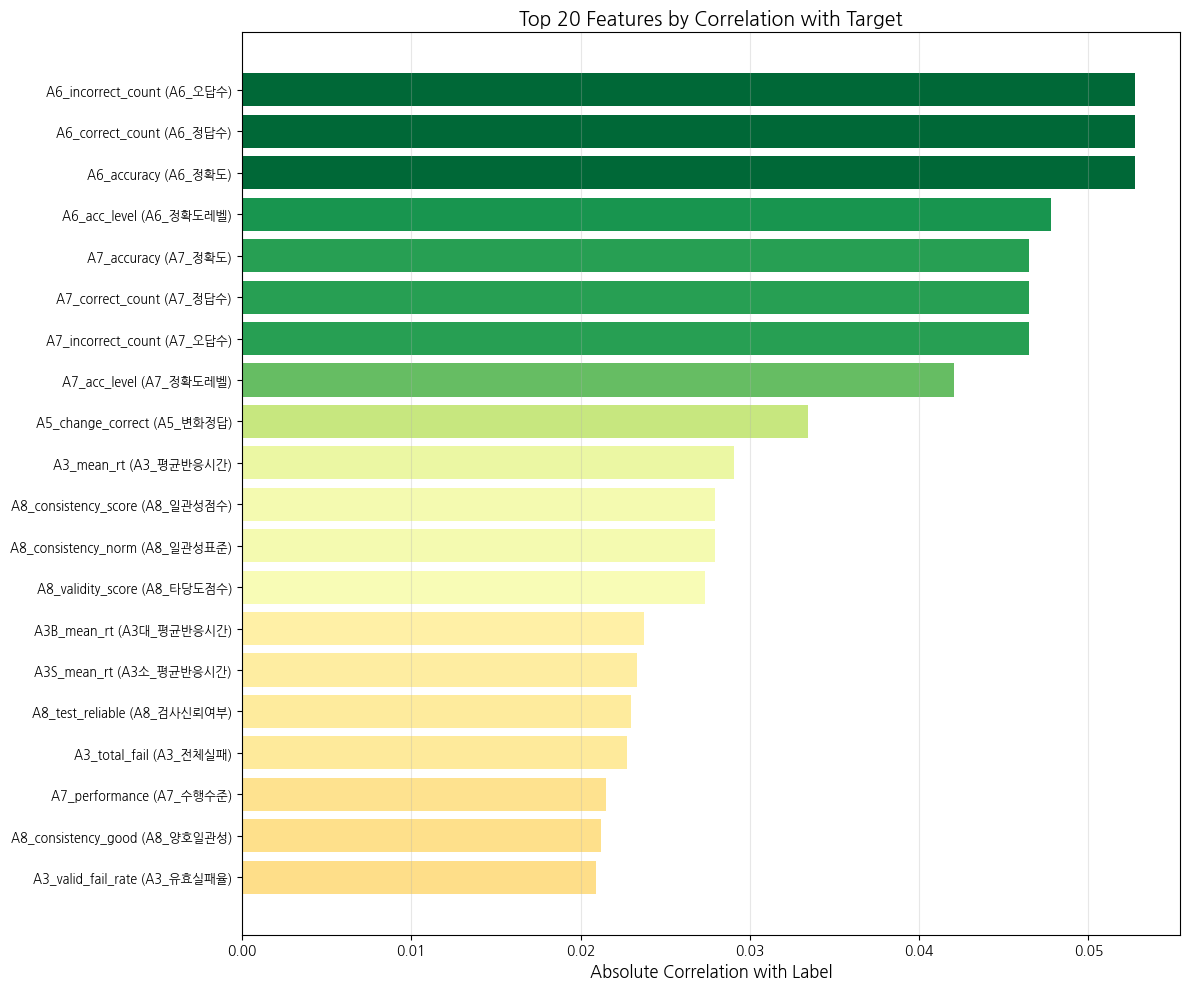

2025-11-11 22:10:49 [I] 
5. Test Group Analysis...
2025-11-11 22:10:52 [I] 
2025-11-11 22:10:52 [I] A Test Group Summary Statistics
2025-11-11 22:10:52 [I] ================================================================================
2025-11-11 22:10:52 [I] 
  Group  Num_Features Safe_Avg Risk_Avg Avg_Diff  Max_Diff
0    A1             9  10.0760  10.9302   0.8542    4.4749
1    A2             9  20.0807  21.0332   0.9525    4.0966
2    A3            14  64.3387  94.0529  29.7141  179.3677
3    A4            10  10.6268  12.9399   2.3131    9.8923
4    A5             4   0.5769   0.5595   0.0173    0.0332
5    A6             4   4.2621   4.1885   0.0737    1.0431
6    A7             5   4.5361   4.5034   0.0328    1.2337
7    A8             8   1.1917   1.2662   0.0745    0.4177
8    A9            28   1.7277   1.7473   0.0196    0.2468

2025-11-11 22:10:58 [I]   ✓ Plot saved: D:\GoogleDrive\modeling\driver_aptitude\plots\A\05_test_group_analysis.png


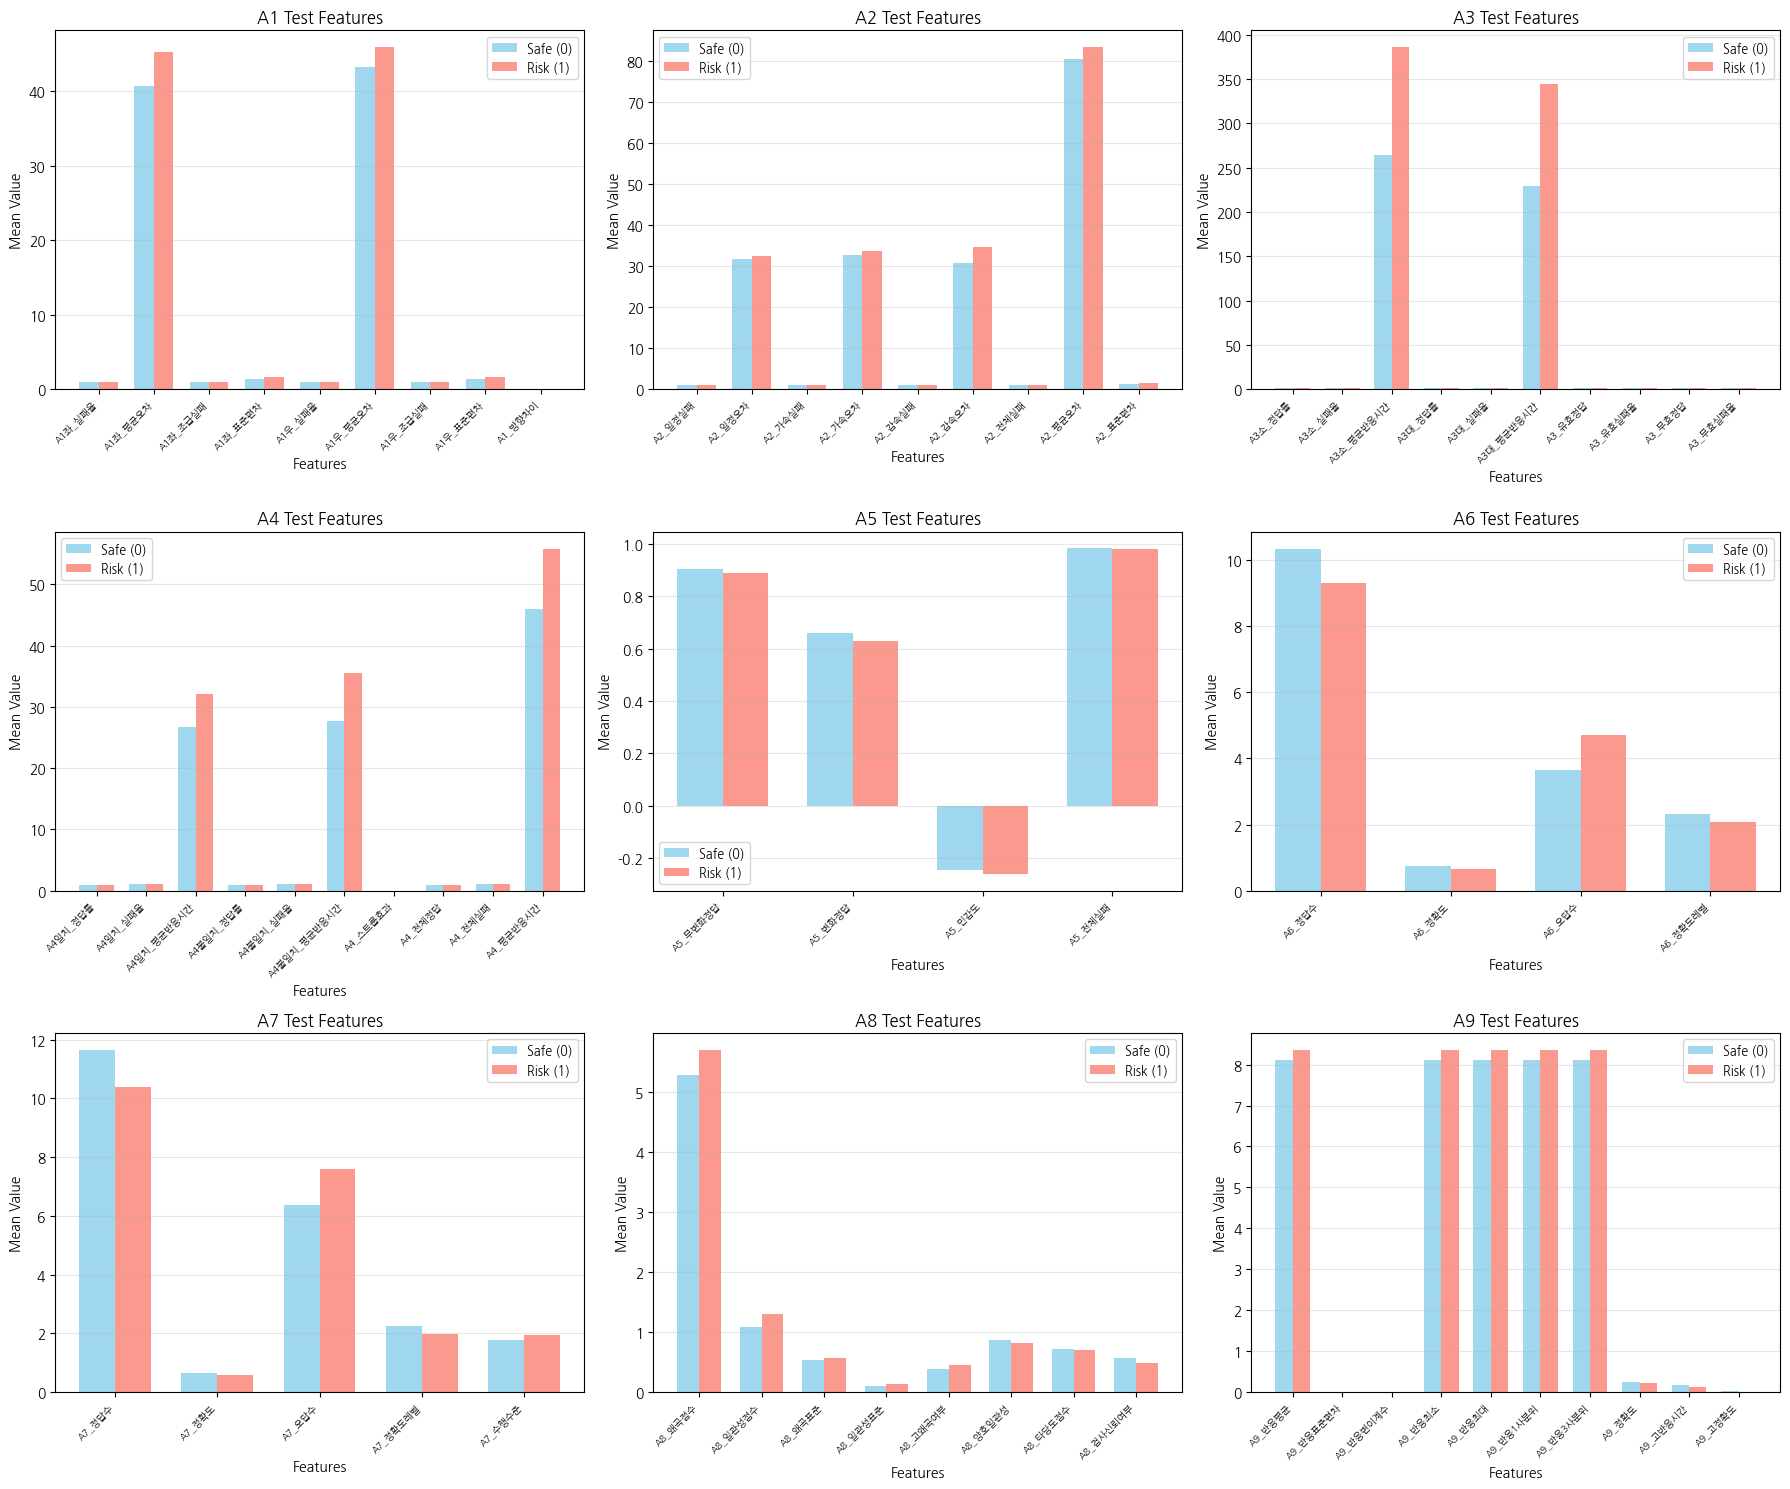

2025-11-11 22:10:59 [I] 
6. Boxplot Analysis...
2025-11-11 22:11:06 [I] 
2025-11-11 22:11:06 [I] Boxplot Statistics (Top 12 Features)
2025-11-11 22:11:06 [I] ================================================================================
2025-11-11 22:11:06 [I] 
                            Feature Safe_Q1 Safe_Median  Safe_Q3 Risk_Q1 Risk_Median  Risk_Q3 Median_Diff
0       A6_incorrect_count (A6_오답수)  1.0000      3.0000   5.0000  2.0000      4.0000   7.0000      1.0000
1         A6_correct_count (A6_정답수)  9.0000     11.0000  13.0000  7.0000     10.0000  12.0000      1.0000
2              A6_accuracy (A6_정확도)  0.6429      0.7857   0.9286  0.5000      0.7143   0.8571      0.0714
3           A6_acc_level (A6_정확도레벨)  2.0000      2.0000   3.0000  2.0000      2.0000   3.0000      0.0000
4              A7_accuracy (A7_정확도)  0.5000      0.6667   0.8333  0.3889      0.5556   0.7778      0.1111
5         A7_correct_count (A7_정답수)  9.0000     12.0000  15.0000  7.0000     10.0000  14.0000      2

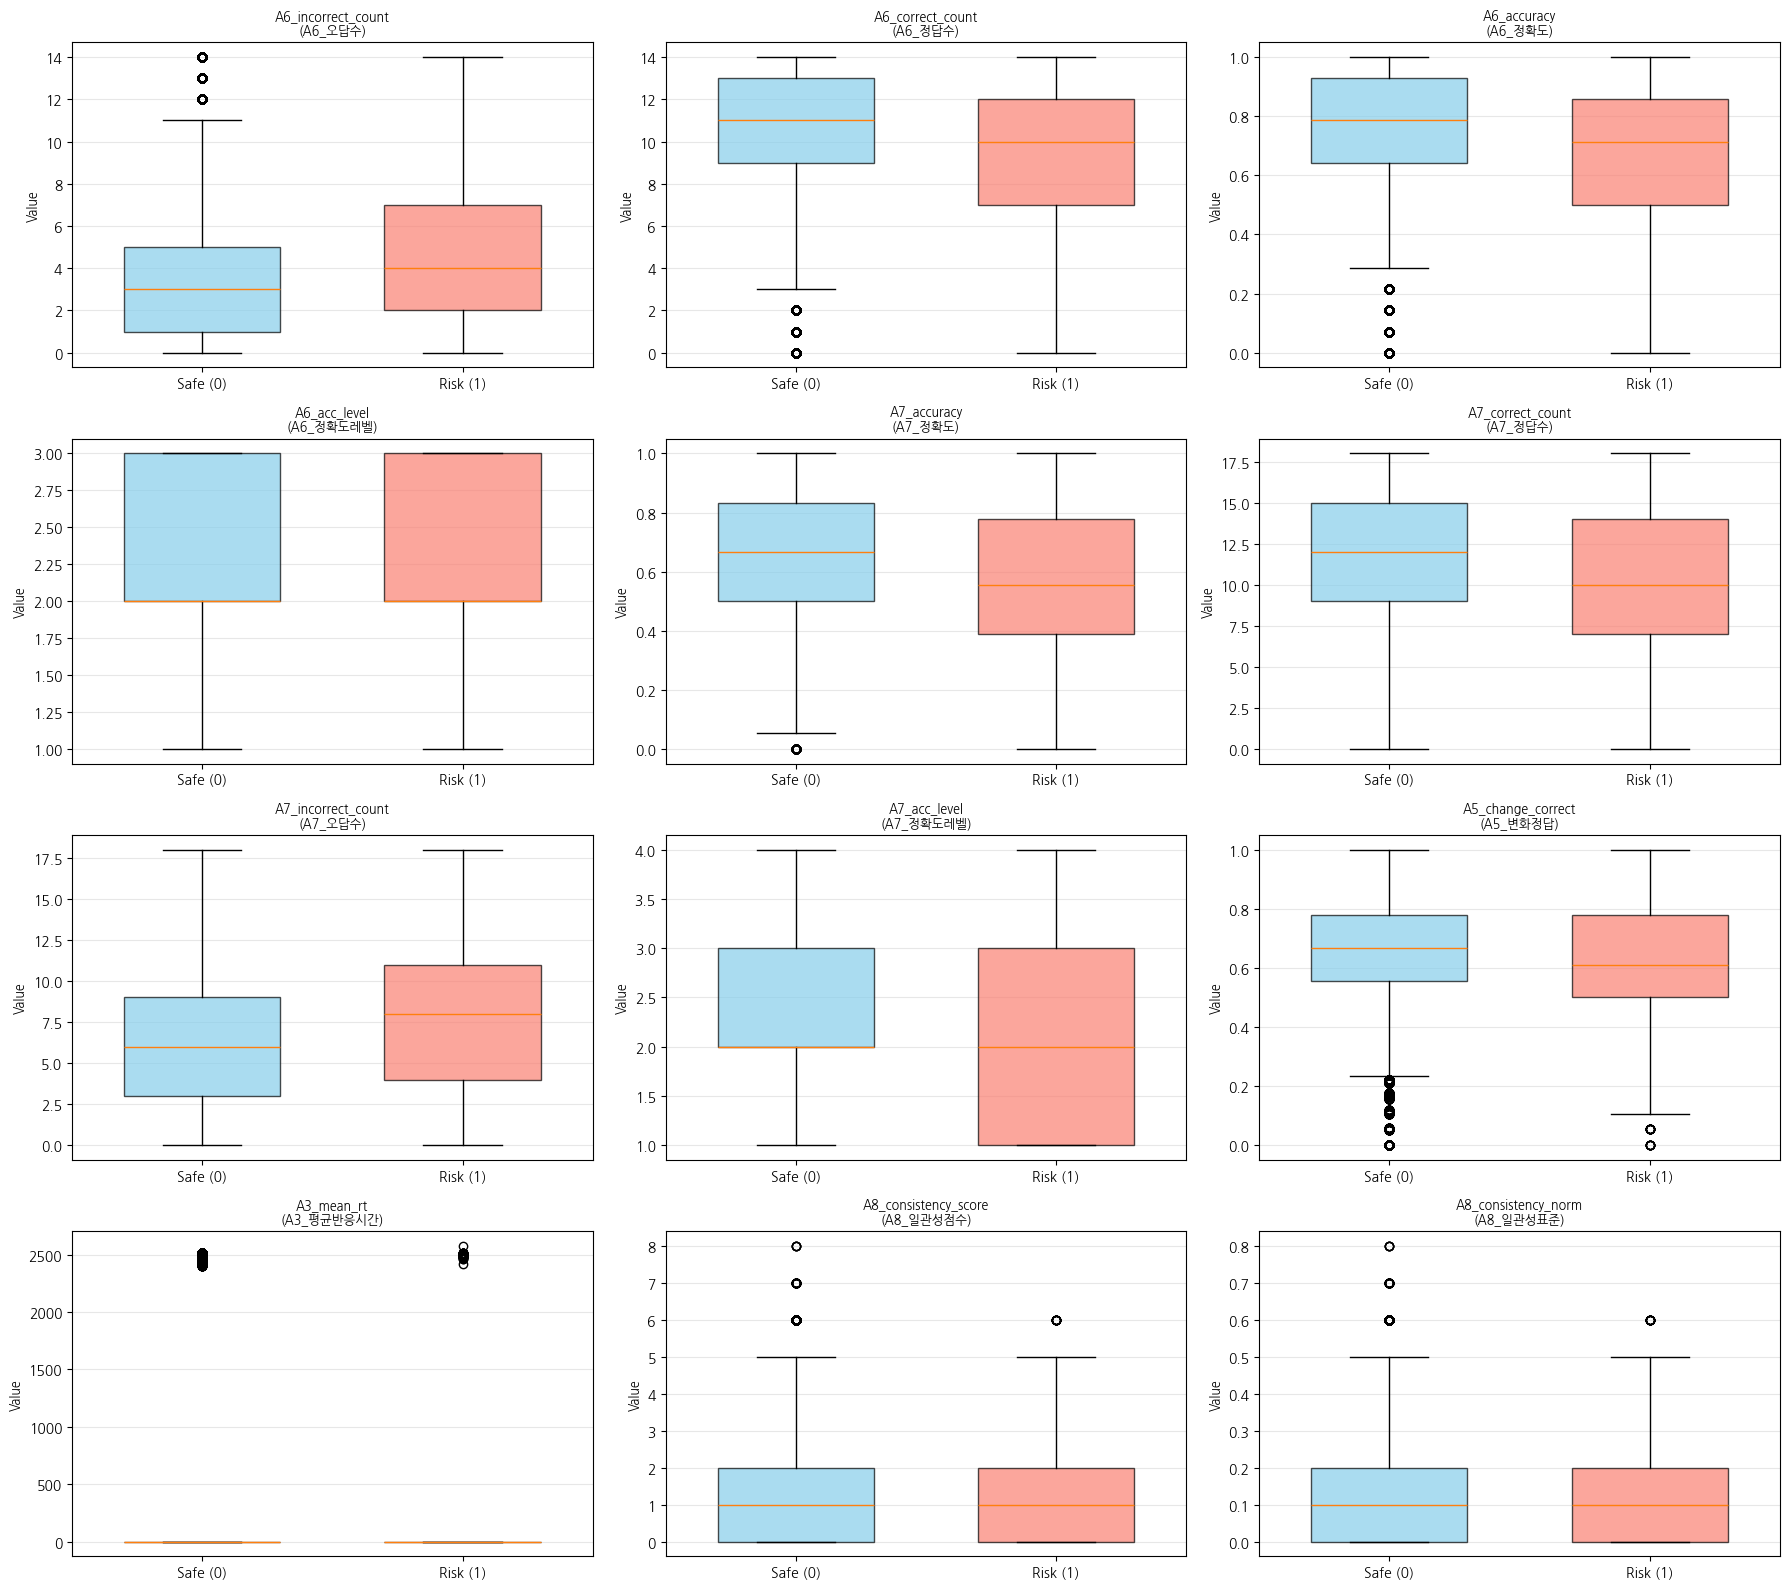

2025-11-11 22:11:15 [I] 
7. Correlation Matrix - A3...
2025-11-11 22:11:16 [I] 
2025-11-11 22:11:16 [I] Correlation with Label - Correlation Matrix - A3
2025-11-11 22:11:16 [I] ================================================================================
2025-11-11 22:11:16 [I] 
                             Feature Correlation Abs_Correlation
0             A3_mean_rt (A3_평균반응시간)      0.0291          0.0291
1           A3B_mean_rt (A3대_평균반응시간)      0.0237          0.0237
2           A3S_mean_rt (A3소_평균반응시간)      0.0233          0.0233
3   A3_valid_invalid_diff (A3_유무효차이)      0.0056          0.0056
4             A3_size_diff (A3_크기차이)     -0.0021          0.0021
5         A3B_correct_rate (A3대_정답률)     -0.0166          0.0166
6         A3_valid_correct (A3_유효정답)     -0.0167          0.0167
7       A3_invalid_correct (A3_무효정답)     -0.0172          0.0172
8    A3_invalid_fail_rate (A3_무효실패율)     -0.0173          0.0173
9         A3S_correct_rate (A3소_정답률)     -0.0177          0.0177
10

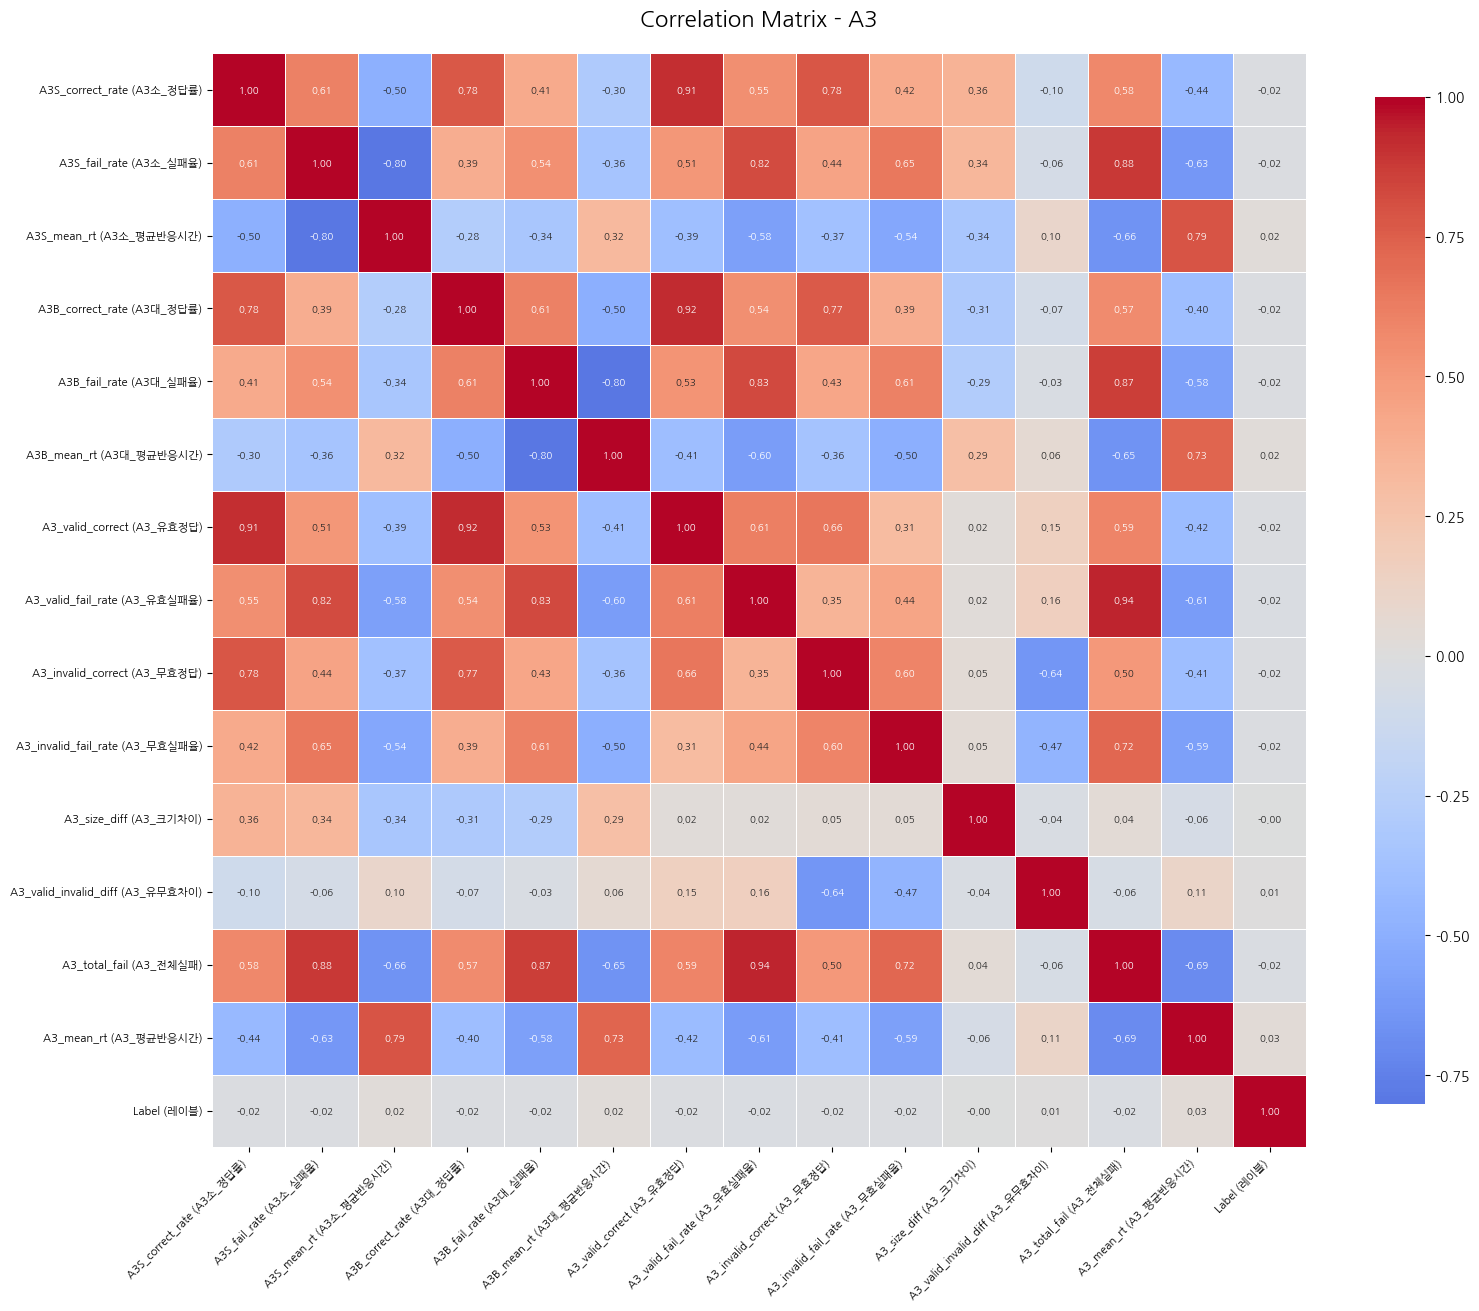

2025-11-11 22:11:18 [I] 
7. Correlation Matrix - A5...
2025-11-11 22:11:19 [I] 
2025-11-11 22:11:19 [I] Correlation with Label - Correlation Matrix - A5
2025-11-11 22:11:19 [I] ================================================================================
2025-11-11 22:11:19 [I] 
                           Feature Correlation Abs_Correlation
0          A5_total_fail (A5_전체실패)     -0.0119          0.0119
1          A5_sensitivity (A5_민감도)     -0.0135          0.0135
2  A5_no_change_correct (A5_무변화정답)     -0.0151          0.0151
3      A5_change_correct (A5_변화정답)     -0.0334          0.0334

2025-11-11 22:11:20 [I]   ✓ Plot saved: D:\GoogleDrive\modeling\driver_aptitude\plots\A\03_correlation_matrix_A5.png


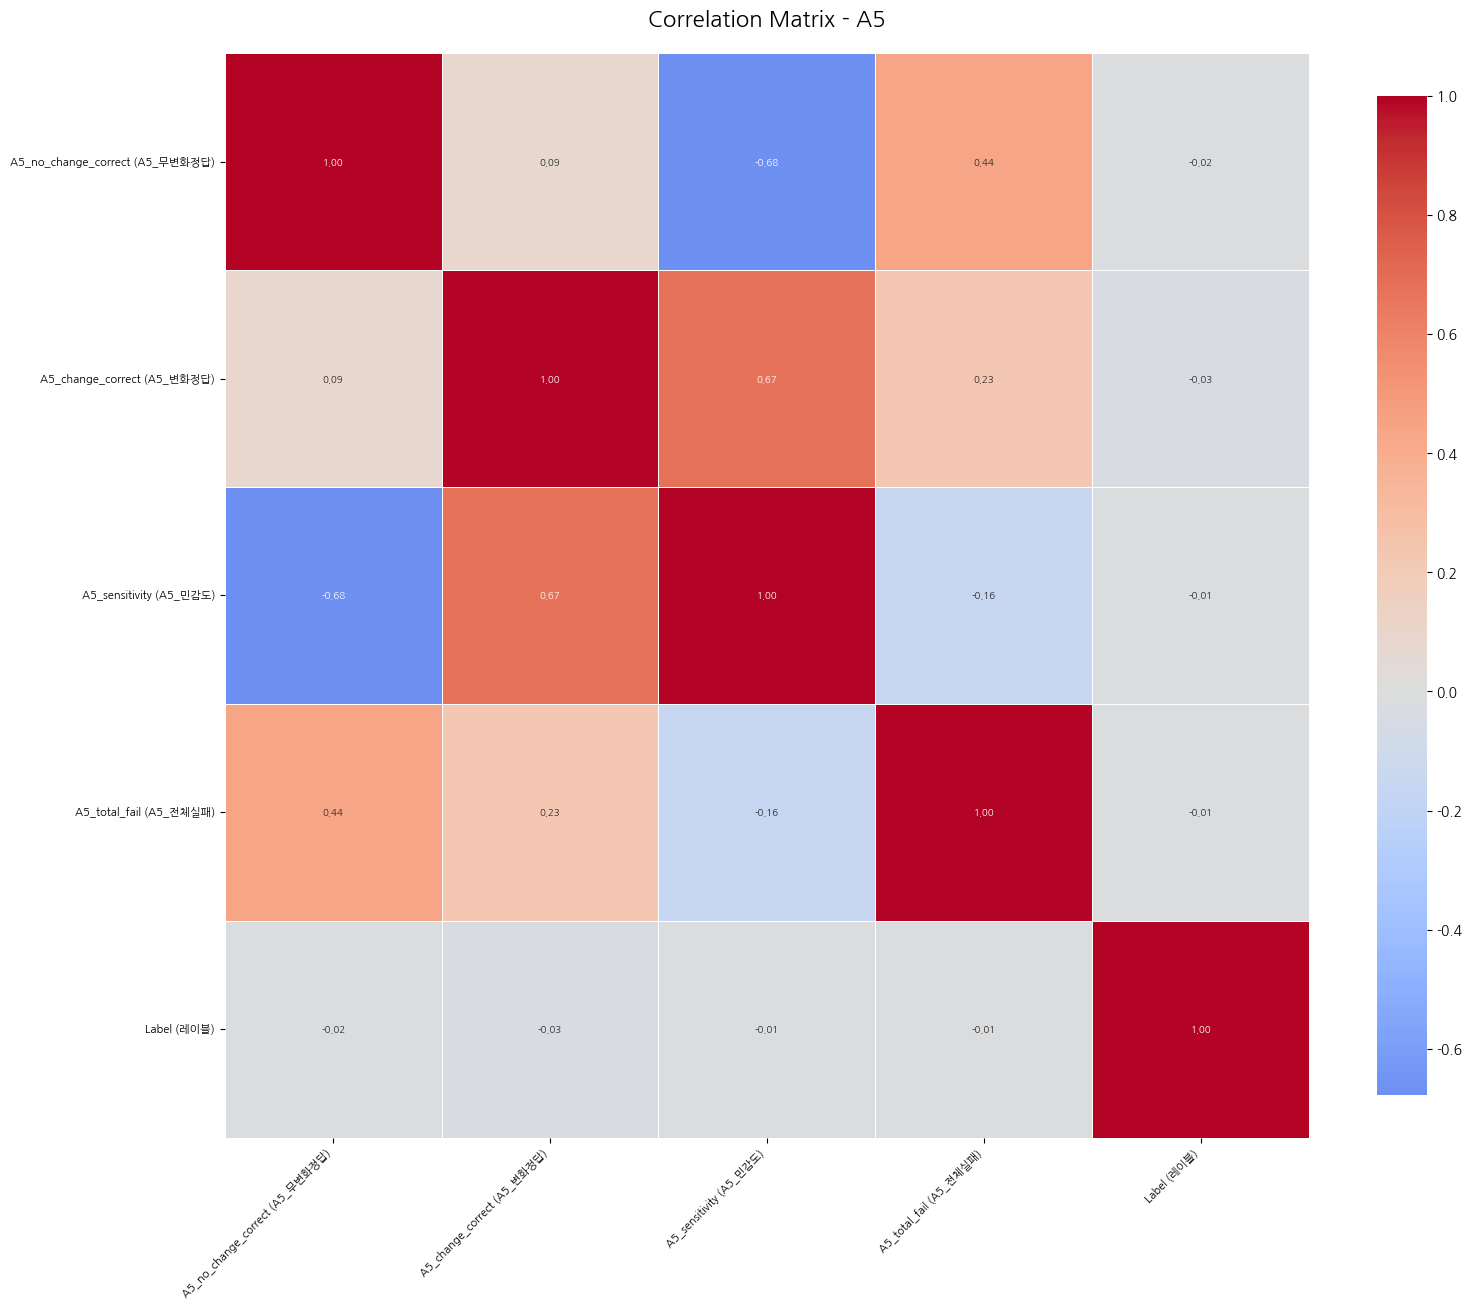

2025-11-11 22:11:21 [I] 
7. Correlation Matrix - A9...
2025-11-11 22:11:24 [I] 
2025-11-11 22:11:24 [I] Correlation with Label - Correlation Matrix - A9
2025-11-11 22:11:24 [I] ================================================================================
2025-11-11 22:11:24 [I] 
                            Feature Correlation Abs_Correlation
0         A9_too_fast_cnt (A9_과속횟수)      0.0080          0.0080
1              A9_rt_mean (A9_반응평균)      0.0055          0.0055
2               A9_rt_max (A9_반응최대)      0.0055          0.0055
3             A9_rt_q25 (A9_반응1사분위)      0.0055          0.0055
4             A9_rt_q75 (A9_반응3사분위)      0.0055          0.0055
5               A9_rt_min (A9_반응최소)      0.0055          0.0055
6          A9_cond3_acc (A9_조건3정확도)     -0.0011          0.0011
7          A9_cond2_acc (A9_조건2정확도)     -0.0021          0.0021
8            A9_nogo_acc (A9_노고정확도)     -0.0021          0.0021
9         A9_correct_rt (A9_정답반응시간)     -0.0032          0.0032
10           

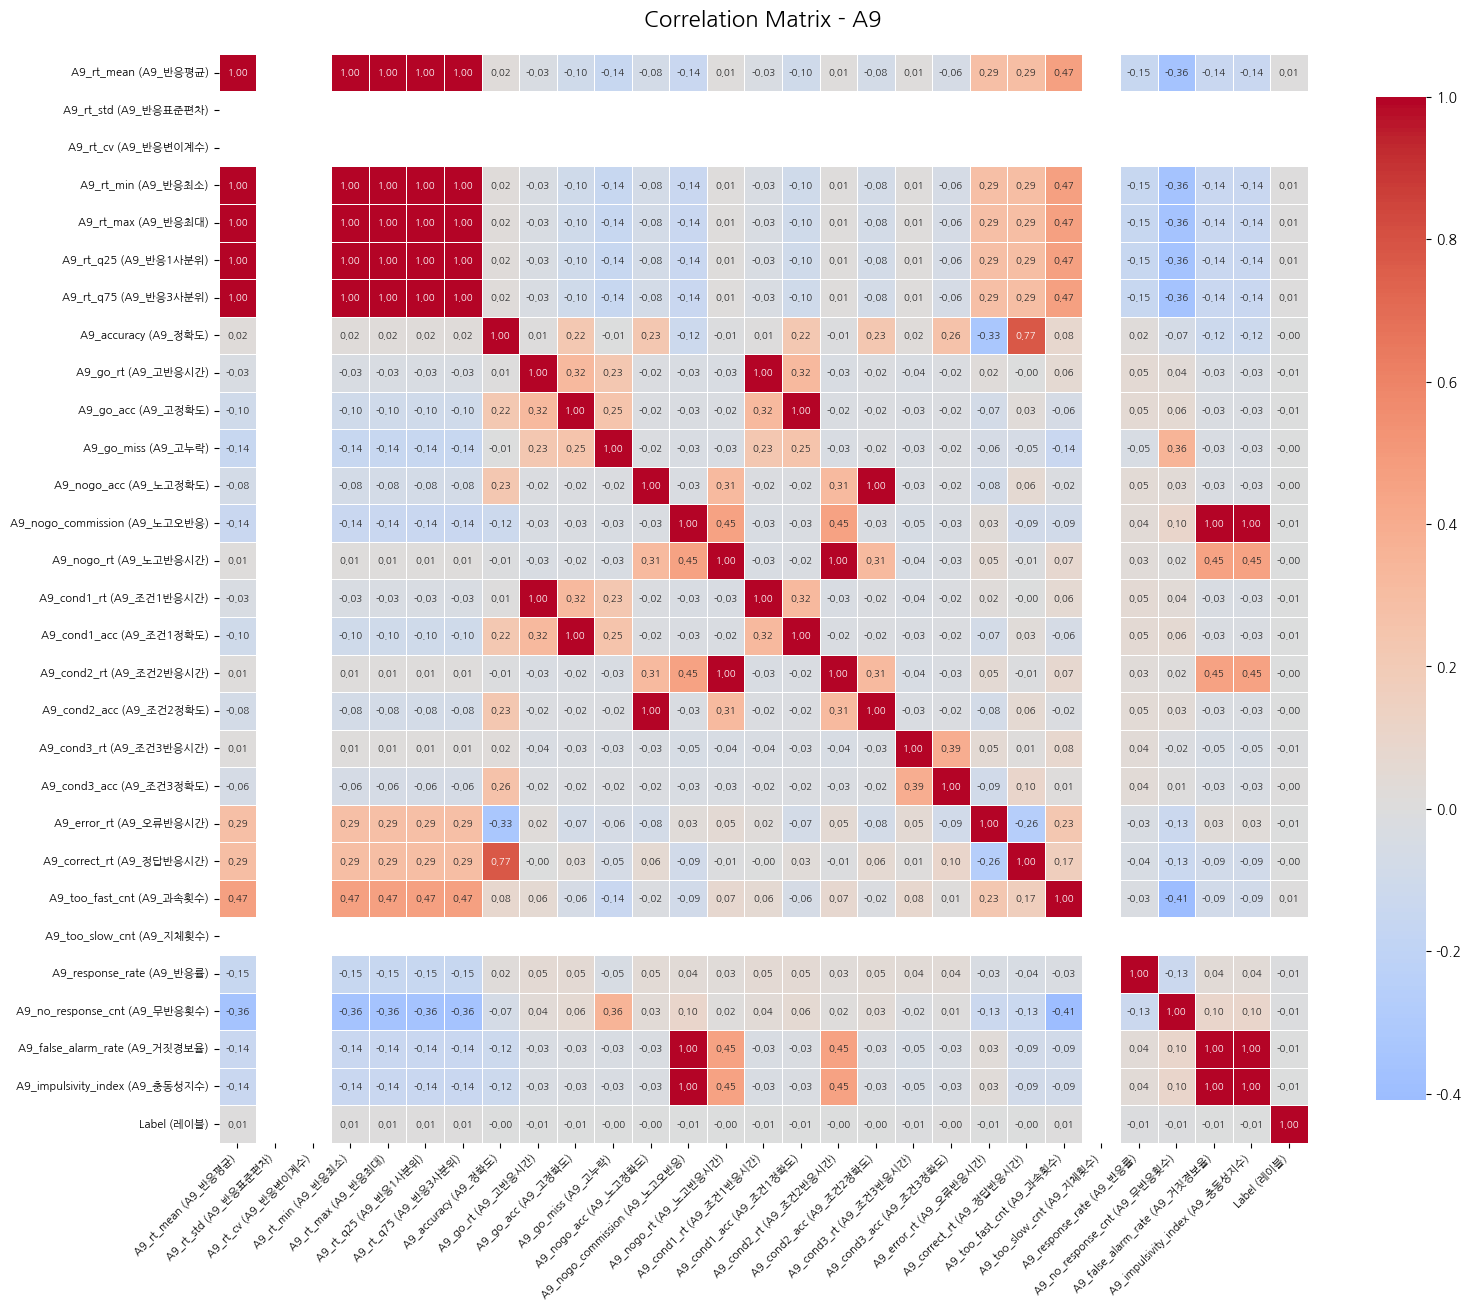

2025-11-11 22:11:29 [I] 
2025-11-11 22:11:29 [I] ✓ Full Analysis Report Generated - A Test
2025-11-11 22:11:29 [I]   Plots saved to: D:\GoogleDrive\modeling\driver_aptitude\plots\A
2025-11-11 22:11:29 [I] ================================================================================
2025-11-11 22:11:29 [D] Loading B test data from: d:\temp\open_v2_clean.zip.unzip\train_B_.jsonl
2025-11-11 22:12:07 [D] ✓ Data loaded successfully: (297513, 156)
2025-11-11 22:12:07 [D] 
Preprocessing data...
2025-11-11 22:12:07 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-11 22:12:07 [D]   - No missing values found
2025-11-11 22:12:07 [D] ✓ Preprocessing completed: (297513, 152)
2025-11-11 22:12:07 [D] 
Splitting data...
2025-11-11 22:12:08 [D]   - Train: 238010 (80.0%)
2025-11-11 22:12:08 [D]     Label 0: 227940, Label 1: 10070
2025-11-11 22:12:08 [D]   - Val:   29751 (10.0%)
2025-11-11 22:12:08 [D]     Label 0: 28492, Label 1: 1259
2025-11-11 22:12:08 [D]   - Test

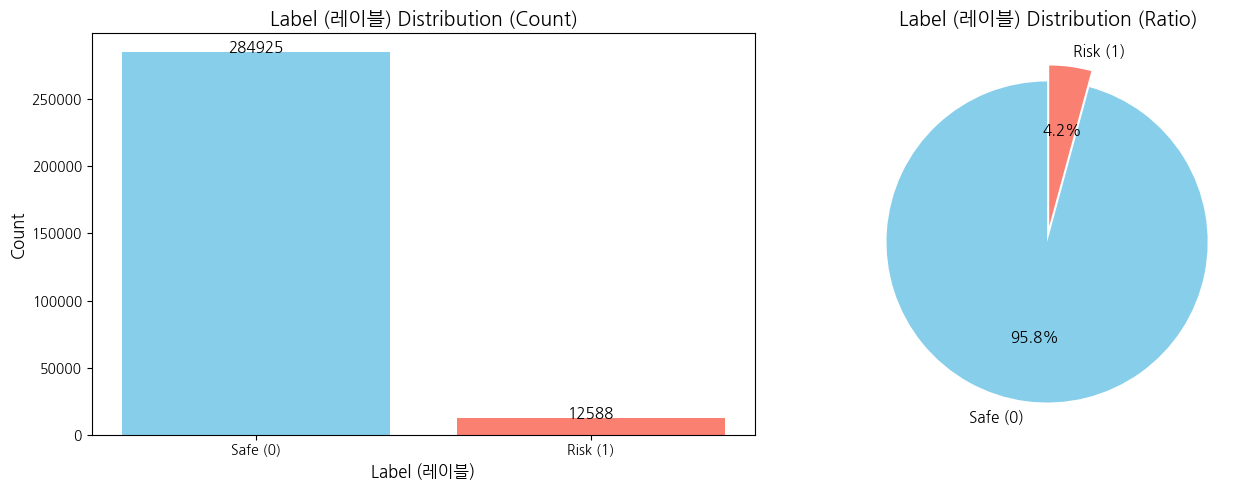

2025-11-11 22:12:08 [I] 
2. Feature Distributions...
2025-11-11 22:12:13 [I] 
2025-11-11 22:12:13 [I] Feature Distribution Statistics (Top 20)
2025-11-11 22:12:13 [I] ================================================================================
2025-11-11 22:12:13 [I] 
                          Feature Safe_Mean Risk_Mean    Diff Safe_Std Risk_Std
0            B1_rt_mean (B1_반응평균)    0.5595    0.5696  0.0101   0.4082   0.4031
1           B1_rt_std (B1_반응표준편차)    0.0881    0.0913  0.0032   0.0843   0.0866
2            B1_rt_cv (B1_반응변이계수)    0.1249    0.1302  0.0053   0.1621   0.1659
3             B1_rt_min (B1_반응최소)    0.4467    0.4526  0.0058   0.3500   0.3466
4             B1_rt_max (B1_반응최대)    0.7051    0.7204  0.0153   0.5022   0.4969
5           B1_rt_q25 (B1_반응1사분위)    0.5029    0.5113  0.0084   0.3793   0.3751
6           B1_rt_q75 (B1_반응3사분위)    0.6056    0.6174  0.0118   0.4414   0.4364
7            B1_accuracy (B1_정확도)    0.2863    0.2940  0.0077   0.2157   0.2139
8      

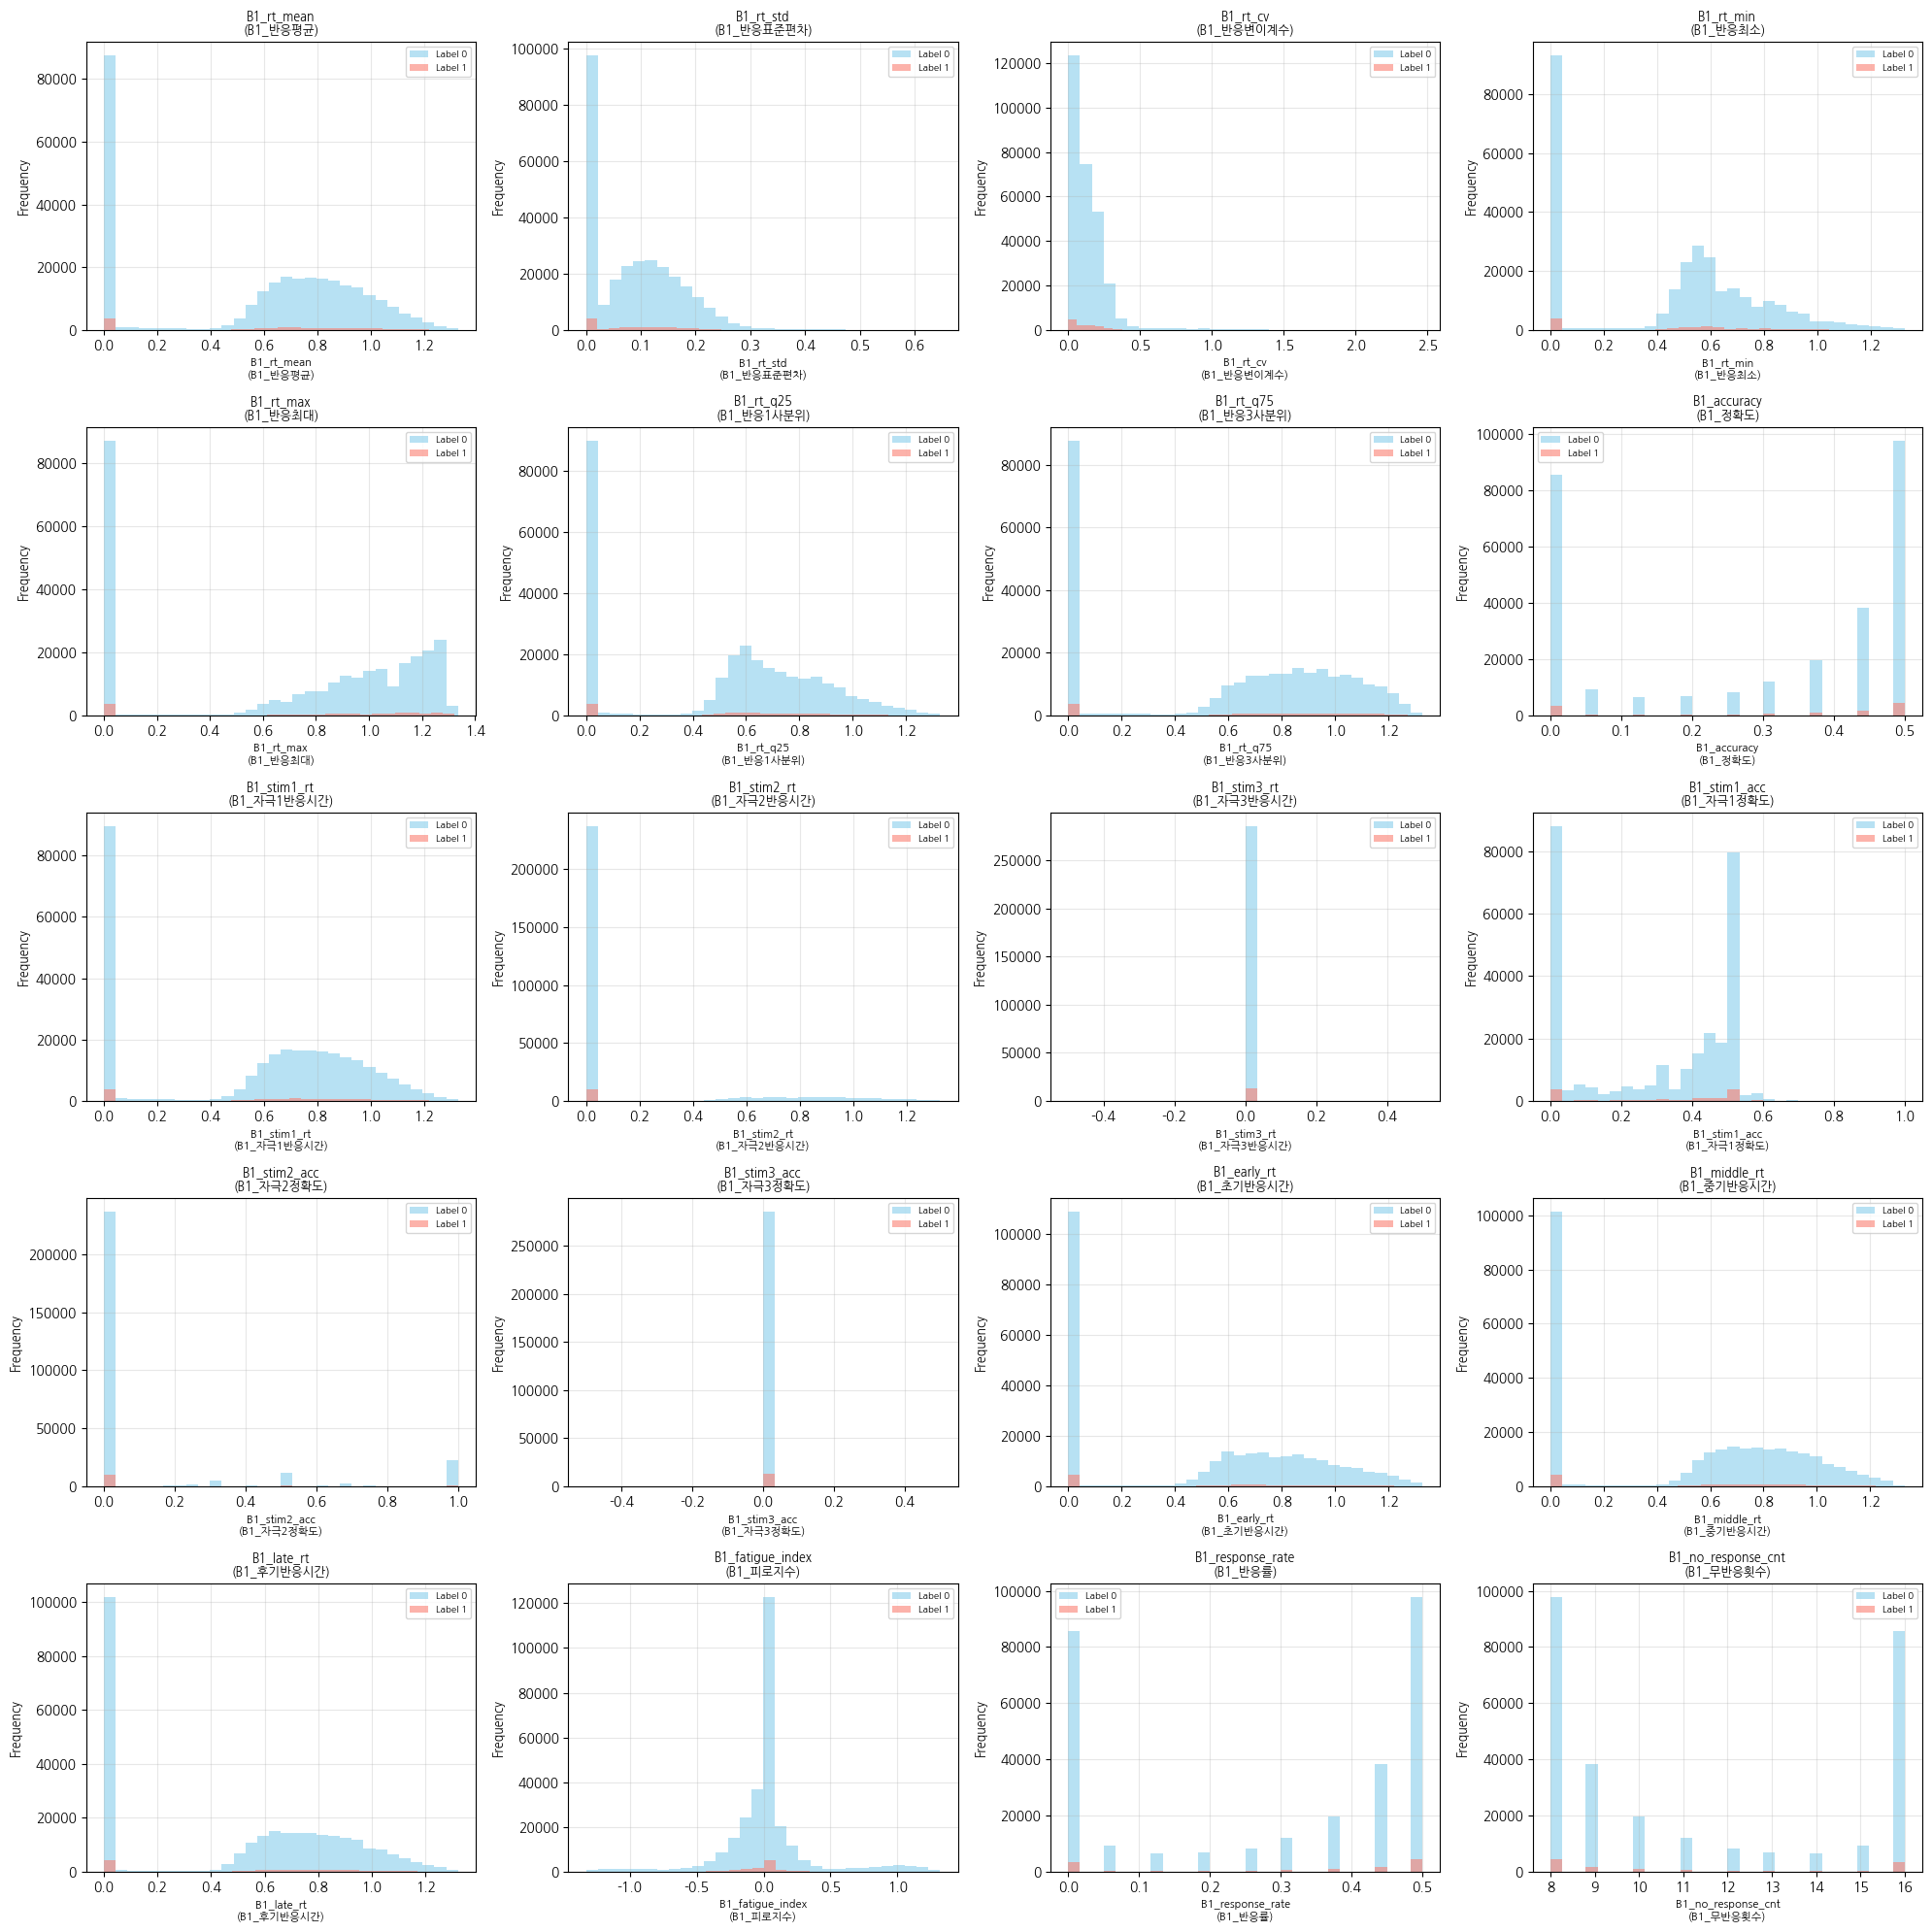

2025-11-11 22:12:35 [I] 
3. Correlation Analysis...
2025-11-11 22:12:39 [I] 
2025-11-11 22:12:39 [I] Correlation with Label - Correlation Matrix - Top 30 Features
2025-11-11 22:12:39 [I] ================================================================================
2025-11-11 22:12:39 [I] 
                               Feature Correlation Abs_Correlation
0           B8_unique_values (B8_고유값수)      0.0125          0.0125
1            B7_type2_count (B7_유형2개수)      0.0118          0.0118
2            B7_type2_ratio (B7_유형2비율)      0.0118          0.0118
3      B2_type3_error_rate (B2_유형3오류율)      0.0118          0.0118
4               B8_mean_value (B8_평균값)      0.0115          0.0115
5              B7_switch_rate (B7_전환율)      0.0110          0.0110
6            B7_switch_count (B7_전환횟수)      0.0110          0.0110
7          B9_nonzero_count (B9_비영값개수)      0.0110          0.0110
8             B2_stim1_acc (B2_자극1정확도)      0.0108          0.0108
9            B2_response_rate (B2_반응률

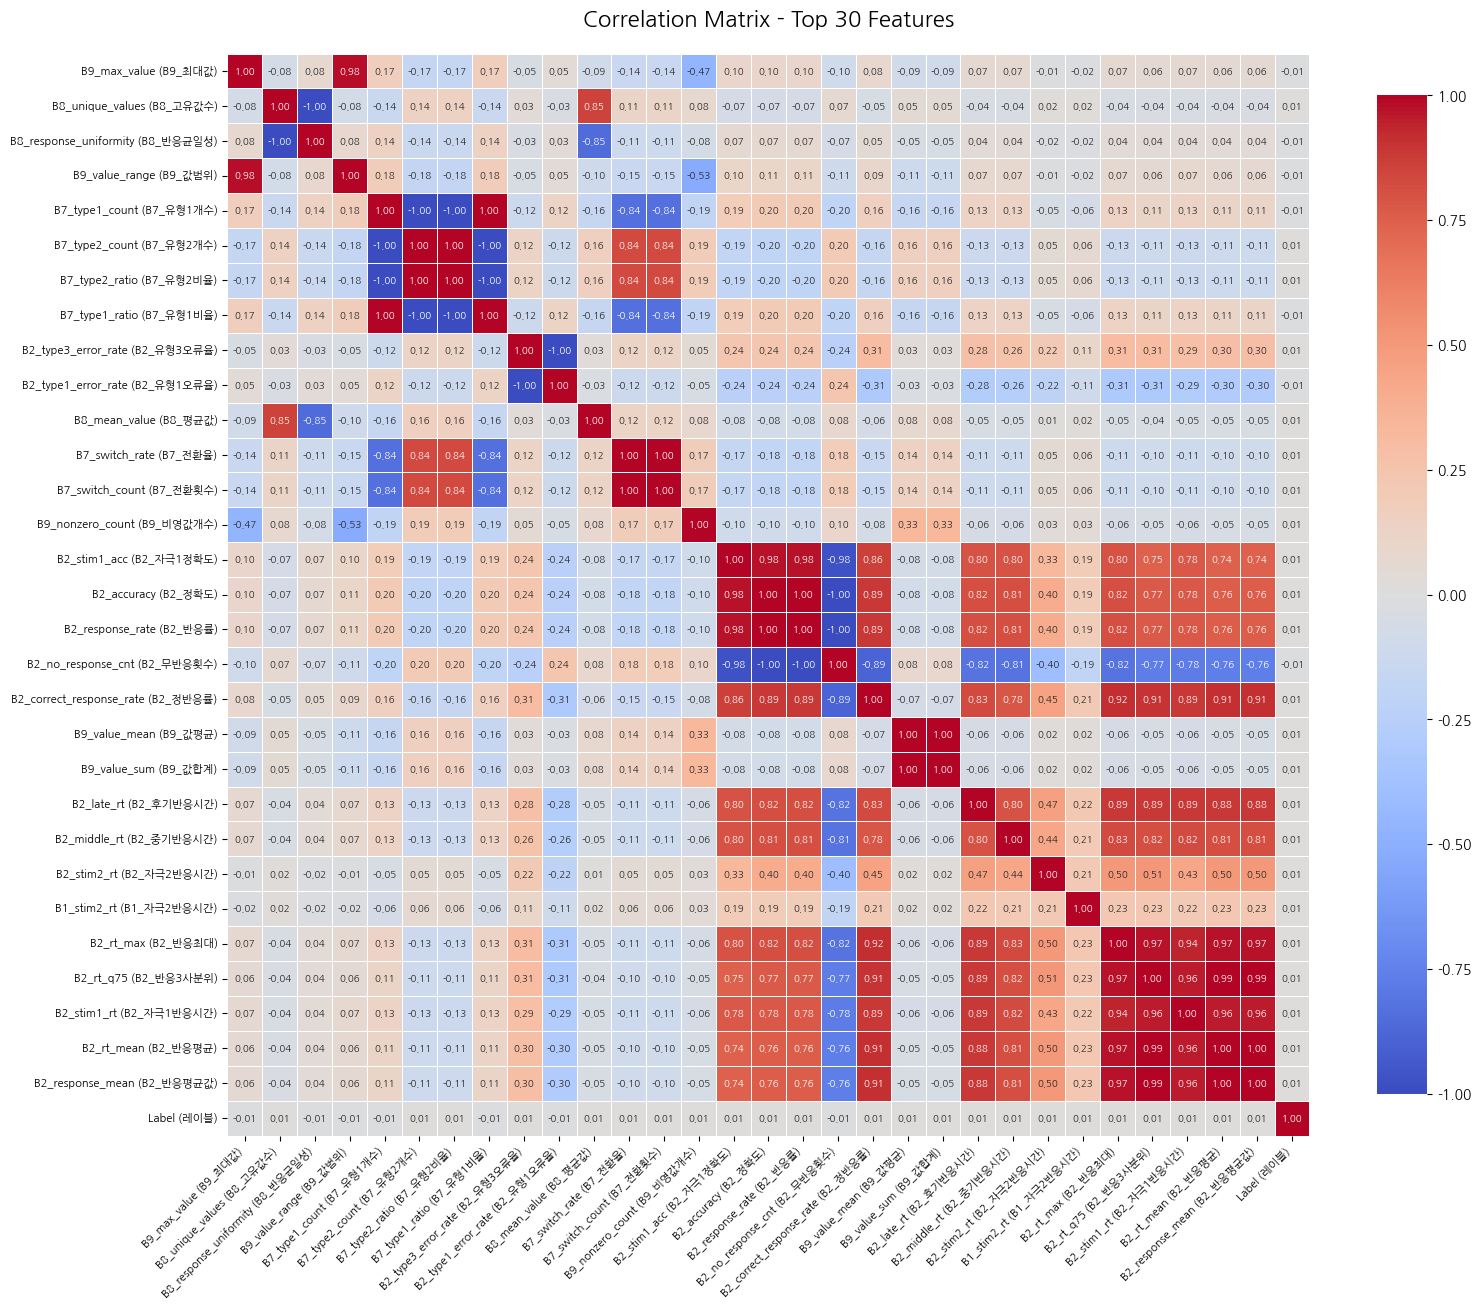

2025-11-11 22:12:45 [I] 
4. Preliminary Feature Importance...
2025-11-11 22:12:47 [I] 
2025-11-11 22:12:47 [I] Top 20 Feature Importance (Preliminary)
2025-11-11 22:12:47 [I] ================================================================================
2025-11-11 22:12:47 [I] 
    Rank                             Feature Abs_Correlation Importance_Score
0      1               B9_max_value (B9_최대값)          0.0125          100.00%
1      2          B8_unique_values (B8_고유값수)          0.0125           99.90%
2      3   B8_response_uniformity (B8_반응균일성)          0.0125           99.90%
3      4             B9_value_range (B9_값범위)          0.0125           99.56%
4      5           B7_type1_count (B7_유형1개수)          0.0118           94.33%
5      6           B7_type2_count (B7_유형2개수)          0.0118           94.33%
6      7           B7_type2_ratio (B7_유형2비율)          0.0118           94.33%
7      8           B7_type1_ratio (B7_유형1비율)          0.0118           94.33%
8      9     B2_t

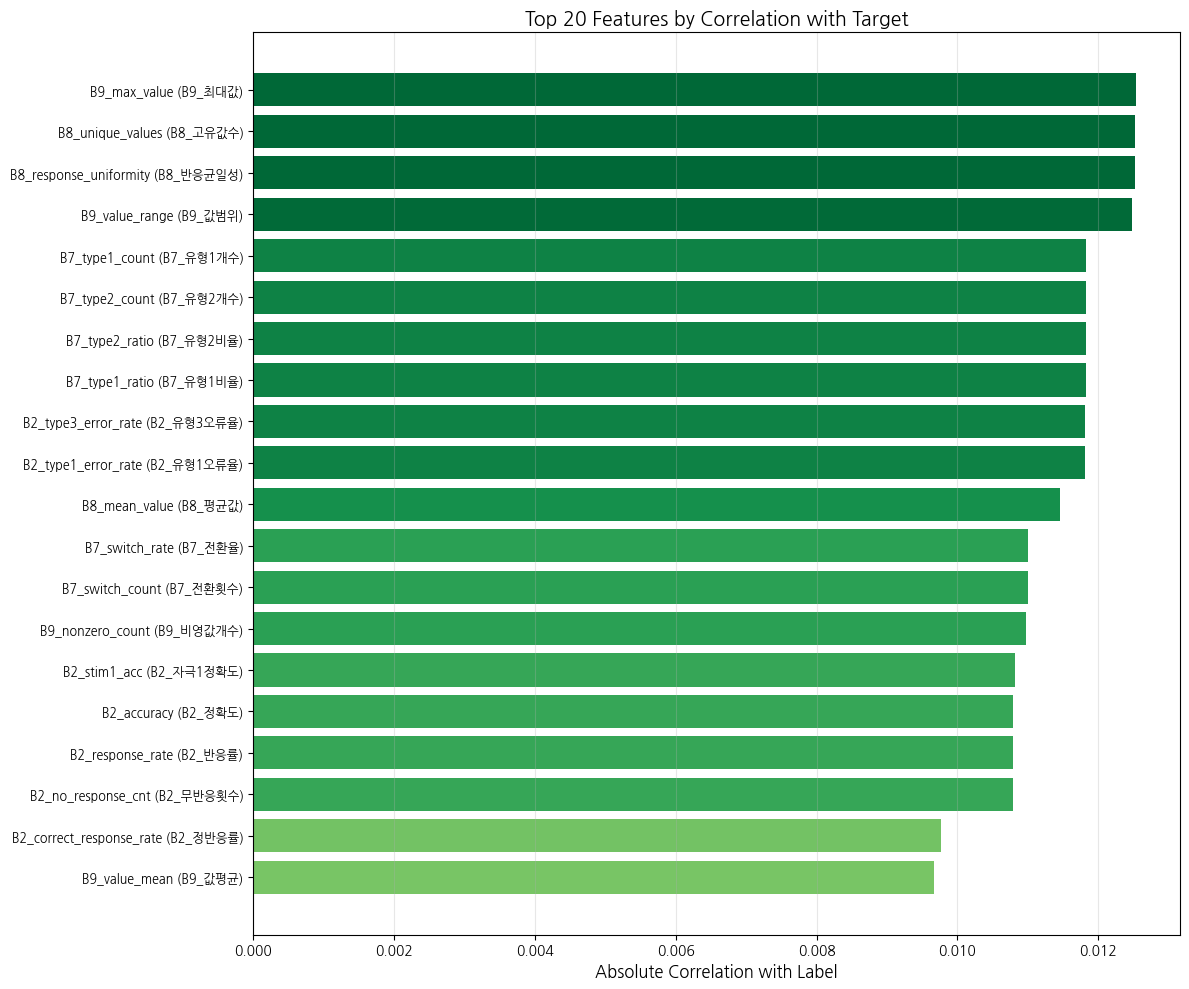

2025-11-11 22:12:48 [I] 
5. Test Group Analysis...
2025-11-11 22:12:51 [I] 
2025-11-11 22:12:51 [I] B Test Group Summary Statistics
2025-11-11 22:12:51 [I] ================================================================================
2025-11-11 22:12:51 [I] 
  Group  Num_Features Safe_Avg Risk_Avg Avg_Diff Max_Diff
0    B1            24   0.8832   0.8873   0.0041   0.1236
1    B2            27   0.7790   0.7834   0.0044   0.1893
2    B3            24   0.6596   0.6592   0.0003   0.0228
3    B4            31   1.7962   1.7943   0.0019   0.0522
4    B5            20   3.2868   3.3302   0.0433   0.1879
5    B6             4   7.7358   7.7357   0.0001   0.0081
6    B7             8   4.4740   4.4927   0.0187   0.1402
7    B8             7   2.3415   2.3418   0.0003   0.0221
8    B9             6  22.3989  22.4004   0.0014   0.1589

2025-11-11 22:12:58 [I]   ✓ Plot saved: D:\GoogleDrive\modeling\driver_aptitude\plots\B\05_test_group_analysis.png


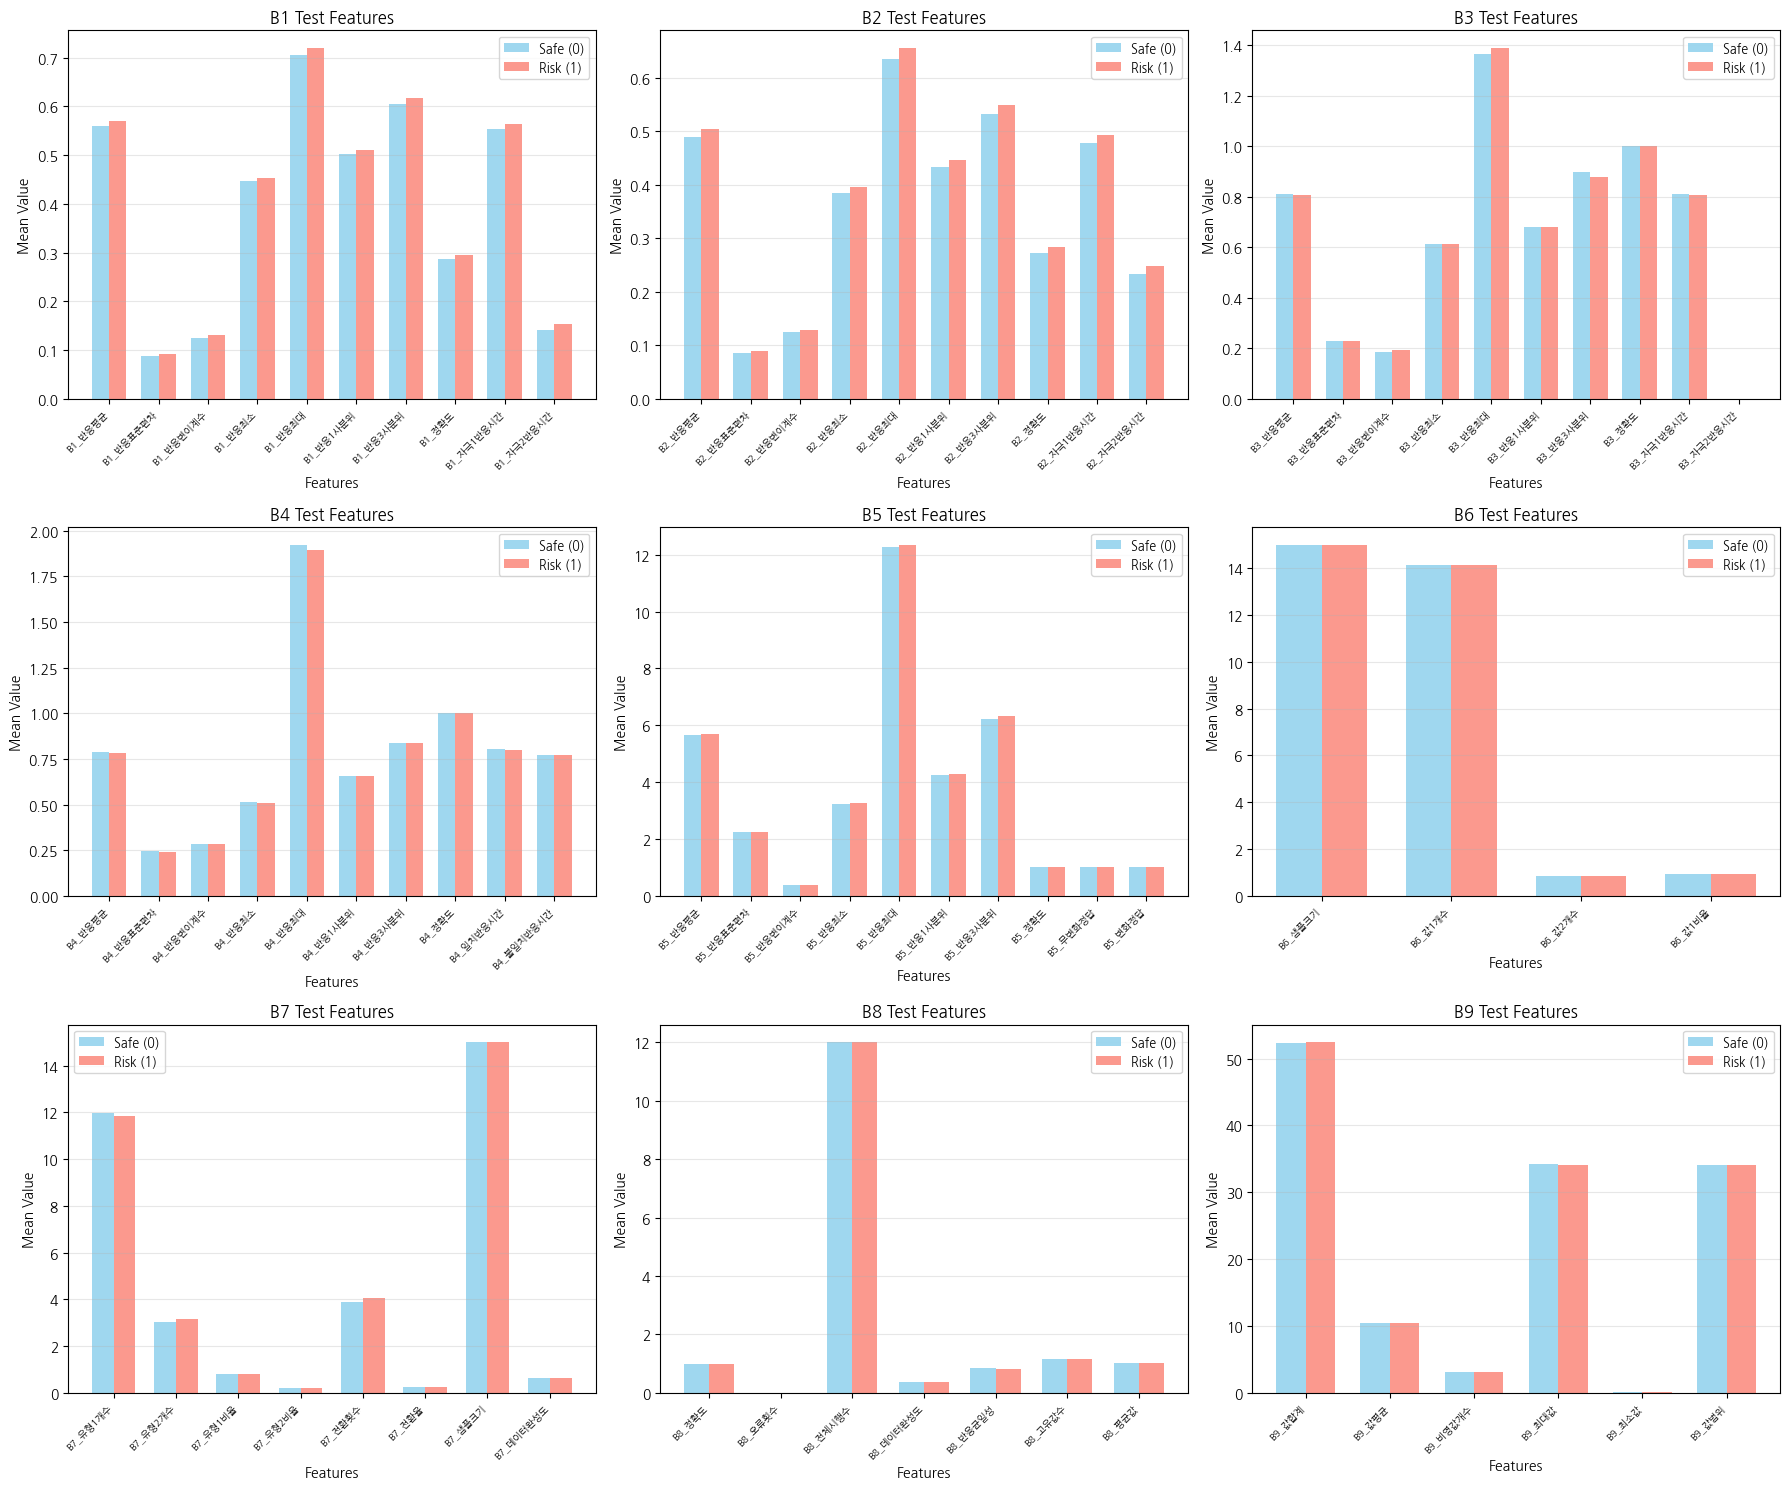

2025-11-11 22:13:01 [I] 
6. Boxplot Analysis...
2025-11-11 22:13:07 [I] 
2025-11-11 22:13:07 [I] Boxplot Statistics (Top 12 Features)
2025-11-11 22:13:07 [I] ================================================================================
2025-11-11 22:13:07 [I] 
                              Feature  Safe_Q1 Safe_Median  Safe_Q3  Risk_Q1 Risk_Median  Risk_Q3 Median_Diff
0               B9_max_value (B9_최대값)  34.0000     35.0000  35.0000  34.0000     35.0000  35.0000      0.0000
1          B8_unique_values (B8_고유값수)   1.0000      1.0000   1.0000   1.0000      1.0000   1.0000      0.0000
2   B8_response_uniformity (B8_반응균일성)   1.0000      1.0000   1.0000   1.0000      1.0000   1.0000      0.0000
3             B9_value_range (B9_값범위)  34.0000     35.0000  35.0000  34.0000     35.0000  35.0000      0.0000
4           B7_type1_count (B7_유형1개수)  11.0000     12.0000  14.0000  11.0000     12.0000  14.0000      0.0000
5           B7_type2_count (B7_유형2개수)   1.0000      3.0000   4.0000   1.0000

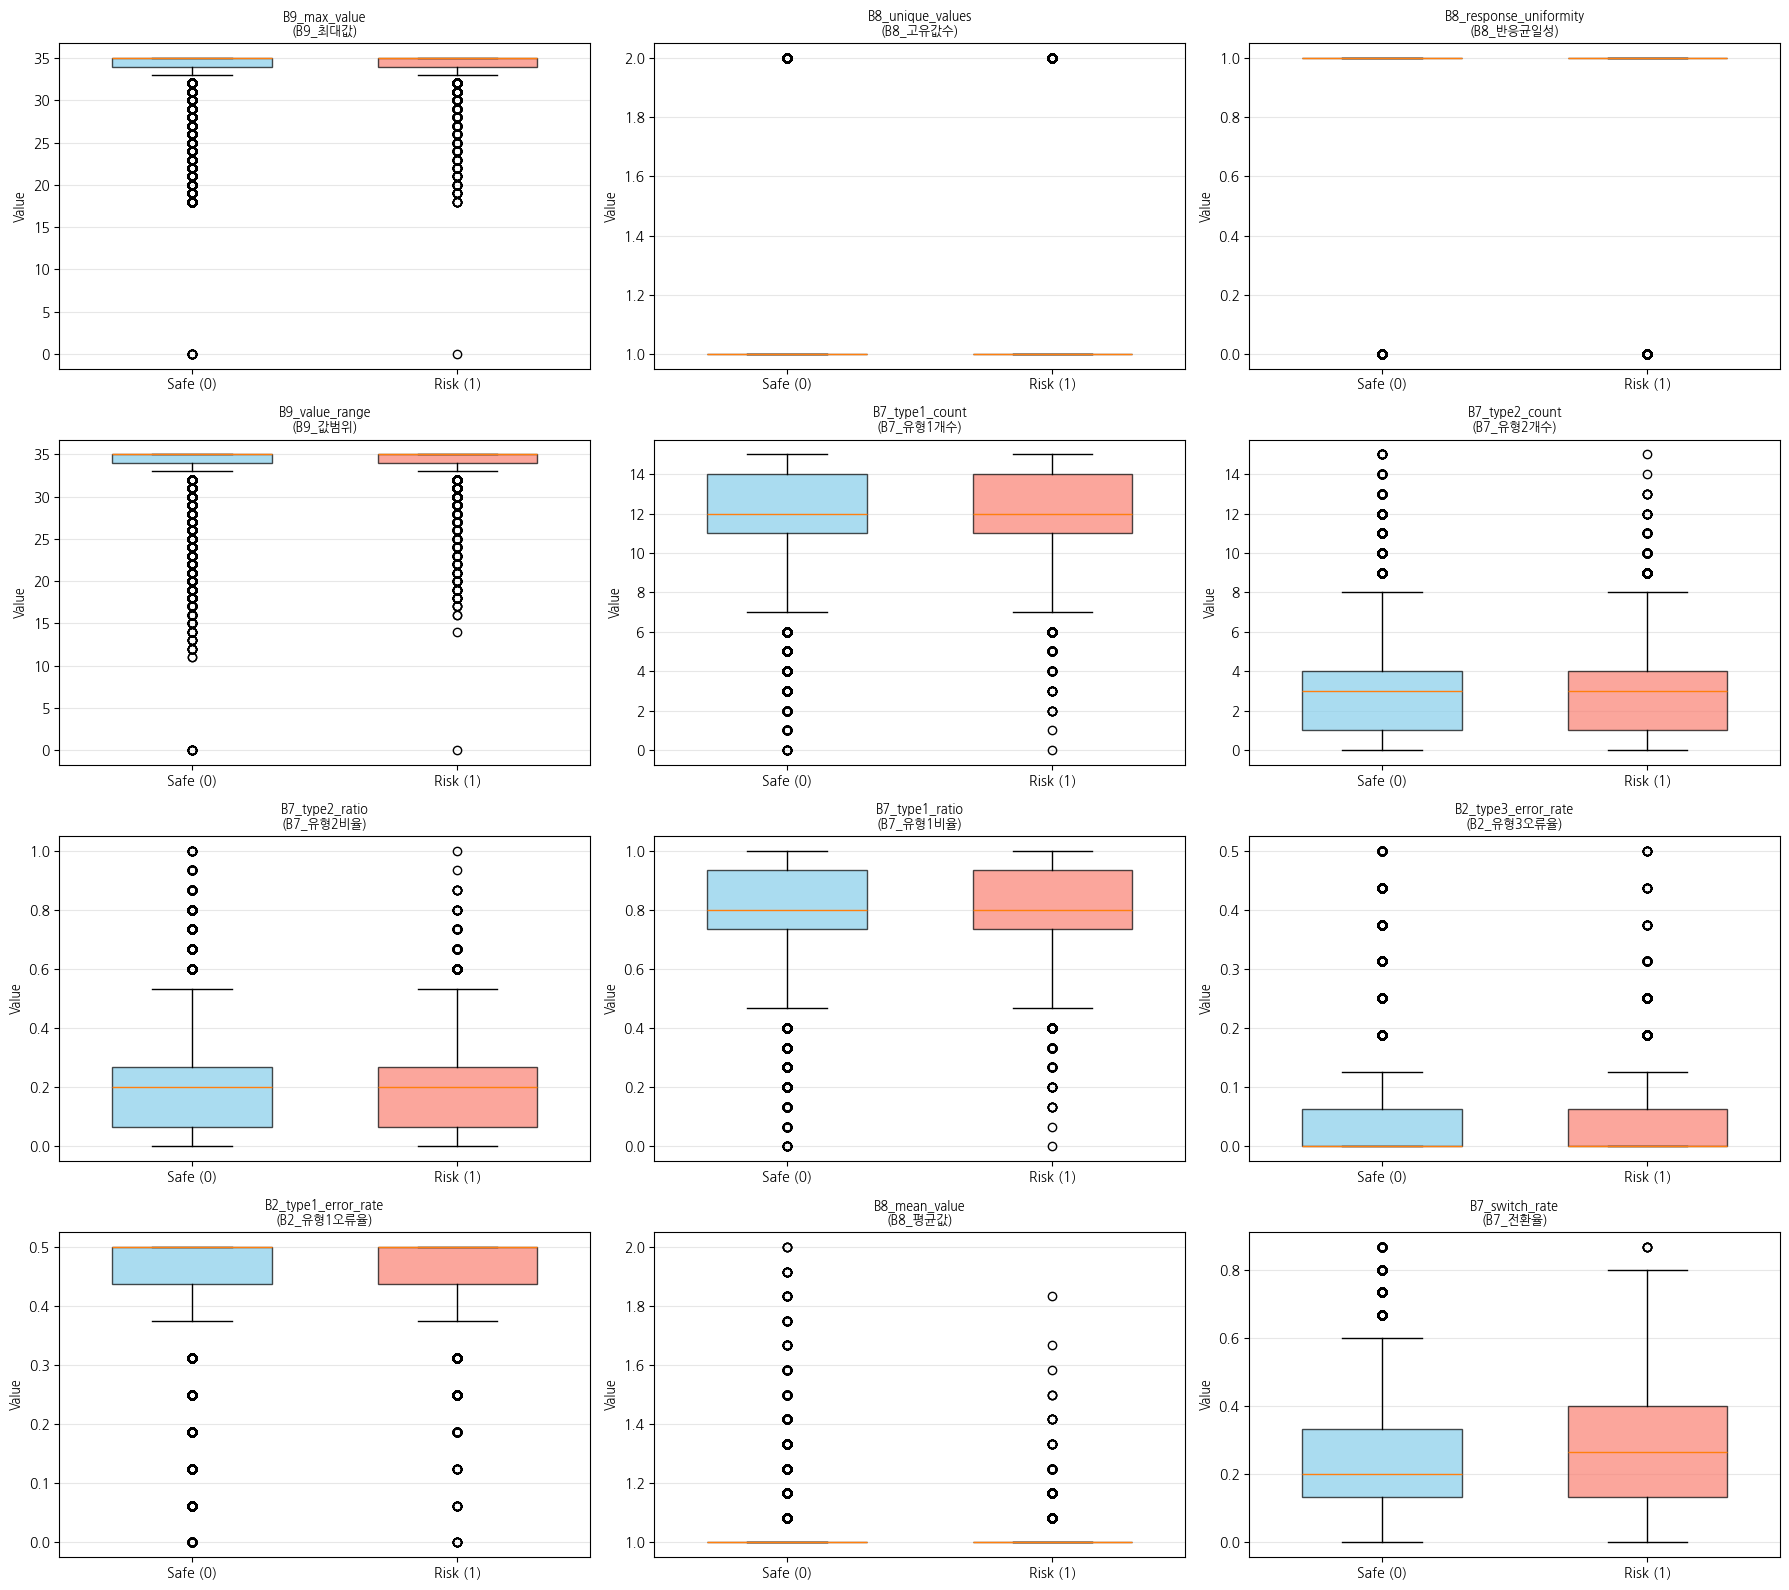

2025-11-11 22:13:18 [I] 
7. Correlation Matrix - B1...
2025-11-11 22:13:18 [I] Warning: Unknown feature group 'B1'
2025-11-11 22:13:18 [I] 
7. Correlation Matrix - B4...
2025-11-11 22:13:18 [I] Warning: Unknown feature group 'B4'
2025-11-11 22:13:18 [I] 
7. Correlation Matrix - B5...
2025-11-11 22:13:18 [I] Warning: Unknown feature group 'B5'
2025-11-11 22:13:18 [I] 
2025-11-11 22:13:18 [I] ✓ Full Analysis Report Generated - B Test
2025-11-11 22:13:18 [I]   Plots saved to: D:\GoogleDrive\modeling\driver_aptitude\plots\B
2025-11-11 22:13:18 [I] ================================================================================


In [14]:

"""
데이터 분석 및 시각화 파이프라인
Data Analysis and Visualization Pipeline
"""

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from typing import Optional, List, Dict, Tuple
# import warnings
# warnings.filterwarnings('ignore')


class DataAnalyzer:
    """운수종사자 적성검사 데이터 분석 및 시각화"""

    def __init__(self, config, data_loader, col_kr_dict=None):
        """
        Args:
            config: ProjectConfig 인스턴스
            data_loader: DataLoader 인스턴스
            col_kr_dict: 영문-한글 컬럼명 매핑 딕셔너리
        """
        self.config = config
        self.loader = data_loader

        # 한글 딕셔너리 설정 (None이면 검사 타입별 기본값)
        if col_kr_dict is None:
            self.col_kr_dict = col_kr_dict_B if self.config.data.test_type == "B" else col_kr_dict_A
        else:
            self.col_kr_dict = col_kr_dict

        self.plot_dir = Path(config.data.output_dir) / "plots" / self.config.data.test_type
        self.plot_dir.mkdir(parents=True, exist_ok=True)

        # 시각화 스타일 설정
        # try:
        #     plt.style.use(config.visualization.style)
        # except:
        #     plt.style.use('default')
        # plt.rcParams['axes.unicode_minus'] = False

    def _get_display_name(self, feature: str) -> str:
        """
        피처명을 영문(한글) 형식으로 변환

        Args:
            feature: 영문 피처명

        Returns:
            str: "영문(한글)" 형식의 표시명
        """
        if feature in self.col_kr_dict:
            return f"{feature}\n({self.col_kr_dict[feature]})"
        return feature

    def _save_plot(self, filename: str):
        """그래프 저장"""
        if self.config.visualization.save_plots:
            filepath = self.plot_dir / f"{filename}.{self.config.visualization.plot_format}"
            plt.savefig(filepath, dpi=self.config.visualization.dpi, bbox_inches='tight')
            logger.info(f"  ✓ Plot saved: {filepath}")

    def _log_dataframe(self, df: pd.DataFrame, title: str = ""):
        """
        DataFrame을 테이블 형태로 로그 출력

        Args:
            df: 출력할 DataFrame
            title: 테이블 제목
        """
        if title:
            logger.info(f"\n{'='*80}")
            logger.info(f"{title}")
            logger.info(f"{'='*80}")

        # DataFrame을 문자열로 변환하여 출력
        logger.info(f"\n{df.to_string()}\n")

    def plot_label_distribution(self, df: Optional[pd.DataFrame] = None):
        """
        레이블 분포 시각화

        Args:
            df: 분석할 데이터프레임 (None이면 전체 데이터 사용)
        """
        if df is None:
            df = self.loader.data

        target_col = self.config.data.target_col
        target_display = self._get_display_name(target_col).replace('\n', ' ')

        # 통계 DataFrame 생성
        label_counts = df[target_col].value_counts().sort_index()
        stats_df = pd.DataFrame({
            'Label': ['Safe (0)', 'Risk (1)'],
            'Count': label_counts.values,
            'Percentage': [f"{v/len(df)*100:.2f}%" for v in label_counts.values],
            'Ratio': [f"{label_counts[0]/label_counts[1]:.2f}:1", "-"]
        })

        self._log_dataframe(stats_df, f"{target_display} Distribution Statistics")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # 카운트 플롯
        axes[0].bar(label_counts.index, label_counts.values, color=['skyblue', 'salmon'])
        axes[0].set_xlabel(target_display, fontsize=12)
        axes[0].set_ylabel('Count', fontsize=12)
        axes[0].set_title(f'{target_display} Distribution (Count)', fontsize=14, fontweight='bold')
        axes[0].set_xticks([0, 1])
        axes[0].set_xticklabels(['Safe (0)', 'Risk (1)'])

        # 텍스트 추가
        for i, v in enumerate(label_counts.values):
            axes[0].text(i, v + 100, str(v), ha='center', fontsize=11, fontweight='bold')

        # 비율 파이 차트
        colors = ['skyblue', 'salmon']
        explode = (0.05, 0.05)
        axes[1].pie(label_counts.values, labels=['Safe (0)', 'Risk (1)'],
                   autopct='%1.1f%%', colors=colors, explode=explode,
                   startangle=90, textprops={'fontsize': 11})
        axes[1].set_title(f'{target_display} Distribution (Ratio)', fontsize=14, fontweight='bold')

        plt.tight_layout()
        self._save_plot('01_label_distribution')
        plt.show()

    def plot_feature_distributions(self,
                                   features: Optional[List[str]] = None,
                                   max_features: int = 20):
        """
        피처 분포 시각화

        Args:
            features: 시각화할 피처 리스트 (None이면 상위 max_features개 사용)
            max_features: 최대 피처 수
        """
        df = self.loader.data
        target_col = self.config.data.target_col

        if features is None:
            features = self.loader.get_feature_names()[:max_features]

        # 각 피처별 통계 DataFrame 생성
        stats_list = []
        for feature in features:
            safe_data = df[df[target_col] == 0][feature]
            risk_data = df[df[target_col] == 1][feature]

            stats_list.append({
                'Feature': f"{feature} ({self.col_kr_dict.get(feature, '')})",
                'Safe_Mean': f"{safe_data.mean():.4f}",
                'Risk_Mean': f"{risk_data.mean():.4f}",
                'Diff': f"{abs(safe_data.mean() - risk_data.mean()):.4f}",
                'Safe_Std': f"{safe_data.std():.4f}",
                'Risk_Std': f"{risk_data.std():.4f}"
            })

        stats_df = pd.DataFrame(stats_list)
        self._log_dataframe(stats_df, f"Feature Distribution Statistics (Top {len(features)})")

        n_features = len(features)
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
        axes = axes.flatten()

        for idx, feature in enumerate(features):
            ax = axes[idx]
            display_name = self._get_display_name(feature)

            # 각 Label별 분포
            for label in [0, 1]:
                data = df[df[target_col] == label][feature]
                ax.hist(data, bins=30, alpha=0.6,
                       label=f'Label {label}',
                       color='skyblue' if label == 0 else 'salmon')

            ax.set_xlabel(display_name, fontsize=8)
            ax.set_ylabel('Frequency', fontsize=9)
            ax.set_title(display_name, fontsize=9, fontweight='bold')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        # 빈 서브플롯 제거
        for idx in range(n_features, len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        self._save_plot('02_feature_distributions')
        plt.show()

    def plot_correlation_matrix(self,
                                feature_group: Optional[str] = None,
                                top_n: int = 30):
        """
        상관관계 행렬 히트맵

        Args:
            feature_group: 분석할 검사 그룹 (None이면 전체, "A1", "A2" 등)
            top_n: 전체 분석 시 상위 N개 피처
        """
        df = self.loader.data
        target_col = self.config.data.target_col

        # 피처 선택
        if feature_group is not None:
            if feature_group in self.config.data.feature_groups:
                features = self.config.data.feature_groups[feature_group]
                title = f'Correlation Matrix - {feature_group}'
            else:
                logger.info(f"Warning: Unknown feature group '{feature_group}'")
                return
        else:
            # 타겟과의 상관계수 기준 상위 N개
            numeric_features = df.select_dtypes(include=[np.number]).columns
            numeric_features = [f for f in numeric_features if f != target_col]

            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            top_features = correlations.nlargest(top_n).index.tolist()
            features = top_features
            title = f'Correlation Matrix - Top {top_n} Features'

        # 상관관계 계산
        corr_matrix = df[features + [target_col]].corr()

        # Label과의 상관관계 DataFrame 출력
        label_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
        corr_df = pd.DataFrame({
            'Feature': [f"{f} ({self.col_kr_dict.get(f, '')})" for f in label_corr.index],
            'Correlation': [f"{v:.4f}" for v in label_corr.values],
            'Abs_Correlation': [f"{abs(v):.4f}" for v in label_corr.values]
        })

        self._log_dataframe(corr_df, f"Correlation with Label - {title}")

        # 한글 레이블 생성
        display_labels = [self._get_display_name(f).replace('\n', ' ') for f in features + [target_col]]
        corr_matrix.index = display_labels
        corr_matrix.columns = display_labels

        # 히트맵 그리기
        fig, ax = plt.subplots(figsize=(16, 14))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={'size': 7})

        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(rotation=0, fontsize=8)

        plt.tight_layout()
        suffix = feature_group if feature_group else 'top'
        self._save_plot(f'03_correlation_matrix_{suffix}')
        plt.show()

    def plot_feature_importance_preliminary(self, top_n: int = 20):
        """
        타겟과의 상관계수 기반 사전 피처 중요도

        Args:
            top_n: 상위 N개 피처
        """
        df = self.loader.data
        target_col = self.config.data.target_col

        # 수치형 피처만 선택
        numeric_features = df.select_dtypes(include=[np.number]).columns
        numeric_features = [f for f in numeric_features if f != target_col]

        # 타겟과의 상관계수 계산
        correlations = df[numeric_features].corrwith(df[target_col]).abs()
        top_features = correlations.nlargest(top_n).sort_values(ascending=False)

        # 중요도 DataFrame 생성
        importance_df = pd.DataFrame({
            'Rank': range(1, len(top_features) + 1),
            'Feature': [f"{f} ({self.col_kr_dict.get(f, '')})" for f in top_features.index],
            'Abs_Correlation': [f"{v:.4f}" for v in top_features.values],
            'Importance_Score': [f"{v/top_features.values[0]*100:.2f}%" for v in top_features.values]
        })

        self._log_dataframe(importance_df, f"Top {top_n} Feature Importance (Preliminary)")

        # 한글 레이블 생성
        top_features_sorted = top_features.sort_values(ascending=True)
        display_labels = [self._get_display_name(f).replace('\n', ' ') for f in top_features_sorted.index]

        # 시각화
        fig, ax = plt.subplots(figsize=(12, 10))
        colors = plt.cm.RdYlGn(top_features_sorted.values / top_features_sorted.values.max())
        ax.barh(range(len(top_features_sorted)), top_features_sorted.values, color=colors)
        ax.set_yticks(range(len(top_features_sorted)))
        ax.set_yticklabels(display_labels, fontsize=9)
        ax.set_xlabel('Absolute Correlation with Label', fontsize=12)
        ax.set_title(f'Top {top_n} Features by Correlation with Target',
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        self._save_plot('04_feature_importance_preliminary')
        plt.show()

    def plot_test_group_analysis(self):
        """
        검사 그룹별 분석 (A/B 자동 대응)
        """
        df = self.loader.data
        target_col = self.config.data.target_col

        # 검사 타입별 피처 그룹 선택
        feature_groups = self.config.data.get_current_feature_groups()

        # 그룹별 통계 수집
        group_stats_list = []
        for group_name, features in feature_groups.items():
            safe_means = df[df[target_col] == 0][features].mean()
            risk_means = df[df[target_col] == 1][features].mean()

            group_stats_list.append({
                'Group': group_name,
                'Num_Features': len(features),
                'Safe_Avg': f"{safe_means.mean():.4f}",
                'Risk_Avg': f"{risk_means.mean():.4f}",
                'Avg_Diff': f"{abs(safe_means.mean() - risk_means.mean()):.4f}",
                'Max_Diff': f"{abs(safe_means - risk_means).max():.4f}"
            })

        group_stats_df = pd.DataFrame(group_stats_list)
        self._log_dataframe(group_stats_df, f"{self.config.data.test_type} Test Group Summary Statistics")

        n_groups = len(feature_groups)
        n_cols = 3
        n_rows = (n_groups + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*5))
        axes = axes.flatten()

        for idx, (group_name, features) in enumerate(feature_groups.items()):
            ax = axes[idx]

            # 각 검사 그룹의 평균값 비교
            safe_means = df[df[target_col] == 0][features].mean()
            risk_means = df[df[target_col] == 1][features].mean()

            x = np.arange(min(len(features), 10))
            width = 0.35

            display_features = features[:10]
            safe_values = safe_means[display_features].values
            risk_values = risk_means[display_features].values

            ax.bar(x - width/2, safe_values, width, label='Safe (0)',
                  color='skyblue', alpha=0.8)
            ax.bar(x + width/2, risk_values, width, label='Risk (1)',
                  color='salmon', alpha=0.8)

            ax.set_xlabel('Features', fontsize=10)
            ax.set_ylabel('Mean Value', fontsize=10)
            ax.set_title(f'{group_name} Test Features', fontsize=12, fontweight='bold')

            display_labels = [self.col_kr_dict.get(f, f.split('_')[-1])
                            for f in display_features]
            ax.set_xticks(x)
            ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=7)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')

        for idx in range(n_groups, len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        self._save_plot('05_test_group_analysis')
        plt.show()

    def plot_boxplots_by_label(self, features: Optional[List[str]] = None, max_features: int = 12):
        """
        레이블별 박스플롯

        Args:
            features: 시각화할 피처 (None이면 상위 중요 피처)
            max_features: 최대 피처 수
        """
        df = self.loader.data
        target_col = self.config.data.target_col

        if features is None:
            # 타겟과 상관관계 높은 피처 선택
            numeric_features = df.select_dtypes(include=[np.number]).columns
            numeric_features = [f for f in numeric_features if f != target_col]
            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            features = correlations.nlargest(max_features).index.tolist()

        # 박스플롯 통계 DataFrame 생성
        boxplot_stats = []
        for feature in features:
            safe_data = df[df[target_col] == 0][feature]
            risk_data = df[df[target_col] == 1][feature]

            boxplot_stats.append({
                'Feature': f"{feature} ({self.col_kr_dict.get(feature, '')})",
                'Safe_Q1': f"{safe_data.quantile(0.25):.4f}",
                'Safe_Median': f"{safe_data.median():.4f}",
                'Safe_Q3': f"{safe_data.quantile(0.75):.4f}",
                'Risk_Q1': f"{risk_data.quantile(0.25):.4f}",
                'Risk_Median': f"{risk_data.median():.4f}",
                'Risk_Q3': f"{risk_data.quantile(0.75):.4f}",
                'Median_Diff': f"{abs(safe_data.median() - risk_data.median()):.4f}"
            })

        boxplot_df = pd.DataFrame(boxplot_stats)
        self._log_dataframe(boxplot_df, f"Boxplot Statistics (Top {len(features)} Features)")

        n_features = len(features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
        axes = axes.flatten()

        for idx, feature in enumerate(features):
            ax = axes[idx]
            display_name = self._get_display_name(feature)

            data_to_plot = [df[df[target_col] == 0][feature].dropna(),
                           df[df[target_col] == 1][feature].dropna()]

            bp = ax.boxplot(data_to_plot, labels=['Safe (0)', 'Risk (1)'],
                           patch_artist=True, widths=0.6)

            # 색상 설정
            colors = ['skyblue', 'salmon']
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            ax.set_ylabel('Value', fontsize=9)
            ax.set_title(display_name, fontsize=9, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')

        # 빈 서브플롯 제거
        for idx in range(n_features, len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        self._save_plot('06_boxplots_by_label')
        plt.show()

    def generate_full_report(self):
        """
        전체 분석 리포트 생성
        """
        logger.info("\n" + "="*80)
        logger.info(f"Generating Full Analysis Report - {self.config.data.test_type} Test")
        logger.info("="*80 + "\n")

        logger.info("1. Label Distribution Analysis...")
        self.plot_label_distribution()

        logger.info("\n2. Feature Distributions...")
        self.plot_feature_distributions(max_features=20)

        logger.info("\n3. Correlation Analysis...")
        self.plot_correlation_matrix(top_n=30)

        logger.info("\n4. Preliminary Feature Importance...")
        self.plot_feature_importance_preliminary(top_n=20)

        logger.info("\n5. Test Group Analysis...")
        self.plot_test_group_analysis()

        logger.info("\n6. Boxplot Analysis...")
        self.plot_boxplots_by_label(max_features=12)

        # 검사 타입별 주요 그룹만 상관관계 분석
        if self.config.data.test_type == "A":
            important_groups = ['A3', 'A5', 'A9']
        else:
            important_groups = ['B1', 'B4', 'B5']

        for group in important_groups:
            logger.info(f"\n7. Correlation Matrix - {group}...")
            self.plot_correlation_matrix(feature_group=group)

        logger.info("\n" + "="*80)
        logger.info(f"✓ Full Analysis Report Generated - {self.config.data.test_type} Test")
        logger.info(f"  Plots saved to: {self.plot_dir}")
        logger.info("="*80)

def test_data_analyzer(loader: Optional[DataLoader] = None):
    # 테스트 코드
    # 전역 설정 인스턴스
    #config = ProjectConfig()

    # 데이터 로드
    #loader = DataLoader(config)
    loader.load_json_data()
    loader.preprocess_data()
    loader.split_data()

    # 분석기 생성
    analyzer = DataAnalyzer(loader.config, loader)

    # 전체 리포트 생성
    analyzer.generate_full_report()
    return analyzer

analyzerA = test_data_analyzer(loaderA)
analyzerB = test_data_analyzer(loaderB)

2025-11-11 22:13:18 [I] 
2025-11-11 22:13:18 [I] Training LIGHTGBM Model
2025-11-11 22:13:18 [I] ============================================================
2025-11-11 22:13:19 [I]   Train samples: 517789
2025-11-11 22:13:19 [I]   Val samples: 64724
2025-11-11 22:13:19 [I]   Features: 91
2025-11-11 22:13:19 [I]   Scale pos weight: 43.05
2025-11-11 22:13:19 [I] 
  Training LightGBM...
2025-11-11 22:13:21 [W] No model to save checkpoint
2025-11-11 22:13:21 [W] No model to save checkpoint
2025-11-11 22:13:21 [W] No model to save checkpoint


Training until validation scores don't improve for 50 rounds


2025-11-11 22:13:22 [W] No model to save checkpoint
2025-11-11 22:13:22 [W] No model to save checkpoint
2025-11-11 22:13:22 [W] No model to save checkpoint
2025-11-11 22:13:22 [W] No model to save checkpoint
2025-11-11 22:13:23 [W] No model to save checkpoint
2025-11-11 22:13:23 [W] No model to save checkpoint
2025-11-11 22:13:23 [W] No model to save checkpoint
2025-11-11 22:13:23 [W] No model to save checkpoint
2025-11-11 22:13:23 [W] No model to save checkpoint
2025-11-11 22:13:24 [W] No model to save checkpoint
2025-11-11 22:13:24 [W] No model to save checkpoint
2025-11-11 22:13:24 [W] No model to save checkpoint
2025-11-11 22:13:24 [W] No model to save checkpoint
2025-11-11 22:13:25 [W] No model to save checkpoint
2025-11-11 22:13:25 [W] No model to save checkpoint
2025-11-11 22:13:25 [W] No model to save checkpoint
2025-11-11 22:13:25 [W] No model to save checkpoint
2025-11-11 22:13:26 [W] No model to save checkpoint
2025-11-11 22:13:26 [W] No model to save checkpoint
2025-11-11 2

[50]	train's auc: 0.659923	val's auc: 0.612248


2025-11-11 22:13:36 [I]   Best iteration: 40
2025-11-11 22:13:36 [I]   Best score: 0.6132
2025-11-11 22:13:36 [I] ✓ Checkpoint saved: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221336.pkl
2025-11-11 22:13:36 [I]   - Type: last
2025-11-11 22:13:36 [I]   - Iteration: 39


Early stopping, best iteration is:
[40]	train's auc: 0.655349	val's auc: 0.613221


2025-11-11 22:13:36 [I]   - Score: 0.6132
2025-11-11 22:13:36 [I]   - Best Score: 0.6132
2025-11-11 22:13:36 [I] 
✓ Model training completed
2025-11-11 22:13:36 [I]   Total training duration: 18.12s



Evaluating on Test Set

Prediction distribution: {0: 49948, 1: 14776}
True label distribution: {0: 63255, 1: 1469}

Metrics:
  Accuracy:  0.7646
  Precision: 0.0342
  Recall:    0.3445
  F1-Score:  0.0623
  AUC:       0.6009

Confusion Matrix:
  TN: 48985  FP: 14270
  FN:   963  TP:   506

Classification Report:
              precision    recall  f1-score   support

        Safe       0.98      0.77      0.87     63255
        Risk       0.03      0.34      0.06      1469

    accuracy                           0.76     64724
   macro avg       0.51      0.56      0.46     64724
weighted avg       0.96      0.76      0.85     64724



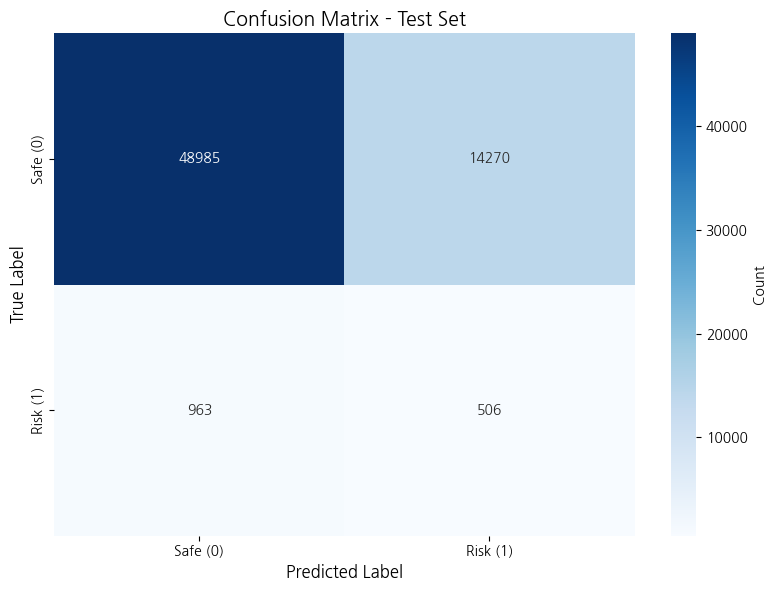

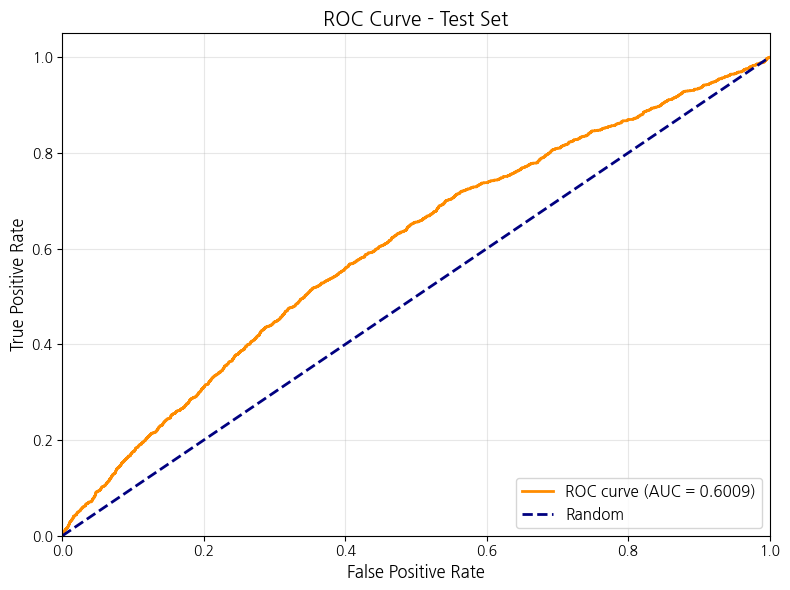

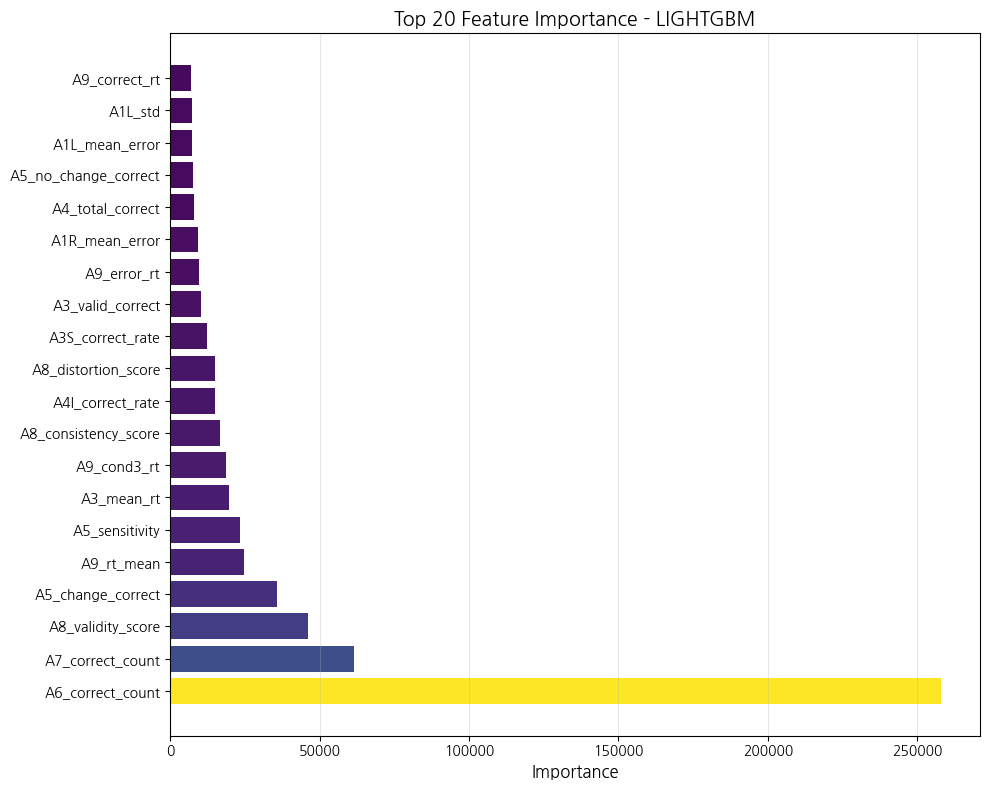

2025-11-11 22:13:39 [I] 
2025-11-11 22:13:39 [I] Training LIGHTGBM Model
2025-11-11 22:13:39 [I] ============================================================



Top 20 Feature Importance
A6_correct_count              :  258136.77
A7_correct_count              :   61595.63
A8_validity_score             :   46057.78
A5_change_correct             :   35810.52
A9_rt_mean                    :   24558.74
A5_sensitivity                :   23195.86
A3_mean_rt                    :   19478.27
A9_cond3_rt                   :   18560.94
A8_consistency_score          :   16549.07
A4I_correct_rate              :   15092.28
A8_distortion_score           :   15024.30
A3S_correct_rate              :   12187.28
A3_valid_correct              :   10306.12
A9_error_rt                   :    9613.98
A1R_mean_error                :    9256.65
A4_total_correct              :    7934.18
A5_no_change_correct          :    7503.35
A1L_mean_error                :    7322.76
A1L_std                       :    7153.61
A9_correct_rt                 :    6866.81

✓ Model saved to: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_model.pkl


2025-11-11 22:13:40 [I]   Train samples: 238010
2025-11-11 22:13:40 [I]   Val samples: 29751
2025-11-11 22:13:40 [I]   Features: 151
2025-11-11 22:13:40 [I]   Scale pos weight: 22.64
2025-11-11 22:13:40 [I] 
  Training LightGBM...
2025-11-11 22:13:42 [W] No model to save checkpoint
2025-11-11 22:13:42 [W] No model to save checkpoint
2025-11-11 22:13:42 [W] No model to save checkpoint
2025-11-11 22:13:43 [W] No model to save checkpoint


Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.695542	val's auc: 0.527511


2025-11-11 22:13:47 [I]   Best iteration: 3
2025-11-11 22:13:47 [I]   Best score: 0.5306
2025-11-11 22:13:47 [I] ✓ Checkpoint saved: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221347.pkl
2025-11-11 22:13:47 [I]   - Type: last
2025-11-11 22:13:47 [I]   - Iteration: 2
2025-11-11 22:13:47 [I]   - Score: 0.5306
2025-11-11 22:13:47 [I]   - Best Score: 0.5306
2025-11-11 22:13:47 [I] 
✓ Model training completed


Early stopping, best iteration is:
[3]	train's auc: 0.584721	val's auc: 0.53057


2025-11-11 22:13:47 [I]   Total training duration: 7.68s



Evaluating on Test Set

Prediction distribution: {0: 29752}
True label distribution: {0: 28493, 1: 1259}

Metrics:
  Accuracy:  0.9577
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  AUC:       0.5348

Confusion Matrix:
  TN: 28493  FP:     0
  FN:  1259  TP:     0

Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      1.00      0.98     28493
        Risk       0.00      0.00      0.00      1259

    accuracy                           0.96     29752
   macro avg       0.48      0.50      0.49     29752
weighted avg       0.92      0.96      0.94     29752



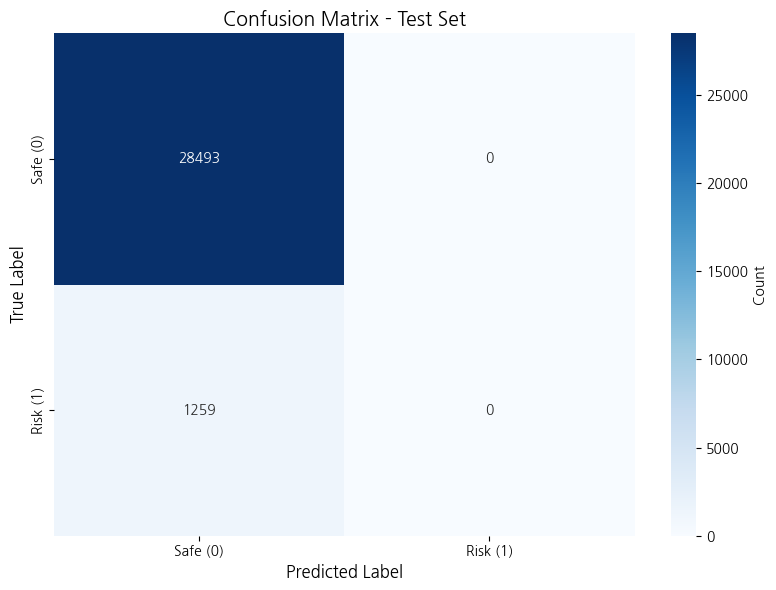

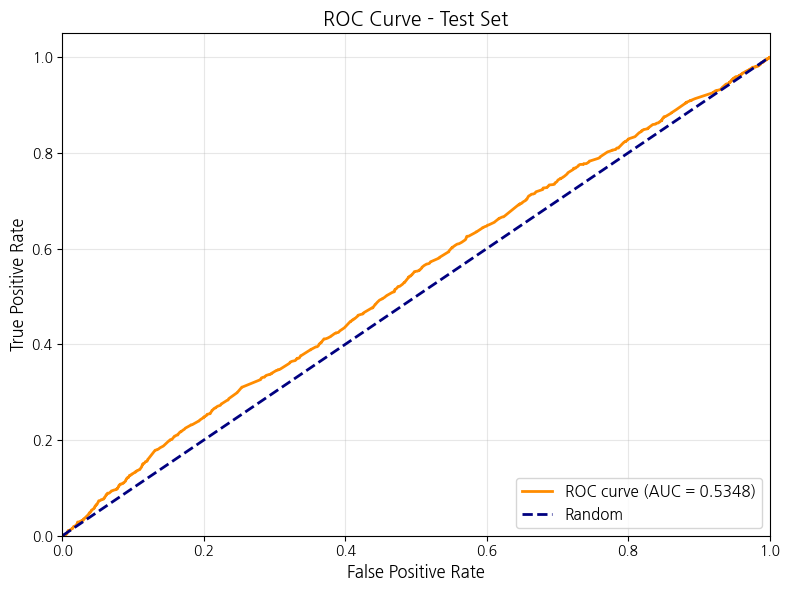

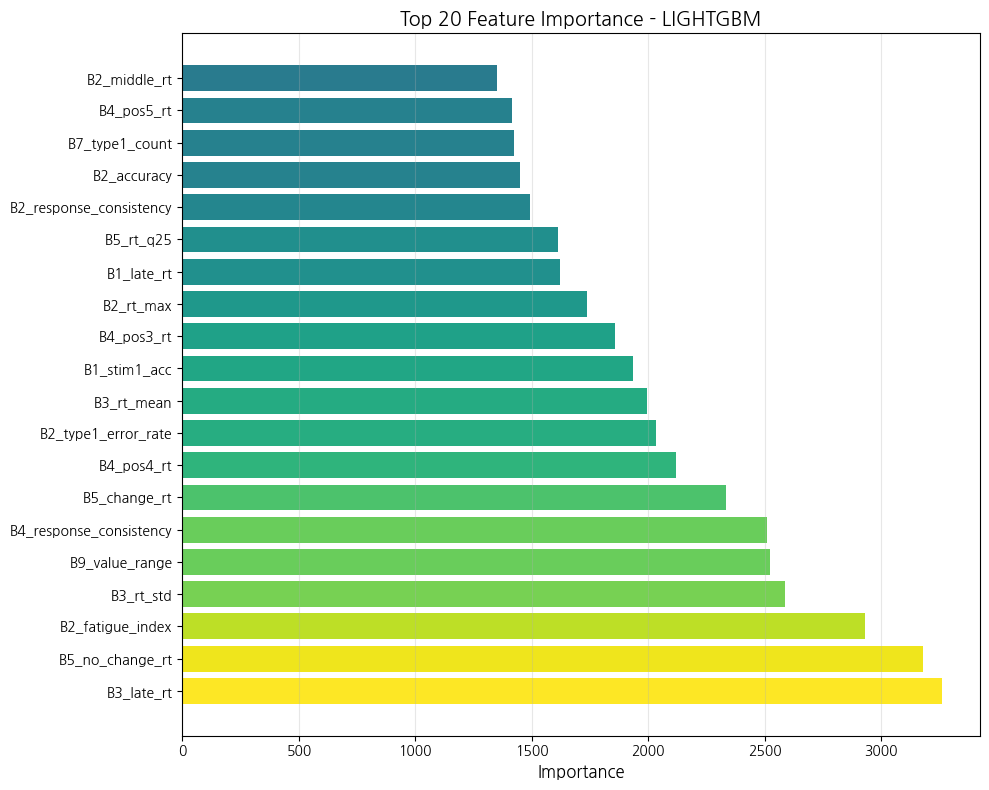


Top 20 Feature Importance
B3_late_rt                    :    3261.03
B5_no_change_rt               :    3180.21
B2_fatigue_index              :    2930.65
B3_rt_std                     :    2586.90
B9_value_range                :    2521.86
B4_response_consistency       :    2510.84
B5_change_rt                  :    2333.25
B4_pos4_rt                    :    2119.19
B2_type1_error_rate           :    2031.25
B3_rt_mean                    :    1996.30
B1_stim1_acc                  :    1936.08
B4_pos3_rt                    :    1858.61
B2_rt_max                     :    1739.18
B1_late_rt                    :    1620.31
B5_rt_q25                     :    1614.38
B2_response_consistency       :    1493.49
B2_accuracy                   :    1447.76
B7_type1_count                :    1424.53
B4_pos5_rt                    :    1417.07
B2_middle_rt                  :    1349.81

✓ Model saved to: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_model.pkl


In [15]:
"""
모델 학습 및 평가 파이프라인 (체크포인트 기능 추가)
Model Training and Evaluation Pipeline with Checkpoint Support
"""

# import numpy as np
# import pandas as pd
# import lightgbm as lgb
# import xgboost as xgb
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, confusion_matrix, classification_report,
#     roc_curve, precision_recall_curve
# )
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import joblib
# import json
# import time
# from typing import Dict, Tuple, Optional, Any
# from datetime import datetime
# import warnings
# warnings.filterwarnings('ignore')


class ModelTrainer:
    """모델 학습 및 평가 클래스"""

    def __init__(self, config, data_loader):
        """
        Args:
            config: ProjectConfig 인스턴스
            data_loader: DataLoader 인스턴스
        """
        self.config = config
        self.loader = data_loader
        self.model = None
        self.model_type = config.model.model_type
        self.feature_names = None
        self.results = {}
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_auc': [],
            'val_auc': [],
            'learning_rate': [],
            'epoch_duration': []
        }

        # 체크포인트 관련
        self.best_score = float('-inf')
        self.best_iteration = 0
        self.start_iteration = 0
        self.total_train_duration = 0

        self.model_dir = Path(config.data.output_dir) / "models"
        self.model_dir.mkdir(parents=True, exist_ok=True)

        self.plot_dir = Path(config.data.output_dir) / "plots"
        self.plot_dir.mkdir(parents=True, exist_ok=True)

    def _calculate_scale_pos_weight(self, y_train: np.ndarray) -> float:
        """클래스 불균형 가중치 계산"""
        n_neg = (y_train == 0).sum()
        n_pos = (y_train == 1).sum()
        return n_neg / n_pos if n_pos > 0 else 1.0

    def save_checkpoint(self,
                       checkpoint_type: str = 'last',
                       iteration: int = 0,
                       score: float = 0.0,
                       train_loss: float = 0.0,
                       val_loss: float = 0.0) -> str:
        """
        체크포인트 저장

        Args:
            checkpoint_type: 'best' 또는 'last'
            iteration: 현재 반복 횟수
            score: 현재 점수 (AUC 등)
            train_loss: 학습 손실
            val_loss: 검증 손실

        Returns:
            str: 저장된 체크포인트 경로
        """
        if self.model is None:
            logger.warning("No model to save checkpoint")
            return ""

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{self.model_type}_{checkpoint_type}_{timestamp}.pkl"
        filepath = self.model_dir / filename
        filepath_tmp = self.model_dir / f"{filename}.tmp"

        # 체크포인트 데이터
        checkpoint = {
            'model': self.model,
            'model_type': self.model_type,
            'iteration': iteration,
            'score': score,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_score': self.best_score,
            'best_iteration': self.best_iteration,
            'history': self.history,
            'feature_names': self.feature_names,
            'config': self.config,
            'total_train_duration': self.total_train_duration,
            'timestamp': timestamp
        }

        try:
            # 임시 파일로 저장
            joblib.dump(checkpoint, filepath_tmp)

            # 원자적 이동
            if filepath.exists():
                filepath.unlink()
            filepath_tmp.rename(filepath)

            logger.info(f"✓ Checkpoint saved: {filepath}")
            logger.info(f"  - Type: {checkpoint_type}")
            logger.info(f"  - Iteration: {iteration}")
            logger.info(f"  - Score: {score:.4f}")
            logger.info(f"  - Best Score: {self.best_score:.4f}")

            # last 체크포인트 심볼릭 링크 업데이트
            if checkpoint_type == 'last':
                last_link = self.model_dir / f"{self.model_type}_last.pkl"
                if last_link.exists() or last_link.is_symlink():
                    last_link.unlink()
                # Windows에서는 복사로 대체
                import shutil
                shutil.copy2(filepath, last_link)

            return str(filepath)

        except Exception as e:
            logger.error(f"✗ Failed to save checkpoint: {e}")
            if filepath_tmp.exists():
                filepath_tmp.unlink()
            raise

    def load_checkpoint(self,
                       checkpoint_path: Optional[str] = None,
                       load_last: bool = False) -> Dict:
        """
        체크포인트 로드

        Args:
            checkpoint_path: 체크포인트 파일 경로 (None이면 load_last 사용)
            load_last: True이면 마지막 체크포인트 로드

        Returns:
            Dict: 체크포인트 데이터
        """
        if checkpoint_path is None and load_last:
            checkpoint_path = self.model_dir / f"{self.model_type}_last.pkl"

        if checkpoint_path is None:
            logger.warning("No checkpoint path specified")
            return {}

        checkpoint_path = Path(checkpoint_path)
        if not checkpoint_path.exists():
            logger.warning(f"Checkpoint not found: {checkpoint_path}")
            return {}

        try:
            logger.info(f"\nLoading checkpoint from: {checkpoint_path}")
            checkpoint = joblib.load(checkpoint_path)

            # 체크포인트 데이터 복원
            self.model = checkpoint['model']
            self.model_type = checkpoint['model_type']
            self.best_score = checkpoint['best_score']
            self.best_iteration = checkpoint['best_iteration']
            self.start_iteration = checkpoint['iteration']
            self.history = checkpoint['history']
            self.feature_names = checkpoint['feature_names']
            self.total_train_duration = checkpoint.get('total_train_duration', 0)

            logger.info(f"✓ Checkpoint loaded successfully")
            logger.info(f"  - Model type: {self.model_type}")
            logger.info(f"  - Start iteration: {self.start_iteration}")
            logger.info(f"  - Best score: {self.best_score:.4f}")
            logger.info(f"  - Best iteration: {self.best_iteration}")
            logger.info(f"  - Total train duration: {self.total_train_duration:.2f}s")

            return checkpoint

        except Exception as e:
            logger.error(f"✗ Failed to load checkpoint: {e}")
            raise

    def train(self,
              X_train: Optional[np.ndarray] = None,
              y_train: Optional[np.ndarray] = None,
              X_val: Optional[np.ndarray] = None,
              y_val: Optional[np.ndarray] = None,
              resume_from_checkpoint: Optional[str] = None,
              resume_last: bool = False):
        """
        모델 학습 (체크포인트 지원)

        Args:
            X_train, y_train: 학습 데이터
            X_val, y_val: 검증 데이터
            resume_from_checkpoint: 재개할 체크포인트 경로
            resume_last: True이면 마지막 체크포인트부터 재개
        """
        train_start_time = time.time()

        # 체크포인트 로드
        if resume_from_checkpoint or resume_last:
            checkpoint = self.load_checkpoint(resume_from_checkpoint, resume_last)
            if checkpoint:
                logger.info(f"\n▶ Resuming training from iteration {self.start_iteration}")

        logger.info("\n" + "="*60)
        logger.info(f"Training {self.model_type.upper()} Model")
        logger.info("="*60)

        # 데이터 준비
        if X_train is None or y_train is None:
            X_train, y_train = self.loader.get_X_y(self.loader.train_data)
            X_val, y_val = self.loader.get_X_y(self.loader.val_data)

        if self.feature_names is None:
            self.feature_names = self.loader.get_feature_names()

        logger.info(f"  Train samples: {len(X_train)}")
        logger.info(f"  Val samples: {len(X_val)}")
        logger.info(f"  Features: {len(self.feature_names)}")

        # 클래스 불균형 처리
        if self.config.training.handle_imbalance:
            scale_pos_weight = self._calculate_scale_pos_weight(y_train)
            logger.info(f"  Scale pos weight: {scale_pos_weight:.2f}")
        else:
            scale_pos_weight = 1.0

        # 모델 학습
        if self.model is None:  # 새로 학습 시작
            if self.model_type == "lightgbm":
                self.model = self._train_lightgbm(X_train, y_train, X_val, y_val, scale_pos_weight)
            elif self.model_type == "xgboost":
                self.model = self._train_xgboost(X_train, y_train, X_val, y_val, scale_pos_weight)
            elif self.model_type == "random_forest":
                self.model = self._train_random_forest(X_train, y_train, scale_pos_weight)
            elif self.model_type == "logistic":
                self.model = self._train_logistic(X_train, y_train)
            else:
                raise ValueError(f"Unknown model type: {self.model_type}")
        else:  # 체크포인트에서 재개
            logger.info("\n▶ Continuing training from loaded checkpoint...")
            # LightGBM/XGBoost는 init_model 파라미터로 재개 가능
            # 여기서는 간단히 재학습으로 처리 (실제로는 더 복잡한 로직 필요)
            logger.warning("  Note: Full retraining from checkpoint (incremental training not fully implemented)")

        # 학습 시간 기록
        self.total_train_duration += time.time() - train_start_time

        # 최종 체크포인트 저장
        self.save_checkpoint(
            checkpoint_type='last',
            iteration=self.best_iteration,
            score=self.best_score,
            train_loss=self.history['train_loss'][-1] if self.history['train_loss'] else 0.0,
            val_loss=self.history['val_loss'][-1] if self.history['val_loss'] else 0.0
        )

        logger.info("\n✓ Model training completed")
        logger.info(f"  Total training duration: {self.total_train_duration:.2f}s")

        return self.model

    def _train_lightgbm(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """LightGBM 모델 학습 (체크포인트 지원)"""
        logger.info("\n  Training LightGBM...")

        params = self.config.model.lgb_params.copy()
        if self.config.training.handle_imbalance:
            params['scale_pos_weight'] = scale_pos_weight

        train_data = lgb.Dataset(X_train, label=y_train, feature_name=self.feature_names)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, feature_name=self.feature_names)

        # 커스텀 콜백으로 체크포인트 저장
        def checkpoint_callback(env):
            iteration = env.iteration
            if iteration % 100 == 0:  # 100 iteration마다 저장
                score = env.evaluation_result_list[1][2]  # val auc
                self.save_checkpoint(
                    checkpoint_type='last',
                    iteration=iteration,
                    score=score
                )

            # Best 모델 저장
            if len(env.evaluation_result_list) > 1:
                score = env.evaluation_result_list[1][2]
                if score > self.best_score:
                    self.best_score = score
                    self.best_iteration = iteration
                    self.save_checkpoint(
                        checkpoint_type='best',
                        iteration=iteration,
                        score=score
                    )

        evals_result = {}
        model = lgb.train(
            params,
            train_data,
            num_boost_round=self.config.training.num_boost_round,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'val'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=self.config.training.early_stopping_rounds),
                lgb.log_evaluation(period=self.config.training.verbose_eval),
                lgb.record_evaluation(evals_result),
                checkpoint_callback
            ]
        )

        self.results['train_history'] = evals_result
        self.results['best_iteration'] = model.best_iteration

        logger.info(f"  Best iteration: {model.best_iteration}")
        logger.info(f"  Best score: {model.best_score['val']['auc']:.4f}")

        return model

    def _train_xgboost(self, X_train, y_train, X_val, y_val, scale_pos_weight):
        """XGBoost 모델 학습"""
        logger.info("\n  Training XGBoost...")

        params = self.config.model.xgb_params.copy()
        if self.config.training.handle_imbalance:
            params['scale_pos_weight'] = scale_pos_weight

        dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=self.feature_names)
        dval = xgb.DMatrix(X_val, label=y_val, feature_names=self.feature_names)

        evals_result = {}
        model = xgb.train(
            params,
            dtrain,
            num_boost_round=self.config.training.num_boost_round,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=self.config.training.early_stopping_rounds,
            verbose_eval=self.config.training.verbose_eval,
            evals_result=evals_result
        )

        self.results['train_history'] = evals_result
        self.results['best_iteration'] = model.best_iteration

        logger.info(f"  Best iteration: {model.best_iteration}")

        return model

    def _train_random_forest(self, X_train, y_train, scale_pos_weight):
        """Random Forest 모델 학습"""
        logger.info("\n  Training Random Forest...")

        params = self.config.model.rf_params.copy()
        if self.config.training.handle_imbalance:
            params['class_weight'] = {0: 1.0, 1: scale_pos_weight}

        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)

        return model

    def _train_logistic(self, X_train, y_train):
        """Logistic Regression 모델 학습"""
        logger.info("\n  Training Logistic Regression...")

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        return model

    def evaluate(self,
                X_test: Optional[np.ndarray] = None,
                y_test: Optional[np.ndarray] = None,
                dataset_name: str = "Test") -> Dict:
        """모델 평가"""
        if self.model is None:
            raise ValueError("No trained model found. Please train a model first.")

        # 데이터 준비
        if X_test is None or y_test is None:
            X_test, y_test = self.loader.get_X_y(self.loader.test_data)

        print("\n" + "="*60)
        print(f"Evaluating on {dataset_name} Set")
        print("="*60)

        # 예측
        if self.model_type == "lightgbm":
            y_pred_proba = self.model.predict(X_test, num_iteration=self.model.best_iteration)
        elif self.model_type == "xgboost":
            dtest = xgb.DMatrix(X_test, feature_names=self.feature_names)
            y_pred_proba = self.model.predict(dtest, iteration_range=(0, self.model.best_iteration))
        else:
            y_pred_proba = self.model.predict_proba(X_test)[:, 1]

        y_pred = (y_pred_proba >= 0.5).astype(int)

        # 예측 분포 확인 (디버깅)
        unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
        unique_true, counts_true = np.unique(y_test, return_counts=True)
        print(f"\nPrediction distribution: {dict(zip(unique_pred, counts_pred))}")
        print(f"True label distribution: {dict(zip(unique_true, counts_true))}")

        # Confusion Matrix (labels 명시)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        # 메트릭 계산 (zero_division 처리)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'auc': roc_auc_score(y_test, y_pred_proba) if len(unique_true) > 1 else 0.0
        }

        # 결과 출력
        print(f"\nMetrics:")
        print(f"  Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-Score:  {metrics['f1']:.4f}")
        print(f"  AUC:       {metrics['auc']:.4f}")

        print(f"\nConfusion Matrix:")
        print(f"  TN: {cm[0, 0]:5d}  FP: {cm[0, 1]:5d}")
        print(f"  FN: {cm[1, 0]:5d}  TP: {cm[1, 1]:5d}")

        # 분류 리포트
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Safe', 'Risk'], zero_division=0))

        # 결과 저장
        eval_results = {
            'metrics': metrics,
            'confusion_matrix': cm,
            'y_true': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

        self.results[f'{dataset_name.lower()}_results'] = eval_results

        return eval_results

    def plot_confusion_matrix(self, dataset_name: str = "test"):
        """Confusion Matrix 시각화"""
        results_key = f'{dataset_name}_results'
        if results_key not in self.results:
            print(f"No results found for {dataset_name} set")
            return

        cm = self.results[results_key]['confusion_matrix']

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Safe (0)', 'Risk (1)'],
                   yticklabels=['Safe (0)', 'Risk (1)'],
                   cbar_kws={'label': 'Count'},
                   ax=ax)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {dataset_name.capitalize()} Set',
                    fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig(self.plot_dir / f'confusion_matrix_{dataset_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    def plot_roc_curve(self, dataset_name: str = "test"):
        """ROC Curve 시각화"""
        results_key = f'{dataset_name}_results'
        if results_key not in self.results:
            print(f"No results found for {dataset_name} set")
            return

        y_true = self.results[results_key]['y_true']
        y_pred_proba = self.results[results_key]['y_pred_proba']

        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
        auc_score = self.results[results_key]['metrics']['auc']

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(fpr, tpr, color='darkorange', lw=2,
               label=f'ROC curve (AUC = {auc_score:.4f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'ROC Curve - {dataset_name.capitalize()} Set',
                    fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=11)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(self.plot_dir / f'roc_curve_{dataset_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    def plot_feature_importance(self, top_n: int = 20):
        """피처 중요도 시각화"""
        if self.model is None:
            print("No trained model found")
            return

        # 피처 중요도 추출
        if self.model_type == "lightgbm":
            importance = self.model.feature_importance(importance_type='gain')
        elif self.model_type == "xgboost":
            importance = self.model.get_score(importance_type='gain')
            importance = np.array([importance.get(f, 0) for f in self.feature_names])
        elif self.model_type == "random_forest":
            importance = self.model.feature_importances_
        else:
            print(f"Feature importance not supported for {self.model_type}")
            return

        # 데이터프레임 생성
        feature_importance_df = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False).head(top_n)

        # 시각화
        fig, ax = plt.subplots(figsize=(10, 8))
        colors = plt.cm.viridis(feature_importance_df['importance'].values /
                               feature_importance_df['importance'].values.max())
        ax.barh(range(len(feature_importance_df)),
               feature_importance_df['importance'].values,
               color=colors)
        ax.set_yticks(range(len(feature_importance_df)))
        ax.set_yticklabels(feature_importance_df['feature'].values, fontsize=10)
        ax.set_xlabel('Importance', fontsize=12)
        ax.set_title(f'Top {top_n} Feature Importance - {self.model_type.upper()}',
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.savefig(self.plot_dir / 'feature_importance.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        # 중요도 출력
        print("\n" + "="*60)
        print(f"Top {top_n} Feature Importance")
        print("="*60)
        for i, row in feature_importance_df.iterrows():
            print(f"{row['feature']:30s}: {row['importance']:10.2f}")
        print("="*60)

        return feature_importance_df

    def save_model(self, filename: Optional[str] = None):
        """모델 저장"""
        if self.model is None:
            print("No model to save")
            return

        if filename is None:
            filename = f"{self.model_type}_model.pkl"

        filepath = self.model_dir / filename
        joblib.dump(self.model, filepath)
        print(f"\n✓ Model saved to: {filepath}")

    def load_model(self, filename: str):
        """모델 로드"""
        filepath = self.model_dir / filename
        self.model = joblib.load(filepath)
        print(f"✓ Model loaded from: {filepath}")
        return self.model


def test_train(loader: Optional[DataLoader] = None):
    # 테스트 코드
    # 데이터 로드
    # config = ProjectConfig()

    # loader = DataLoader(config)
    # loader.load_json_data()
    # loader.preprocess_data()
    # loader.split_data()

    # 트레이너 생성
    trainer = ModelTrainer(loader.config, loader)

    # 학습
    trainer.train()

    # 평가
    trainer.evaluate(dataset_name="Test")

    # 시각화
    trainer.plot_confusion_matrix()
    trainer.plot_roc_curve()
    trainer.plot_feature_importance()

    # 모델 저장
    trainer.save_model()

    return trainer


trainerA = test_train(loaderA)
trainerB = test_train(loaderB)

# 1단계: 도메인 가중치 설정 추가

DataConfig에 검사 그룹별 도메인 가중치를 추가합니다.

In [16]:
"""
DataConfig에 도메인 가중치 필드 추가
운전 안전 관점에서 검사 그룹별 중요도를 반영
"""

# DataConfig 클래스에 추가할 필드 (기존 #VSC-60390d44 셀 수정 필요)
# 아래는 추가될 내용의 예시입니다.

# @dataclass
# class DataConfig:
#     ... 기존 필드들 ...
#     
#     # 도메인 가중치 사용 여부
#     use_domain_weights: bool = False
#     use_only_weighted_features: bool = False  # True면 가중치 피처만 사용
#     
#     # A검사 그룹별 도메인 가중치 (총합 1.0)
#     domain_weights_A: Dict[str, float] = field(default_factory=lambda: {
#         "A1": 0.15,  # 좌우 방향 판단 (핵심)
#         "A2": 0.15,  # 속도 조절 (핵심)
#         "A3": 0.15,  # 시야 범위 (핵심)
#         "A4": 0.10,  # Stroop 효과 (중요)
#         "A5": 0.10,  # 변화 탐지 (중요)
#         "A6": 0.08,  # 정확도 평가 (보통)
#         "A7": 0.08,  # 정확도 평가2 (보통)
#         "A8": 0.05,  # 왜곡도/일관성 (낮음)
#         "A9": 0.14   # 반응시간 상세 (중요)
#     })
#     
#     # B검사 그룹별 도메인 가중치 (총합 1.0)
#     domain_weights_B: Dict[str, float] = field(default_factory=lambda: {
#         "B1": 0.15,  # 기본 반응시간
#         "B2": 0.15,  # 복합 반응시간
#         "B3": 0.10,  # 지속 반응시간
#         "B4": 0.15,  # 일치/불일치 판단
#         "B5": 0.15,  # 변화 탐지 능력
#         "B6": 0.05,  # 샘플 통계
#         "B7": 0.10,  # 유형 전환
#         "B8": 0.08,  # 정확도 지표
#         "B9": 0.07   # 반응 패턴
#     })
#     
#     def get_domain_weights(self) -> Dict[str, float]:
#         """현재 검사 타입의 도메인 가중치 반환"""
#         return self.domain_weights_B if self.test_type == "B" else self.domain_weights_A
#     
#     def print_domain_weights(self):
#         """도메인 가중치 출력"""
#         weights = self.get_domain_weights()
#         
#         logger.info(f"\n{'='*70}")
#         logger.info(f"{self.test_type}검사 그룹별 도메인 가중치")
#         logger.info(f"{'='*70}")
#         
#         for group, weight in weights.items():
#             logger.info(f"  {group}: {weight:.2f} ({weight*100:.1f}%)")
#         
#         logger.info(f"\n총합: {sum(weights.values()):.2f}")
#         logger.info(f"{'='*70}\n")

logger.info("✓ 도메인 가중치 설정 준비 완료")
logger.info("  다음 단계: #VSC-60390d44 셀의 DataConfig 클래스 수정")

2025-11-11 22:13:50 [I] ✓ 도메인 가중치 설정 준비 완료
2025-11-11 22:13:50 [I]   다음 단계: #VSC-60390d44 셀의 DataConfig 클래스 수정


# 2단계: DataLoader에 가중치 적용 메서드 추가

DataLoader 클래스에 `apply_domain_weights()` 메서드를 추가합니다.

# 3단계: 도메인 가중치 적용 학습 실행

기존 학습 파이프라인에 도메인 가중치를 적용합니다.

2025-11-11 22:13:50 [I] 
2025-11-11 22:13:50 [I] A검사 그룹별 도메인 가중치
2025-11-11 22:13:50 [I] ======================================================================
2025-11-11 22:13:50 [I]   A1: 0.15 (15.0%)
2025-11-11 22:13:50 [I]   A2: 0.15 (15.0%)
2025-11-11 22:13:50 [I]   A3: 0.15 (15.0%)
2025-11-11 22:13:50 [I]   A4: 0.10 (10.0%)
2025-11-11 22:13:50 [I]   A5: 0.10 (10.0%)
2025-11-11 22:13:50 [I]   A6: 0.08 (8.0%)
2025-11-11 22:13:50 [I]   A7: 0.08 (8.0%)
2025-11-11 22:13:50 [I]   A8: 0.05 (5.0%)
2025-11-11 22:13:50 [I]   A9: 0.14 (14.0%)
2025-11-11 22:13:50 [I] 
총합: 1.00
2025-11-11 22:13:50 [I] ======================================================================

2025-11-11 22:13:50 [D] Loading A test data from: d:\temp\open_v2_clean.zip.unzip\train_A_.jsonl
2025-11-11 22:15:02 [D] ✓ Data loaded successfully: (647237, 96)
2025-11-11 22:15:02 [D] 
Preprocessing data...
2025-11-11 22:15:02 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-11 22:15:02 [D

Training until validation scores don't improve for 50 rounds


2025-11-11 22:15:10 [W] No model to save checkpoint
2025-11-11 22:15:10 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:11 [W] No model to save checkpoint
2025-11-11 22:15:12 [W] No model to save checkpoint
2025-11-11 22:15:12 [W] No model to save checkpoint
2025-11-11 22:15:12 [W] No model to save checkpoint
2025-11-11 22:15:12 [W] No model to save checkpoint
2025-11-11 22:15:13 [W] No model to save checkpoint
2025-11-11 22:15:13 [W] No model to save checkpoint
2025-11-11 22:15:13 [W] No model to save checkpoint
2025-11-11 22:15:13 [W] No model to save checkpoint
2025-11-11 22:15:13 [W] No model to save checkpoint
2025-11-11 22:15:14 [W] No model to save checkpoint
2025-11-11 22:15:14 [W] No model to save checkpoint
2025-11-11 2

[50]	train's auc: 0.659923	val's auc: 0.612248


2025-11-11 22:15:25 [I]   Best iteration: 40
2025-11-11 22:15:25 [I]   Best score: 0.6132
2025-11-11 22:15:25 [I] ✓ Checkpoint saved: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221525.pkl
2025-11-11 22:15:25 [I]   - Type: last
2025-11-11 22:15:25 [I]   - Iteration: 39
2025-11-11 22:15:25 [I]   - Score: 0.6132


Early stopping, best iteration is:
[40]	train's auc: 0.655349	val's auc: 0.613221


2025-11-11 22:15:25 [I]   - Best Score: 0.6132
2025-11-11 22:15:25 [I] 
✓ Model training completed
2025-11-11 22:15:25 [I]   Total training duration: 17.29s



Evaluating on Test Set

Prediction distribution: {0: 49948, 1: 14776}
True label distribution: {0: 63255, 1: 1469}

Metrics:
  Accuracy:  0.7646
  Precision: 0.0342
  Recall:    0.3445
  F1-Score:  0.0623
  AUC:       0.6009

Confusion Matrix:
  TN: 48985  FP: 14270
  FN:   963  TP:   506

Classification Report:
              precision    recall  f1-score   support

        Safe       0.98      0.77      0.87     63255
        Risk       0.03      0.34      0.06      1469

    accuracy                           0.76     64724
   macro avg       0.51      0.56      0.46     64724
weighted avg       0.96      0.76      0.85     64724



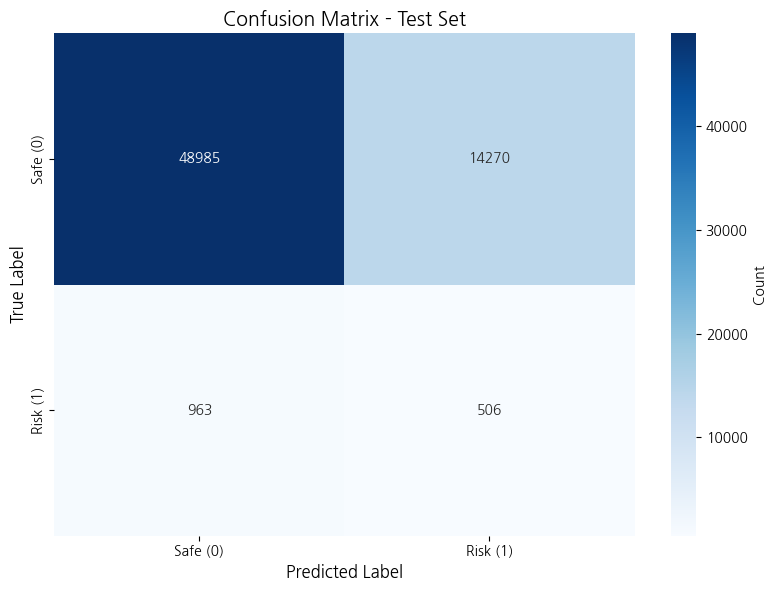

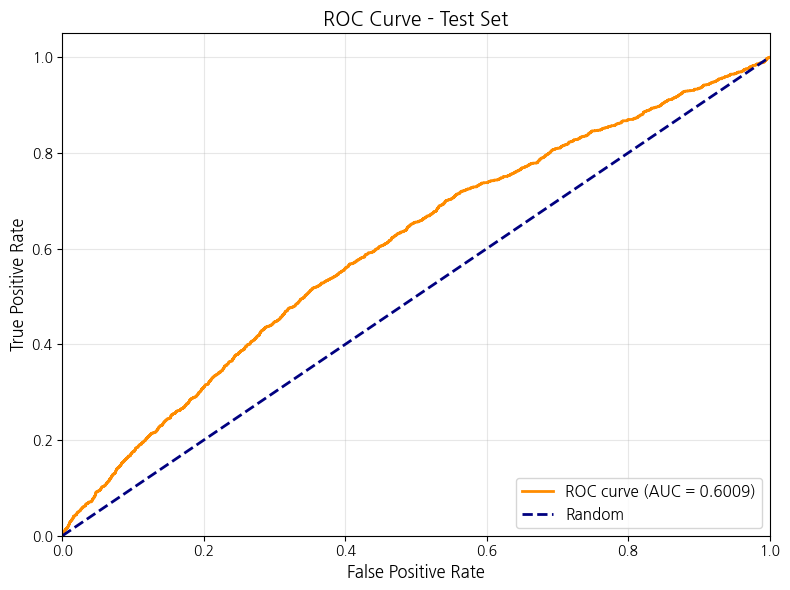

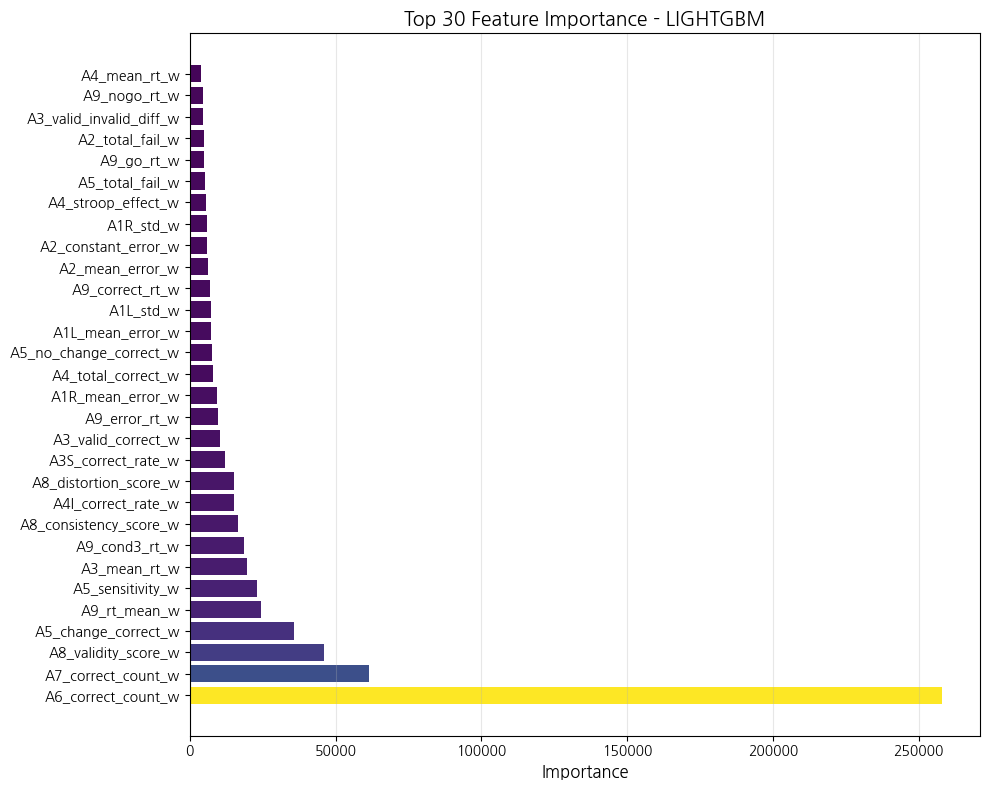


Top 30 Feature Importance
A6_correct_count_w            :  258136.77
A7_correct_count_w            :   61595.63
A8_validity_score_w           :   46057.78
A5_change_correct_w           :   35810.52
A9_rt_mean_w                  :   24558.74
A5_sensitivity_w              :   23195.86
A3_mean_rt_w                  :   19478.27
A9_cond3_rt_w                 :   18560.94
A8_consistency_score_w        :   16549.07
A4I_correct_rate_w            :   15092.28
A8_distortion_score_w         :   15024.30
A3S_correct_rate_w            :   12187.28
A3_valid_correct_w            :   10306.12
A9_error_rt_w                 :    9613.98
A1R_mean_error_w              :    9256.65
A4_total_correct_w            :    7934.18
A5_no_change_correct_w        :    7503.35
A1L_mean_error_w              :    7322.76
A1L_std_w                     :    7153.61
A9_correct_rt_w               :    6866.81
A2_mean_error_w               :    6238.77
A2_constant_error_w           :    5880.74
A1R_std_w                  

,feature,importance
46,A6_correct_count_w,258136.772644
50,A7_correct_count_w,61595.632019
61,A8_validity_score_w,46057.775436
43,A5_change_correct_w,35810.515823
63,A9_rt_mean_w,24558.741898
44,A5_sensitivity_w,23195.864944
31,A3_mean_rt_w,19478.270378
81,A9_cond3_rt_w,18560.944901
56,A8_consistency_score_w,16549.071014
35,A4I_correct_rate_w,15092.281921


In [17]:
"""
도메인 가중치 적용 학습 (A검사)
가중치 피처만 사용하여 학습
"""

# Config 설정
configA_weighted = ProjectConfig()
configA_weighted.data.test_type = "A"
configA_weighted.data.use_domain_weights = True
configA_weighted.data.use_only_weighted_features = True  # 가중치 피처만 사용

# 가중치 확인
configA_weighted.data.print_domain_weights()

# 데이터 로드
loaderA_weighted = DataLoader(configA_weighted)
loaderA_weighted.load_json_data()
loaderA_weighted.preprocess_data()

# 도메인 가중치 적용
loaderA_weighted.data = loaderA_weighted.apply_domain_weights()

# 데이터 분할
loaderA_weighted.split_data()

# 학습
trainerA_weighted = ModelTrainer(configA_weighted, loaderA_weighted)
trainerA_weighted.train()

# 평가
eval_results_weighted = trainerA_weighted.evaluate(dataset_name="Test")

# 시각화
trainerA_weighted.plot_confusion_matrix()
trainerA_weighted.plot_roc_curve()
trainerA_weighted.plot_feature_importance(top_n=30)

2025-11-11 22:15:34 [I] 
2025-11-11 22:15:34 [I] B검사 그룹별 도메인 가중치
2025-11-11 22:15:34 [I] ======================================================================
2025-11-11 22:15:34 [I]   B1: 0.15 (15.0%)
2025-11-11 22:15:34 [I]   B2: 0.15 (15.0%)
2025-11-11 22:15:34 [I]   B3: 0.10 (10.0%)
2025-11-11 22:15:34 [I]   B4: 0.15 (15.0%)
2025-11-11 22:15:34 [I]   B5: 0.15 (15.0%)
2025-11-11 22:15:34 [I]   B6: 0.05 (5.0%)
2025-11-11 22:15:34 [I]   B7: 0.10 (10.0%)
2025-11-11 22:15:34 [I]   B8: 0.08 (8.0%)
2025-11-11 22:15:34 [I]   B9: 0.07 (7.0%)
2025-11-11 22:15:34 [I] 
총합: 1.00
2025-11-11 22:15:34 [I] ======================================================================

2025-11-11 22:15:34 [D] Loading B test data from: d:\temp\open_v2_clean.zip.unzip\train_B_.jsonl
2025-11-11 22:16:08 [D] ✓ Data loaded successfully: (297513, 156)
2025-11-11 22:16:09 [D] 
Preprocessing data...
2025-11-11 22:16:09 [D]   - Dropped columns: ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
2025-11-11 22:16:09 [

Training until validation scores don't improve for 50 rounds


2025-11-11 22:16:14 [W] No model to save checkpoint


[50]	train's auc: 0.695542	val's auc: 0.527511


2025-11-11 22:16:18 [I]   Best iteration: 3
2025-11-11 22:16:18 [I]   Best score: 0.5306
2025-11-11 22:16:19 [I] ✓ Checkpoint saved: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221618.pkl
2025-11-11 22:16:19 [I]   - Type: last
2025-11-11 22:16:19 [I]   - Iteration: 2
2025-11-11 22:16:19 [I]   - Score: 0.5306
2025-11-11 22:16:19 [I]   - Best Score: 0.5306
2025-11-11 22:16:19 [I] 
✓ Model training completed


Early stopping, best iteration is:
[3]	train's auc: 0.584721	val's auc: 0.53057


2025-11-11 22:16:19 [I]   Total training duration: 7.44s



Evaluating on Test Set

Prediction distribution: {0: 29752}
True label distribution: {0: 28493, 1: 1259}

Metrics:
  Accuracy:  0.9577
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  AUC:       0.5348

Confusion Matrix:
  TN: 28493  FP:     0
  FN:  1259  TP:     0

Classification Report:
              precision    recall  f1-score   support

        Safe       0.96      1.00      0.98     28493
        Risk       0.00      0.00      0.00      1259

    accuracy                           0.96     29752
   macro avg       0.48      0.50      0.49     29752
weighted avg       0.92      0.96      0.94     29752



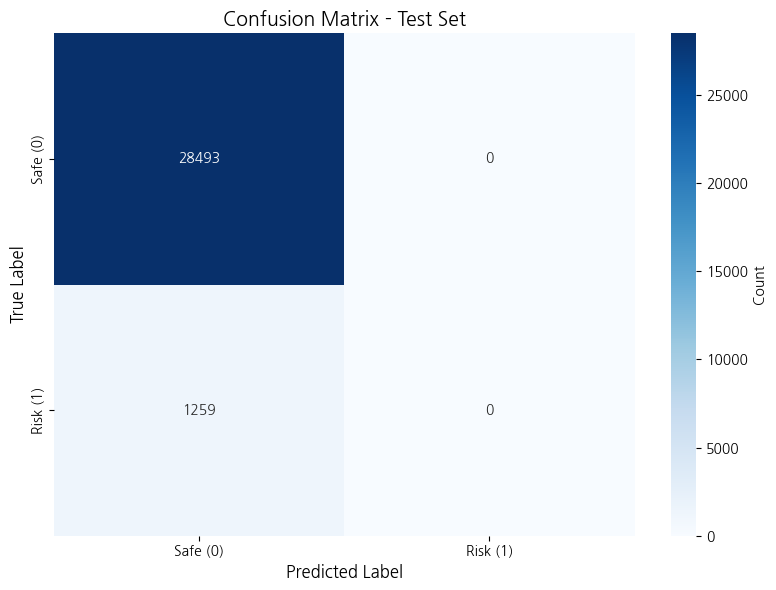

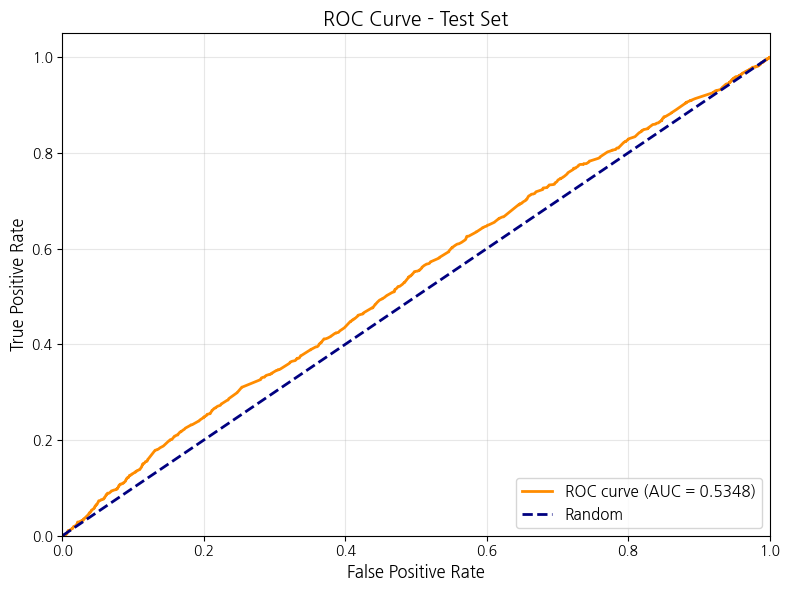

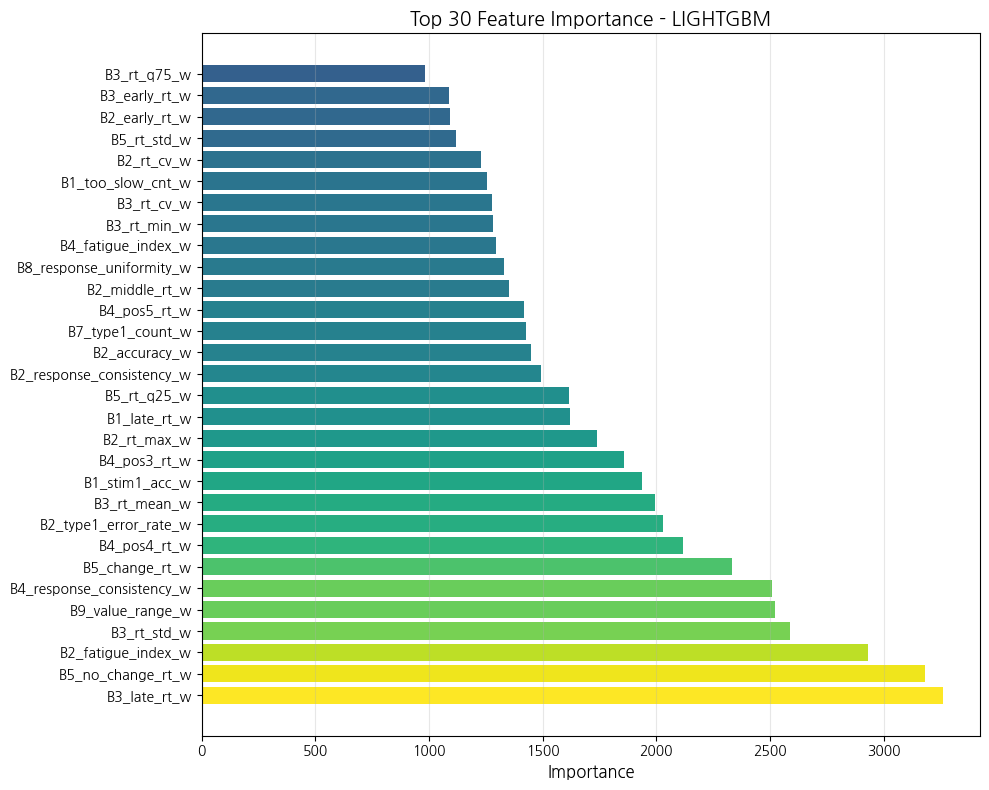


Top 30 Feature Importance
B3_late_rt_w                  :    3261.03
B5_no_change_rt_w             :    3180.21
B2_fatigue_index_w            :    2930.65
B3_rt_std_w                   :    2586.90
B9_value_range_w              :    2521.86
B4_response_consistency_w     :    2510.84
B5_change_rt_w                :    2333.25
B4_pos4_rt_w                  :    2119.19
B2_type1_error_rate_w         :    2031.25
B3_rt_mean_w                  :    1996.30
B1_stim1_acc_w                :    1936.08
B4_pos3_rt_w                  :    1858.61
B2_rt_max_w                   :    1739.18
B1_late_rt_w                  :    1620.31
B5_rt_q25_w                   :    1614.38
B2_response_consistency_w     :    1493.49
B2_accuracy_w                 :    1447.76
B7_type1_count_w              :    1424.53
B4_pos5_rt_w                  :    1417.07
B2_middle_rt_w                :    1349.81
B8_response_uniformity_w      :    1328.87
B4_fatigue_index_w            :    1295.66
B3_rt_min_w                

,feature,importance
67,B3_late_rt_w,3261.025055
118,B5_no_change_rt_w,3180.214905
41,B2_fatigue_index_w,2930.652039
52,B3_rt_std_w,2586.897003
150,B9_value_range_w,2521.860107
103,B4_response_consistency_w,2510.837067
119,B5_change_rt_w,2333.250916
90,B4_pos4_rt_w,2119.192017
46,B2_type1_error_rate_w,2031.250000
51,B3_rt_mean_w,1996.304993


In [18]:
"""
도메인 가중치 적용 학습 (B검사)
가중치 피처만 사용하여 학습
"""

# Config 설정
configB_weighted = ProjectConfig()
configB_weighted.data.test_type = "B"
configB_weighted.data.use_domain_weights = True
configB_weighted.data.use_only_weighted_features = True  # 가중치 피처만 사용

# 가중치 확인
configB_weighted.data.print_domain_weights()

# 데이터 로드
loaderB_weighted = DataLoader(configB_weighted)
loaderB_weighted.load_json_data()
loaderB_weighted.preprocess_data()

# 도메인 가중치 적용
loaderB_weighted.data = loaderB_weighted.apply_domain_weights()

# 데이터 분할
loaderB_weighted.split_data()

# 학습
trainerB_weighted = ModelTrainer(configB_weighted, loaderB_weighted)
trainerB_weighted.train()

# 평가
eval_results_weighted = trainerB_weighted.evaluate(dataset_name="Test")

# 시각화
trainerB_weighted.plot_confusion_matrix()
trainerB_weighted.plot_roc_curve()
trainerB_weighted.plot_feature_importance(top_n=30)

## 도메인 가중치 비교 분석

원본 모델 vs 가중치 적용 모델 성능 비교

In [19]:
"""
모델 성능 비교
Original vs Domain-Weighted
"""

def compare_models(original_results, weighted_results, test_type="A"):
    """
    원본 모델과 가중치 적용 모델 비교
    
    Args:
        original_results: 원본 모델 평가 결과
        weighted_results: 가중치 모델 평가 결과
        test_type: 검사 타입
    """
    logger.info(f"\n{'='*70}")
    logger.info(f"{test_type}검사 모델 비교: Original vs Domain-Weighted")
    logger.info(f"{'='*70}")
    
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    
    comparison_df = pd.DataFrame({
        'Metric': metrics,
        'Original': [original_results.get(m, 0) for m in metrics],
        'Weighted': [weighted_results.get(m, 0) for m in metrics],
    })
    
    comparison_df['Improvement'] = comparison_df['Weighted'] - comparison_df['Original']
    comparison_df['Improvement_Pct'] = (comparison_df['Improvement'] / comparison_df['Original'] * 100).round(2)
    
    logger.info(f"\n{comparison_df.to_string(index=False)}")
    
    # 개선 요약
    logger.info(f"\n{'='*70}")
    logger.info("개선 요약")
    logger.info(f"{'='*70}")
    
    for metric in metrics:
        orig = comparison_df[comparison_df['Metric'] == metric]['Original'].values[0]
        weighted = comparison_df[comparison_df['Metric'] == metric]['Weighted'].values[0]
        imp = comparison_df[comparison_df['Metric'] == metric]['Improvement'].values[0]
        imp_pct = comparison_df[comparison_df['Metric'] == metric]['Improvement_Pct'].values[0]
        
        symbol = "↑" if imp > 0 else "↓" if imp < 0 else "="
        logger.info(f"  {metric.upper():10s}: {orig:.4f} → {weighted:.4f} ({symbol} {imp:+.4f}, {imp_pct:+.2f}%)")
    
    logger.info(f"{'='*70}\n")
    
    return comparison_df

# 실행 예시 (기존 모델 결과가 있다면)
# comparison_A = compare_models(eval_results_original, eval_results_weighted, "A")
# comparison_B = compare_models(eval_results_original, eval_results_weighted, "B")

# 리더보드 제출 파일 생성

학습된 도메인 가중치 모델로 test 데이터 예측

In [22]:
"""
리더보드 제출 파일 생성 (간소화 버전)
기존 학습된 모델(trainerA_weighted) 활용
"""

# Test 데이터 경로
test_A_path = os.path.join(unzip_open_v2_clean_path, 'test_A_.jsonl')

logger.info(f"\n{'='*70}")
logger.info("리더보드 제출 파일 생성 - A검사")
logger.info(f"{'='*70}")
logger.info(f"Test 데이터: {test_A_path}")

# 1. Test 데이터 로드
logger.info("\nLoading test data...")
data = []
with open(test_A_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))
df_test = pd.DataFrame(data)

logger.info(f"✓ Loaded: {df_test.shape}")
logger.info(f"  Columns: {list(df_test.columns[:5])}...")

# Test_id 보존
test_ids = df_test['Test_id_idx'].values

# 2. 전처리 (학습 시와 동일)
logger.info("\nPreprocessing...")

# 제외 컬럼
drop_cols = ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
df_clean = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns], errors='ignore')

# 범주형 인코딩
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = pd.Categorical(df_clean[col]).codes

# 결측치 처리
df_clean = df_clean.fillna(0)

logger.info(f"✓ Preprocessed: {df_clean.shape}")

# 3. 도메인 가중치 적용
logger.info("\nApplying domain weights...")

weights_A = {
    "A1": 0.15, "A2": 0.15, "A3": 0.15,
    "A4": 0.10, "A5": 0.10,
    "A6": 0.08, "A7": 0.08,
    "A8": 0.05, "A9": 0.14
}

df_weighted = df_clean.copy()
for col in df_clean.columns:
    if any(col.startswith(prefix) for prefix in weights_A.keys()):
        # 그룹명 추출
        for group_name in weights_A.keys():
            if col.startswith(group_name):
                weighted_col = f"{col}_w"
                df_weighted[weighted_col] = df_clean[col] * weights_A[group_name]
                break

# 가중치 피처만 선택
weighted_cols = [col for col in df_weighted.columns if col.endswith('_w')]
X_test = df_weighted[weighted_cols]

logger.info(f"✓ Weighted features: {X_test.shape}")
logger.info(f"  Sample features: {list(X_test.columns[:5])}")

# 4. 예측
logger.info("\nPredicting...")

# 학습된 모델 사용
model = trainerA_weighted.model

# 피처 정렬 (학습 시 feature 순서에 맞춤)
model_features = model.feature_name()
missing_features = [f for f in model_features if f not in X_test.columns]
extra_features = [f for f in X_test.columns if f not in model_features]

logger.info(f"  Model features: {len(model_features)}")
logger.info(f"  Test features: {len(X_test.columns)}")
logger.info(f"  Missing: {len(missing_features)}")
logger.info(f"  Extra: {len(extra_features)}")

# 누락 피처 0으로 추가
for feat in missing_features:
    X_test[feat] = 0.0

# 피처 순서 정렬
X_test = X_test[model_features]

# 예측
proba = model.predict(X_test.values, num_iteration=model.best_iteration)

logger.info(f"✓ Prediction completed")
logger.info(f"  Samples: {len(proba)}")
logger.info(f"  Prob range: [{proba.min():.4f}, {proba.max():.4f}]")
logger.info(f"  Prob mean: {proba.mean():.4f}")

# 5. 제출 파일 생성
submission_df = pd.DataFrame({
    'Test_id_idx': test_ids,
    'Label': proba
})

# 저장
output_dir = os.path.join(get_path_modeling(), 'driver_aptitude')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'submission_A_weighted.csv')
submission_df.to_csv(output_path, index=False)

logger.info(f"\n{'='*70}")
logger.info(f"✓ Submission file saved: {output_path}")
logger.info(f"  Rows: {len(submission_df)}")
logger.info(f"{'='*70}")

# 샘플 확인
logger.info(f"\n첫 10개 예측 결과:")
print(submission_df.head(10).to_string(index=False))

2025-11-11 22:18:48 [I] 
2025-11-11 22:18:48 [I] 리더보드 제출 파일 생성 - A검사
2025-11-11 22:18:48 [I] ======================================================================
2025-11-11 22:18:48 [I] Test 데이터: d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-11 22:18:48 [I] 
Loading test data...
2025-11-11 22:18:48 [I] ✓ Loaded: (4, 38)
2025-11-11 22:18:48 [I]   Columns: ['Test_id_idx', 'Test', 'PrimaryKey', 'TestDate', 'Test_id_data']...
2025-11-11 22:18:48 [I] 
Preprocessing...
2025-11-11 22:18:48 [I] ✓ Preprocessed: (4, 34)
2025-11-11 22:18:48 [I] 
Applying domain weights...
2025-11-11 22:18:48 [I] ✓ Weighted features: (4, 32)
2025-11-11 22:18:48 [I]   Sample features: ['A1-1_w', 'A1-2_w', 'A1-3_w', 'A1-4_w', 'A2-1_w']
2025-11-11 22:18:48 [I] 
Predicting...
2025-11-11 22:18:48 [I]   Model features: 91
2025-11-11 22:18:48 [I]   Test features: 32
2025-11-11 22:18:49 [I]   Missing: 91
2025-11-11 22:18:49 [I]   Extra: 32
2025-11-11 22:18:49 [I] ✓ Prediction completed
2025-11-11 22:18:49 [I]   

                                                                Test_id_idx   Label
0x6AAEB8D4B2C1142AB4C1282DA2430697EB919590B13409AA24B35B172E0DDB4A_A_202301 0.51007
0x2A862811BC15845ECE4281E6F76483FA02AE6B73057C4C827BE7B05B5768EC1F_A_202307 0.51007
0xDFF236F959D1FF9710399CA54504269A2258B144218671632568F74AFE070B86_A_202301 0.51007
0x0844ED886E9D16C368D0623490674F9B35E14FE4F9292BD8B9C2E144D71EE04B_A_202302 0.51007


In [29]:
"""
리더보드 제출 파일 생성 - 도메인 가중치 모델 (A+B 결합)
Leaderboard Submission Generator with Domain-Weighted Model (A+B Combined)
"""

# 필수 모듈 import
import os
import json
import joblib
import logging
import numpy as np
import pandas as pd

# 로거 설정
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# 1. 학습된 모델 로드
# Google Drive 경로 (로컬 환경)
model_dir = str(Path(get_path_modeling()) / 'driver_aptitude' / 'models')
model_path = os.path.join(model_dir, 'lightgbm_last_20251111_202507.pkl')

# Test 데이터 경로 (셀 7에서 정의된 변수 재사용)
test_A_path_local = test_A_jsonl_path
test_B_path_local = test_B_jsonl_path

logger.info(f"\n{'='*70}")
logger.info("리더보드 제출 파일 생성 (A+B 결합)")
logger.info(f"{'='*70}")
logger.info(f"모델 경로: {model_path}")
logger.info(f"Test A 경로: {test_A_path_local}")
logger.info(f"Test B 경로: {test_B_path_local}")

# 모델 로드
checkpoint = joblib.load(model_path)
model_lgbm = checkpoint['model']  # 딕셔너리에서 모델 추출
model_features = model_lgbm.feature_name()  # 학습 시 사용된 피처 목록

logger.info(f"✓ 모델 로드 완료")
logger.info(f"  Model type: {checkpoint['model_type']}")
logger.info(f"  Feature 개수: {len(model_features)}")
logger.info(f"  Best iteration: {checkpoint['best_iteration']}")
logger.info(f"  Best score: {checkpoint['best_score']:.4f}")

# 2. Config 및 Helper 함수 정의
def apply_domain_weights_combined(df_A, df_B):
    """A+B 데이터에 도메인 가중치 적용"""
    # A검사 가중치
    weights_A = {
        "A1": 0.15, "A2": 0.15, "A3": 0.15,
        "A4": 0.10, "A5": 0.10,
        "A6": 0.08, "A7": 0.08,
        "A8": 0.05, "A9": 0.14
    }
    
    # B검사 가중치
    weights_B = {
        "B1": 0.15, "B2": 0.15, "B3": 0.10,
        "B4": 0.15, "B5": 0.15,
        "B6": 0.05, "B7": 0.10,
        "B8": 0.08, "B9": 0.07
    }
    
    df_weighted = pd.DataFrame()
    
    # A검사 가중치 적용
    for col in df_A.columns:
        if col.startswith('A'):
            group = col.split('_')[0][:2]  # A1, A2 등
            if group in weights_A:
                weighted_col = f"{col}_w"
                df_weighted[weighted_col] = df_A[col] * weights_A[group]
    
    # B검사 가중치 적용
    for col in df_B.columns:
        if col.startswith('B'):
            group = col.split('_')[0][:2]  # B1, B2 등
            if group in weights_B:
                weighted_col = f"{col}_w"
                df_weighted[weighted_col] = df_B[col] * weights_B[group]
    
    return df_weighted

# 3. Test 데이터 로드 및 전처리 함수
def load_and_prepare_test_combined(file_path_A, file_path_B):
    """Test A+B 데이터 로드 및 전처리"""
    logger.info(f"\n{'='*60}")
    logger.info(f"Loading A+B test data...")
    
    # A검사 데이터 로드
    data_A = []
    with open(file_path_A, 'r', encoding='utf-8') as f:
        for line in f:
            data_A.append(json.loads(line))
    df_A = pd.DataFrame(data_A)
    logger.info(f"✓ Loaded A: {df_A.shape}")
    
    # B검사 데이터 로드
    data_B = []
    with open(file_path_B, 'r', encoding='utf-8') as f:
        for line in f:
            data_B.append(json.loads(line))
    df_B = pd.DataFrame(data_B)
    logger.info(f"✓ Loaded B: {df_B.shape}")
    
    # Test_id 보존 (A검사 기준)
    test_ids = df_A['Test_id_idx'].values if 'Test_id_idx' in df_A.columns else df_A.index.values
    
    # 제외할 컬럼
    drop_cols = ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
    df_A_clean = df_A.drop(columns=[c for c in drop_cols if c in df_A.columns], errors='ignore')
    df_B_clean = df_B.drop(columns=[c for c in drop_cols if c in df_B.columns], errors='ignore')
    
    # 범주형 인코딩
    for col in df_A_clean.select_dtypes(include=['object']).columns:
        df_A_clean[col] = pd.Categorical(df_A_clean[col]).codes
    
    for col in df_B_clean.select_dtypes(include=['object']).columns:
        df_B_clean[col] = pd.Categorical(df_B_clean[col]).codes
    
    # 결측치 처리
    df_A_clean = df_A_clean.fillna(0)
    df_B_clean = df_B_clean.fillna(0)
    
    # 도메인 가중치 적용 (A+B 결합)
    logger.info("Applying domain weights (A+B)...")
    df_weighted = apply_domain_weights_combined(df_A_clean, df_B_clean)
    
    logger.info(f"✓ Prepared: {df_weighted.shape}")
    logger.info(f"  Features: {len(df_weighted.columns)}")
    
    return test_ids, df_weighted

# 4. A+B 검사 예측
logger.info(f"\n{'='*70}")
logger.info("A+B Test 데이터 예측")
logger.info(f"{'='*70}")

test_ids, X_test_combined = load_and_prepare_test_combined(test_A_path_local, test_B_path_local)

# 피처 개수 확인
logger.info(f"\n피처 개수 확인:")
logger.info(f"  모델 피처: {len(model_features)}")
logger.info(f"  Test 피처: {len(X_test_combined.columns)}")

# 피처가 일치하는지 확인
if len(X_test_combined.columns) != len(model_features):
    logger.warning(f"⚠ 피처 개수 불일치 감지!")
    
    # 누락된 피처 확인
    missing_features = set(model_features) - set(X_test_combined.columns)
    extra_features = set(X_test_combined.columns) - set(model_features)
    
    if missing_features:
        logger.warning(f"  누락된 피처 ({len(missing_features)}개): {list(missing_features)[:5]}...")
    if extra_features:
        logger.warning(f"  추가된 피처 ({len(extra_features)}개): {list(extra_features)[:5]}...")
    
    # 모델 피처 순서대로 정렬 및 누락 피처 0으로 채움
    for feat in model_features:
        if feat not in X_test_combined.columns:
            X_test_combined[feat] = 0
    
    X_test_combined = X_test_combined[model_features]
    logger.info(f"✓ 피처 정렬 완료: {X_test_combined.shape}")
else:
    # 피처 순서 맞추기
    X_test_combined = X_test_combined[model_features]
    logger.info(f"✓ 피처 순서 정렬 완료")

# 예측
logger.info(f"\nPredicting...")
proba = model_lgbm.predict(X_test_combined.values, num_iteration=checkpoint['best_iteration'])

logger.info(f"✓ Prediction completed")
logger.info(f"  Test samples: {len(proba)}")
logger.info(f"  Prob range: [{proba.min():.4f}, {proba.max():.4f}]")
logger.info(f"  Prob mean: {proba.mean():.4f}")

# 5. 제출 파일 생성
submission_df = pd.DataFrame({
    'Test_id_idx': test_ids,
    'Label': proba
})

# 저장
output_dir = str(Path(get_path_modeling()) / 'driver_aptitude')
output_path = os.path.join(output_dir, 'submission_AB_combined.csv')
submission_df.to_csv(output_path, index=False)

logger.info(f"\n{'='*70}")
logger.info(f"✓ Submission file saved: {output_path}")
logger.info(f"  Rows: {len(submission_df)}")
logger.info(f"{'='*70}")

# 샘플 확인
logger.info(f"\n첫 10개 예측 결과:")
print(submission_df.head(10).to_string(index=False))


2025-11-11 22:27:58 [I] 
2025-11-11 22:27:58 [I] 리더보드 제출 파일 생성 (A+B 결합)
2025-11-11 22:27:58 [I] ======================================================================
2025-11-11 22:27:58 [I] 모델 경로: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_202507.pkl
2025-11-11 22:27:58 [I] Test A 경로: d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-11 22:27:58 [I] Test B 경로: d:\temp\open_v2_clean.zip.unzip\test_B_.jsonl
2025-11-11 22:27:58 [I] 리더보드 제출 파일 생성 (A+B 결합)
2025-11-11 22:27:58 [I] ======================================================================
2025-11-11 22:27:58 [I] 모델 경로: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_202507.pkl
2025-11-11 22:27:58 [I] Test A 경로: d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-11 22:27:58 [I] Test B 경로: d:\temp\open_v2_clean.zip.unzip\test_B_.jsonl
2025-11-11 22:27:58 [I] ✓ 모델 로드 완료
2025-11-11 22:27:58 [I]   Model type: lightgbm
2025-11-11 22:27:58 [I]   Feature 개수: 91
2025-11-11 22:27:58 

                                                                Test_id_idx    Label
0x6AAEB8D4B2C1142AB4C1282DA2430697EB919590B13409AA24B35B172E0DDB4A_A_202301 0.506027
0x2A862811BC15845ECE4281E6F76483FA02AE6B73057C4C827BE7B05B5768EC1F_A_202307 0.506027
0xDFF236F959D1FF9710399CA54504269A2258B144218671632568F74AFE070B86_A_202301 0.506027
0x0844ED886E9D16C368D0623490674F9B35E14FE4F9292BD8B9C2E144D71EE04B_A_202302 0.506027


In [31]:
"""
리더보드 제출 파일 생성 - Test 전체 데이터 (A+B 결합)
Leaderboard Submission for Full Test Dataset (A+B Combined)
"""

import os
import json
import joblib
import logging
import numpy as np
import pandas as pd
from pathlib import Path

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# ============================================================================
# 1. 학습된 모델 로드
# ============================================================================
model_dir = str(Path(get_path_modeling()) / 'driver_aptitude' / 'models')

# 가장 최근 best 모델 찾기
model_files = list(Path(model_dir).glob('lightgbm_last_*.pkl'))
if not model_files:
    raise FileNotFoundError(f"학습된 모델을 찾을 수 없습니다: {model_dir}")

model_path = str(sorted(model_files)[-1])  # 최신 파일 선택

logger.info(f"\n{'='*80}")
logger.info("리더보드 제출 파일 생성 (Test 전체 데이터)")
logger.info(f"{'='*80}")
logger.info(f"모델: {model_path}")
logger.info(f"Test A: {test_A_jsonl_path}")
logger.info(f"Test B: {test_B_jsonl_path}")

# 모델 로드
checkpoint = joblib.load(model_path)
model = checkpoint['model']
model_features = model.feature_name()

logger.info(f"\n✓ 모델 로드 완료")
logger.info(f"  타입: {checkpoint['model_type']}")
logger.info(f"  피처 수: {len(model_features)}")
logger.info(f"  Best iteration: {checkpoint['best_iteration']}")
logger.info(f"  Best score: {checkpoint['best_score']:.4f}")

# ============================================================================
# 2. 도메인 가중치 적용 함수
# ============================================================================
def apply_domain_weights_to_test(df_A, df_B):
    """Test 데이터에 A+B 도메인 가중치 적용"""
    
    weights_A = {
        "A1": 0.15, "A2": 0.15, "A3": 0.15,
        "A4": 0.10, "A5": 0.10, "A6": 0.08,
        "A7": 0.08, "A8": 0.05, "A9": 0.14
    }
    
    weights_B = {
        "B1": 0.15, "B2": 0.15, "B3": 0.10,
        "B4": 0.15, "B5": 0.15, "B6": 0.05,
        "B7": 0.10, "B8": 0.08, "B9": 0.07
    }
    
    df_weighted = pd.DataFrame(index=df_A.index)
    
    # A검사 가중치 피처
    for col in df_A.columns:
        if any(col.startswith(g) for g in weights_A.keys()):
            for group, weight in weights_A.items():
                if col.startswith(group):
                    df_weighted[f"{col}_w"] = df_A[col] * weight
                    break
    
    # B검사 가중치 피처
    for col in df_B.columns:
        if any(col.startswith(g) for g in weights_B.keys()):
            for group, weight in weights_B.items():
                if col.startswith(group):
                    df_weighted[f"{col}_w"] = df_B[col] * weight
                    break
    
    return df_weighted

# ============================================================================
# 3. Test 데이터 로드 및 전처리
# ============================================================================
logger.info(f"\n{'='*80}")
logger.info("Test 데이터 로드 및 전처리")
logger.info(f"{'='*80}")

# A검사 로드
df_test_A = pd.read_json(test_A_jsonl_path, lines=True)
logger.info(f"✓ Test A 로드: {df_test_A.shape}")

# B검사 로드
df_test_B = pd.read_json(test_B_jsonl_path, lines=True)
logger.info(f"✓ Test B 로드: {df_test_B.shape}")

# Test_id 보존
test_ids = df_test_A['Test_id_idx'].values

# 제외 컬럼
exclude_cols = ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']

df_A_clean = df_test_A.drop(columns=[c for c in exclude_cols if c in df_test_A.columns])
df_B_clean = df_test_B.drop(columns=[c for c in exclude_cols if c in df_test_B.columns])

# 범주형 인코딩
for col in df_A_clean.select_dtypes(include=['object']).columns:
    df_A_clean[col] = pd.Categorical(df_A_clean[col]).codes

for col in df_B_clean.select_dtypes(include=['object']).columns:
    df_B_clean[col] = pd.Categorical(df_B_clean[col]).codes

# 결측치 처리
df_A_clean = df_A_clean.fillna(0)
df_B_clean = df_B_clean.fillna(0)

logger.info(f"✓ 전처리 완료")
logger.info(f"  A: {df_A_clean.shape}")
logger.info(f"  B: {df_B_clean.shape}")

# ============================================================================
# 4. 도메인 가중치 적용
# ============================================================================
logger.info(f"\n도메인 가중치 적용 중...")
X_test = apply_domain_weights_to_test(df_A_clean, df_B_clean)

logger.info(f"✓ 가중치 적용 완료: {X_test.shape}")
logger.info(f"  가중치 피처 샘플: {list(X_test.columns[:5])}")

# ============================================================================
# 5. 피처 정렬 (학습 시 순서에 맞춤)
# ============================================================================
logger.info(f"\n피처 정렬 중...")

missing_feats = [f for f in model_features if f not in X_test.columns]
extra_feats = [f for f in X_test.columns if f not in model_features]

if missing_feats:
    logger.warning(f"  ⚠ 누락 피처 {len(missing_feats)}개 → 0으로 채움")
    for feat in missing_feats:
        X_test[feat] = 0.0

if extra_feats:
    logger.warning(f"  ⚠ 추가 피처 {len(extra_feats)}개 → 제거됨")

X_test = X_test[model_features]
logger.info(f"✓ 피처 정렬 완료: {X_test.shape}")

# ============================================================================
# 6. 예측
# ============================================================================
logger.info(f"\n예측 중...")

y_pred_proba = model.predict(
    X_test.values,
    num_iteration=checkpoint['best_iteration']
)

logger.info(f"✓ 예측 완료")
logger.info(f"  샘플 수: {len(y_pred_proba)}")
logger.info(f"  확률 범위: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
logger.info(f"  확률 평균: {y_pred_proba.mean():.4f}")
logger.info(f"  확률 중앙값: {np.median(y_pred_proba):.4f}")

# 분포 확인
logger.info(f"\n확률 분포:")
logger.info(f"  0.0 ~ 0.2: {(y_pred_proba < 0.2).sum()} ({(y_pred_proba < 0.2).sum()/len(y_pred_proba)*100:.1f}%)")
logger.info(f"  0.2 ~ 0.4: {((y_pred_proba >= 0.2) & (y_pred_proba < 0.4)).sum()} ({((y_pred_proba >= 0.2) & (y_pred_proba < 0.4)).sum()/len(y_pred_proba)*100:.1f}%)")
logger.info(f"  0.4 ~ 0.6: {((y_pred_proba >= 0.4) & (y_pred_proba < 0.6)).sum()} ({((y_pred_proba >= 0.4) & (y_pred_proba < 0.6)).sum()/len(y_pred_proba)*100:.1f}%)")
logger.info(f"  0.6 ~ 0.8: {((y_pred_proba >= 0.6) & (y_pred_proba < 0.8)).sum()} ({((y_pred_proba >= 0.6) & (y_pred_proba < 0.8)).sum()/len(y_pred_proba)*100:.1f}%)")
logger.info(f"  0.8 ~ 1.0: {(y_pred_proba >= 0.8).sum()} ({(y_pred_proba >= 0.8).sum()/len(y_pred_proba)*100:.1f}%)")

# ============================================================================
# 7. 제출 파일 생성
# ============================================================================
submission = pd.DataFrame({
    'Test_id_idx': test_ids,
    'Label': y_pred_proba
})

# 저장
output_dir = Path(get_path_modeling()) / 'driver_aptitude'
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = output_dir / f'submission_full_test_{timestamp}.csv'

submission.to_csv(output_path, index=False)

logger.info(f"\n{'='*80}")
logger.info(f"✓ 제출 파일 저장 완료")
logger.info(f"{'='*80}")
logger.info(f"파일: {output_path}")
logger.info(f"행 수: {len(submission):,}")
logger.info(f"{'='*80}")

# 샘플 출력
logger.info(f"\n제출 파일 샘플 (첫 10개):")
print(submission.head(10).to_string(index=False))

logger.info(f"\n제출 파일 샘플 (마지막 10개):")
print(submission.tail(10).to_string(index=False))

# 통계 요약
logger.info(f"\nLabel 통계:")
logger.info(f"  최소값: {submission['Label'].min():.6f}")
logger.info(f"  최대값: {submission['Label'].max():.6f}")
logger.info(f"  평균값: {submission['Label'].mean():.6f}")
logger.info(f"  중앙값: {submission['Label'].median():.6f}")
logger.info(f"  표준편차: {submission['Label'].std():.6f}")

2025-11-11 22:32:03 [I] 
2025-11-11 22:32:03 [I] 리더보드 제출 파일 생성 (Test 전체 데이터)


2025-11-11 22:32:03 [I] ================================================================================
2025-11-11 22:32:03 [I] 모델: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221618.pkl
2025-11-11 22:32:03 [I] Test A: d:\temp\open_v2_clean.zip.unzip\test_A_.jsonl
2025-11-11 22:32:03 [I] Test B: d:\temp\open_v2_clean.zip.unzip\test_B_.jsonl
2025-11-11 22:32:03 [I] 
✓ 모델 로드 완료
2025-11-11 22:32:03 [I]   타입: lightgbm
2025-11-11 22:32:03 [I]   피처 수: 151
2025-11-11 22:32:03 [I]   Best iteration: 2
2025-11-11 22:32:03 [I]   Best score: 0.5306
2025-11-11 22:32:03 [I] 
2025-11-11 22:32:03 [I] Test 데이터 로드 및 전처리
2025-11-11 22:32:03 [I] ================================================================================
2025-11-11 22:32:03 [I] ✓ Test A 로드: (4, 38)
2025-11-11 22:32:03 [I] ✓ Test B 로드: (6, 32)
2025-11-11 22:32:03 [I] ✓ 전처리 완료
2025-11-11 22:32:03 [I]   A: (4, 34)
2025-11-11 22:32:03 [I]   B: (6, 28)
2025-11-11 22:32:03 [I] 
도메인 가중치 적용 중...
2025-11-11 22:32:03 

                                                                Test_id_idx    Label
0x6AAEB8D4B2C1142AB4C1282DA2430697EB919590B13409AA24B35B172E0DDB4A_A_202301 0.104431
0x2A862811BC15845ECE4281E6F76483FA02AE6B73057C4C827BE7B05B5768EC1F_A_202307 0.104431
0xDFF236F959D1FF9710399CA54504269A2258B144218671632568F74AFE070B86_A_202301 0.104431
0x0844ED886E9D16C368D0623490674F9B35E14FE4F9292BD8B9C2E144D71EE04B_A_202302 0.104431
                                                                Test_id_idx    Label
0x6AAEB8D4B2C1142AB4C1282DA2430697EB919590B13409AA24B35B172E0DDB4A_A_202301 0.104431
0x2A862811BC15845ECE4281E6F76483FA02AE6B73057C4C827BE7B05B5768EC1F_A_202307 0.104431
0xDFF236F959D1FF9710399CA54504269A2258B144218671632568F74AFE070B86_A_202301 0.104431
0x0844ED886E9D16C368D0623490674F9B35E14FE4F9292BD8B9C2E144D71EE04B_A_202302 0.104431


In [32]:
# 셀 위치: #VSC-60390d44 셀 전체 교체

"""
리더보드 제출 파일 생성 - Test A와 Test B 개별 예측
Leaderboard Submission for Test A and Test B Separately
"""

import os
import json
import joblib
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# ============================================================================
# 1. 학습된 모델 로드 (A검사, B검사 각각)
# ============================================================================
model_dir = Path(get_path_modeling()) / 'driver_aptitude' / 'models'

logger.info(f"\n{'='*80}")
logger.info("리더보드 제출 파일 생성 (A와 B 개별 예측)")
logger.info(f"{'='*80}")

# A검사 모델 찾기
model_files_A = list(model_dir.glob('lightgbm_last_*.pkl'))
model_path_A = None

for mf in sorted(model_files_A, reverse=True):
    checkpoint = joblib.load(mf)
    if checkpoint['config'].data.test_type == 'A':
        model_path_A = mf
        break

if model_path_A is None:
    raise FileNotFoundError("A검사 모델을 찾을 수 없습니다")

# B검사 모델 찾기
model_files_B = list(model_dir.glob('lightgbm_last_*.pkl'))
model_path_B = None

for mf in sorted(model_files_B, reverse=True):
    checkpoint = joblib.load(mf)
    if checkpoint['config'].data.test_type == 'B':
        model_path_B = mf
        break

if model_path_B is None:
    raise FileNotFoundError("B검사 모델을 찾을 수 없습니다")

logger.info(f"✓ 모델 파일 확인:")
logger.info(f"  A검사: {model_path_A}")
logger.info(f"  B검사: {model_path_B}")

# ============================================================================
# 2. 도메인 가중치 적용 함수
# ============================================================================
def apply_domain_weights_A(df):
    """A검사 도메인 가중치 적용"""
    weights = {
        "A1": 0.15, "A2": 0.15, "A3": 0.15,
        "A4": 0.10, "A5": 0.10, "A6": 0.08,
        "A7": 0.08, "A8": 0.05, "A9": 0.14
    }
    
    df_weighted = pd.DataFrame(index=df.index)
    for col in df.columns:
        for group, weight in weights.items():
            if col.startswith(group):
                df_weighted[f"{col}_w"] = df[col] * weight
                break
    return df_weighted

def apply_domain_weights_B(df):
    """B검사 도메인 가중치 적용"""
    weights = {
        "B1": 0.15, "B2": 0.15, "B3": 0.10,
        "B4": 0.15, "B5": 0.15, "B6": 0.05,
        "B7": 0.10, "B8": 0.08, "B9": 0.07
    }
    
    df_weighted = pd.DataFrame(index=df.index)
    for col in df.columns:
        for group, weight in weights.items():
            if col.startswith(group):
                df_weighted[f"{col}_w"] = df[col] * weight
                break
    return df_weighted

# ============================================================================
# 3. Test A 예측
# ============================================================================
logger.info(f"\n{'='*80}")
logger.info("Test A 예측")
logger.info(f"{'='*80}")

# 모델 로드
checkpoint_A = joblib.load(model_path_A)
model_A = checkpoint_A['model']
features_A = model_A.feature_name()

logger.info(f"✓ A검사 모델 로드 완료 (피처 {len(features_A)}개)")

# 데이터 로드
df_test_A = pd.read_json(test_A_jsonl_path, lines=True)
test_ids_A = df_test_A['Test_id_idx'].values

# 전처리
exclude_cols = ['Test_id_idx', 'PrimaryKey', 'Test', 'TestDate']
df_A_clean = df_test_A.drop(columns=[c for c in exclude_cols if c in df_test_A.columns])

for col in df_A_clean.select_dtypes(include=['object']).columns:
    df_A_clean[col] = pd.Categorical(df_A_clean[col]).codes
df_A_clean = df_A_clean.fillna(0)

# 도메인 가중치 적용
X_test_A = apply_domain_weights_A(df_A_clean)

# 피처 정렬
for feat in features_A:
    if feat not in X_test_A.columns:
        X_test_A[feat] = 0.0
X_test_A = X_test_A[features_A]

logger.info(f"✓ Test A 전처리 완료: {X_test_A.shape}")

# 예측
y_pred_A = model_A.predict(X_test_A.values, num_iteration=checkpoint_A['best_iteration'])

logger.info(f"✓ Test A 예측 완료")
logger.info(f"  확률 범위: [{y_pred_A.min():.4f}, {y_pred_A.max():.4f}]")
logger.info(f"  확률 평균: {y_pred_A.mean():.4f}")

# ============================================================================
# 4. Test B 예측
# ============================================================================
logger.info(f"\n{'='*80}")
logger.info("Test B 예측")
logger.info(f"{'='*80}")

# 모델 로드
checkpoint_B = joblib.load(model_path_B)
model_B = checkpoint_B['model']
features_B = model_B.feature_name()

logger.info(f"✓ B검사 모델 로드 완료 (피처 {len(features_B)}개)")

# 데이터 로드
df_test_B = pd.read_json(test_B_jsonl_path, lines=True)
test_ids_B = df_test_B['Test_id_idx'].values

# 전처리
df_B_clean = df_test_B.drop(columns=[c for c in exclude_cols if c in df_test_B.columns])

for col in df_B_clean.select_dtypes(include=['object']).columns:
    df_B_clean[col] = pd.Categorical(df_B_clean[col]).codes
df_B_clean = df_B_clean.fillna(0)

# 도메인 가중치 적용
X_test_B = apply_domain_weights_B(df_B_clean)

# 피처 정렬
for feat in features_B:
    if feat not in X_test_B.columns:
        X_test_B[feat] = 0.0
X_test_B = X_test_B[features_B]

logger.info(f"✓ Test B 전처리 완료: {X_test_B.shape}")

# 예측
y_pred_B = model_B.predict(X_test_B.values, num_iteration=checkpoint_B['best_iteration'])

logger.info(f"✓ Test B 예측 완료")
logger.info(f"  확률 범위: [{y_pred_B.min():.4f}, {y_pred_B.max():.4f}]")
logger.info(f"  확률 평균: {y_pred_B.mean():.4f}")

# ============================================================================
# 5. 제출 파일 병합 (A+B)
# ============================================================================
logger.info(f"\n{'='*80}")
logger.info("제출 파일 생성 (A+B 병합)")
logger.info(f"{'='*80}")

# 개별 제출 파일 생성
submission_A = pd.DataFrame({'Test_id_idx': test_ids_A, 'Label': y_pred_A})
submission_B = pd.DataFrame({'Test_id_idx': test_ids_B, 'Label': y_pred_B})

# 병합
submission = pd.concat([submission_A, submission_B], ignore_index=True)
submission = submission.sort_values('Test_id_idx').reset_index(drop=True)

logger.info(f"✓ 병합 완료:")
logger.info(f"  Test A: {len(submission_A):,}개")
logger.info(f"  Test B: {len(submission_B):,}개")
logger.info(f"  전체: {len(submission):,}개")

# 저장
output_dir = Path(get_path_modeling()) / 'driver_aptitude'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = output_dir / f'submission_{timestamp}.csv'

submission.to_csv(output_path, index=False)

logger.info(f"\n{'='*80}")
logger.info(f"✓ 제출 파일 저장 완료")
logger.info(f"{'='*80}")
logger.info(f"파일: {output_path}")
logger.info(f"{'='*80}")

# 샘플 출력
logger.info(f"\n제출 파일 샘플:")
print(submission.head(5).to_string(index=False))
print("...")
print(submission.tail(5).to_string(index=False))

2025-11-11 22:35:50 [I] 
2025-11-11 22:35:50 [I] 리더보드 제출 파일 생성 (A와 B 개별 예측)
2025-11-11 22:35:50 [I] ================================================================================
2025-11-11 22:35:50 [I] ✓ 모델 파일 확인:
2025-11-11 22:35:50 [I]   A검사: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221525.pkl
2025-11-11 22:35:50 [I]   B검사: D:\GoogleDrive\modeling\driver_aptitude\models\lightgbm_last_20251111_221618.pkl
2025-11-11 22:35:50 [I] 
2025-11-11 22:35:50 [I] Test A 예측
2025-11-11 22:35:50 [I] ================================================================================
2025-11-11 22:35:50 [I] ✓ A검사 모델 로드 완료 (피처 91개)
2025-11-11 22:35:50 [I] ✓ Test A 전처리 완료: (4, 91)
2025-11-11 22:35:50 [I] ✓ Test A 예측 완료
2025-11-11 22:35:50 [I]   확률 범위: [0.5060, 0.5060]
2025-11-11 22:35:50 [I]   확률 평균: 0.5060
2025-11-11 22:35:50 [I] 
2025-11-11 22:35:50 [I] Test B 예측
2025-11-11 22:35:50 [I] ================================================================================
2025-

                                                                Test_id_idx    Label
0x0844ED886E9D16C368D0623490674F9B35E14FE4F9292BD8B9C2E144D71EE04B_A_202302 0.506027
0x2A862811BC15845ECE4281E6F76483FA02AE6B73057C4C827BE7B05B5768EC1F_A_202307 0.506027
0x6AAEB8D4B2C1142AB4C1282DA2430697EB919590B13409AA24B35B172E0DDB4A_A_202301 0.506027
0xA372670035283A67A21D94D898DC5A255DB034CA413B3A7805F51D2ED6F4CF0F_B_202305 0.104431
0xC6AF0499396EEA352AF7F3675BF6D38410B52C0DC6AE01BDCF21C8C95C50F750_B_202305 0.104431
...
                                                                Test_id_idx    Label
0xDBD4EC7D1B2303B9FF91A61981AB504C10733AFCD3ADC070E32D7D1854A748A3_B_202304 0.104431
0xDFF236F959D1FF9710399CA54504269A2258B144218671632568F74AFE070B86_A_202301 0.506027
0xF02DAFDE8D795000CF6C44918E4CC7FBA91C7C57CF80B9E3F28EB3B87620DA64_B_202308 0.104431
0xF63480EE11C5B9CDF481941E4654C5C0F706F2A9DA46747BBAF501286B1E1E47_B_202303 0.104431
0xF998DCC6C6D8B6786552CD5AAC75CAFBFE0EBDF8C4FEF6A2376DEC1EC9C